# Agente de Aprendizaje por Reforzamiento para la Selección de Rutas Peatonales Seguras y Accesibles ante la Reconfiguración Vial del Paso a Desnivel Bertello del Proyecto Anillo Vial Periférico

---

**Curso:** Aprendizaje por Reforzamiento — Nivel Intermedio  
**Programa:** Maestría en Inteligencia Artificial  
**Universidad:** Universidad Nacional de Ingeniería (UNI) — FIIS  
**MGrupo:** 7

**Integrantes:**
- Brigitte Scarlett Del Río Ricce
- Julio Machado Torres

---

## Contenido del Notebook

Este Notebook constituye **el informe completo del proyecto**: las celdas Markdown cumplen la función de memoria descriptiva, y las celdas de código contienen la implementación funcional comentada.

| Sección | Contenido | Rúbrica |
|---|---|---|
| 1–5 | Título, problemática, alcance, objetivos, justificación | Modelado |
| 6–8 | Imports, semillas, configuración global | — |
| 9–12 | Construcción del mapa (Gridworld) y visualización | Modelado |
| 13–19 | Clase del entorno: MDP, `reset`, `step` | Modelado / Solución |
| 20–23 | Política ε-greedy, agente aleatorio, Q-Learning, SARSA | Solución / Comprensión |
| 24–25 | Entrenamiento y evaluación greedy | Solución |
| 26–30 | Métricas, gráficos comparativos, rutas | Resultados |
| 31 | Experimentos de hiperparámetros | Resultados |
| 32 | Ejemplo manual de actualización Q | Comprensión |
| 33 | Análisis automático y conclusiones | Análisis |
| 34 | Correspondencia estricta con la rúbrica | — |

## 1. Alcance del prototipo

> **Este prototipo utiliza una representación discretizada e hipotética inspirada en el Paso a desnivel Bertello. No constituye una simulación geométrica exacta ni usa modelos BIM/3D en esta etapa. El proyecto se concentra exclusivamente en técnicas básicas y manuales de aprendizaje por reforzamiento en entornos 2D (Gridworld).**


## 2. Problemática real

### 2.1 Contexto de la infraestructura

El **Anillo Vial Periférico (AVP) de Lima y Callao** contempla, entre sus intervenciones, la construcción del **Paso a Desnivel Bertello**, ubicado en el cruce de la **avenida Canta Callao** con la **avenida Bertello**.

### 2.2 Situación actual (antes de la intervención)

En la configuración vigente, la av. Bertello y la av. Canta Callao se cruzan **a nivel**. Esto significa que:

- El peatón cruza directamente de una esquina a otra.
- Las trayectorias peatonales son prácticamente rectas o en "L".
- No existen barreras físicas continuas que obliguen a rodeos.
- El conflicto principal es peatón–vehículo en el propio cruce (riesgo de atropello), no la conectividad.

### 2.3 Situación proyectada (después de la intervención)

Con la construcción del paso a desnivel:

- La **av. Bertello se eleva** y aparecen **tramos de muro de contención de 2 m de altura, paralelos a la av. Canta Callao**, que modifican la continuidad peatonal.
- Aparecen **rampas** de acceso (pendiente controlada, aptas para todos los perfiles).
- Aparecen **escaleras** (acceso rápido, pero **inaccesible** para movilidad reducida).
- Aparece un **puente/paso peatonal** superior que permite salvar la barrera.
- Se introducen **zonas de paisajismo**: árboles y jardineras que ocupan superficie y no son transitables.
- Las **vías vehiculares** quedan segregadas y su invasión es de alto riesgo.

### 2.4 El problema de decisión

El recorrido óptimo **deja de ser único** y pasa a depender del **perfil de movilidad** del peatón:

| Perfil | Código | Escaleras | Rampas | Puente | Restricción |
|---|---|---|---|---|---|
| Peatón sin restricciones | `0` | ✔ Permitidas | ✔ Permitidas | ✔ Permitido | Ninguna |
| Movilidad reducida (silla de ruedas / coche de bebé) | `1` | ✘ **Prohibidas** | ✔ Permitidas | ✔ Permitido | Debe usar exclusivamente rampas |

El agente debe aprender a desplazarse:

- **sin chocar** con muros, árboles ni jardineras,
- **sin ingresar** a vías vehiculares,
- **sin usar accesos incompatibles** con su perfil (escaleras si es movilidad reducida),
- **sin dar rodeos innecesarios** (penalización por paso).

### 2.5 Pregunta de investigación

> ¿Puede un agente de aprendizaje por reforzamiento, sin conocimiento previo del mapa, **descubrir por interacción** rutas peatonales que sean simultáneamente seguras, accesibles y eficientes, y **cuantificar** el impacto de la nueva barrera vial sobre la caminabilidad?

## 3. Objetivos

### 3.1 Objetivo general

Implementar y comparar algoritmos básicos de aprendizaje por reforzamiento (**Q-Learning** y **SARSA**) para que un peatón virtual aprenda una ruta **segura** y **compatible con su perfil de movilidad** en un entorno discretizado inspirado en el Paso a Desnivel Bertello.

### 3.2 Objetivos específicos

| # | Objetivo específico | Celda(s) |
|---|---|---|
| 1 | Modelar el problema de desplazamiento peatonal como un **Proceso de Decisión de Markov (MDP)** | 13–19 |
| 2 | Representar computacionalmente obstáculos e infraestructura (muros, rampas, escaleras, puente, paisajismo) | 9–12 |
| 3 | Implementar un **agente aleatorio** como línea base de comparación | 21 |
| 4 | Implementar **Q-Learning** y **SARSA** manualmente, sin librerías de RL | 22–23 |
| 5 | **Comparar** el desempeño de ambos algoritmos frente a la línea base | 26–28 |
| 6 | **Comparar rutas** aprendidas para los dos perfiles de movilidad | 29–30 |
| 7 | Evaluar **recompensa acumulada, número de pasos, tasa de éxito y acciones inválidas** | 26–28 |
| 8 | Analizar la sensibilidad a los **hiperparámetros** α, γ y ε | 31 |
| 9 | **Visualizar** las rutas resultantes sobre el mapa | 29–30 |

## 4. Justificación del uso de Aprendizaje por Reforzamiento

### 4.1 Reconocimiento honesto de la alternativa clásica

> **Si el único objetivo fuera hallar el camino más corto en este mapa, Dijkstra o A\* serían la herramienta correcta, serían exactos y serían órdenes de magnitud más rápidos.**

El mapa es determinista, completamente conocido, estático y de tamaño pequeño (300 celdas). Ese es precisamente el escenario ideal para búsqueda en grafos. **No pretendemos que RL sea superior aquí.**

### 4.2 Entonces, ¿por qué RL?

Porque el objetivo del proyecto es **académico** y RL permite estudiar fenómenos que la búsqueda en grafos no exhibe:

| # | Aspecto que solo RL permite estudiar | Cómo se materializa en este proyecto |
|---|---|---|
| 1 | **Aprendizaje por interacción** | El agente **no conoce el mapa**. Descubre los muros chocando contra ellos. Dijkstra requiere el grafo completo *a priori*. |
| 2 | **Recompensa acumulada vs. costo de arista** | Optimizamos $\sum \gamma^t r_t$, no una suma de distancias. Esto permite modelar preferencias, no solo geometría. |
| 3 | **Entornos estocásticos** | Con `ESTOCASTICO = True`, el resultado de una acción es incierto (congestión peatonal, empuje lateral). Dijkstra clásico no maneja transiciones probabilísticas; requeriría reformularse como MDP… es decir, volver aquí. |
| 4 | **Reglas de negocio como penalización** | La prohibición de escaleras para movilidad reducida se codifica como **recompensa**, no como eliminación de arista. Esto permite modelar restricciones *blandas* y *duras* con el mismo mecanismo. |
| 5 | **On-policy vs. off-policy** | La comparación SARSA (on-policy) vs. Q-Learning (off-policy) revela un fenómeno de **aversión al riesgo** que no tiene análogo en búsqueda determinista. Este es el hallazgo central del proyecto. |

### 4.3 Argumento de extensibilidad

En una etapa futura (fuera del alcance de este curso), el entorno real incluiría demanda peatonal variable por hora, semáforos, y obras temporales. En ese régimen **el grafo cambia** y la re-planificación con Dijkstra debe ejecutarse desde cero en cada cambio, mientras que una política aprendida generaliza. Este prototipo es el primer escalón de esa línea.

## 5. Formulación del problema como Proceso de Decisión de Markov (MDP)

### 5.1 Definición formal

Un MDP se define como la tupla:

$$\mathcal{M} = \langle \mathcal{S}, \mathcal{A}, P, R, \gamma \rangle$$

donde:

| Elemento | Significado |
|---|---|
| $\mathcal{S}$ | Conjunto de estados |
| $\mathcal{A}$ | Conjunto de acciones |
| $P(s' \mid s, a)$ | Función de transición (probabilidad de llegar a $s'$ desde $s$ ejecutando $a$) |
| $R(s, a, s')$ | Función de recompensa |
| $\gamma \in [0,1)$ | Factor de descuento |

### 5.2 Espacio de estados $\mathcal{S}$

$$s = (\text{fila},\ \text{columna},\ \text{perfil})$$

- $\text{fila} \in \{0, 1, \dots, 14\}$ → 15 valores
- $\text{columna} \in \{0, 1, \dots, 19\}$ → 20 valores
- $\text{perfil} \in \{0, 1\}$ → 2 valores
  - `0` = peatón sin restricciones
  - `1` = movilidad reducida

$$|\mathcal{S}| = 15 \times 20 \times 2 = 600 \text{ estados}$$

**Decisión de diseño relevante:** el perfil forma parte del estado, no es un parámetro externo. Esto permite entrenar **una sola tabla Q** que contiene la política de ambos perfiles simultáneamente. El perfil es constante dentro de un episodio (un peatón no cambia de silla de ruedas a pie a mitad de camino), pero al ser parte del estado, el agente aprende políticas distintas para cada uno.

### 5.3 Espacio de acciones $\mathcal{A}$

$$\mathcal{A} = \{0, 1, 2, 3\}$$

| Código | Acción | Efecto sobre $(f, c)$ |
|---|---|---|
| `0` | Arriba (Norte) | $(f-1,\ c)$ |
| `1` | Abajo (Sur) | $(f+1,\ c)$ |
| `2` | Izquierda (Oeste) | $(f,\ c-1)$ |
| `3` | Derecha (Este) | $(f,\ c+1)$ |

Movimiento de 4 vecinos (von Neumann). **No se permiten diagonales**, decisión coherente con el movimiento peatonal en veredas ortogonales y con la geometría de rampas.

### 5.4 Función de transición $P(s' \mid s, a)$

Dos regímenes configurables mediante la constante `ESTOCASTICO`:

**Régimen determinista** (`ESTOCASTICO = False`):
$$P(s' \mid s, a) = 1 \text{ para el único } s' \text{ resultante}$$

**Régimen estocástico** (`ESTOCASTICO = True`):

| Probabilidad | Resultado | Interpretación física |
|---|---|---|
| 0.80 | Se ejecuta la acción solicitada | Desplazamiento normal |
| 0.10 | El agente no se mueve | Congestión peatonal / obstrucción momentánea |
| 0.10 | Se ejecuta una acción **perpendicular** (elegida al azar entre las dos) | Empuje lateral / evasión de otro peatón |

**Nota técnica importante:** el deslizamiento es **perpendicular**, no arbitrario. Si el agente intenta ir al Norte, puede deslizarse al Este o al Oeste, pero **nunca al Sur**. Esta es la formulación estándar del *Windy/Slippery Gridworld* de Sutton & Barto, y modela físicamente el hecho de que un empujón lateral desvía pero no invierte la marcha.

### 5.5 Función de recompensa $R$

Detallada en la Sección 6. Se diseña para que el agente prefiera rutas **cortas, seguras y compatibles con su perfil**.

### 5.6 Justificación de la Propiedad de Markov

$$P(s_{t+1} \mid s_t, a_t) = P(s_{t+1} \mid s_1, a_1, \dots, s_t, a_t)$$

**El estado $(f, c, \text{perfil})$ es markoviano**, y esto debe poder defenderse:

- La transición depende **únicamente** de la celda actual, la acción y el perfil.
- El mapa es **estático**: los muros no se mueven durante el episodio.
- El perfil es **constante** dentro del episodio.
- **No hay memoria oculta**: saber cómo llegó el agente a $(5, 8)$ no aporta información sobre a dónde puede ir después.

**Contraejemplo que rompería Markov (preparado por si lo preguntan):** si modeláramos **fatiga acumulada** —donde subir muchas rampas reduce la capacidad de seguir subiendo— el estado $(f, c, \text{perfil})$ dejaría de ser suficiente. Se necesitaría ampliar a $(f, c, \text{perfil}, \text{energía})$ para restaurar la propiedad de Markov. Ese es exactamente el procedimiento estándar: **cuando Markov falla, se amplía el estado.**

### 5.7 Definición de episodio

Un **episodio** es una trayectoria completa:
$$\tau = (s_0, a_0, r_1, s_1, a_1, r_2, \dots, s_T)$$

- **Inicio (`reset`):** el agente se coloca en la celda de origen `8` con un perfil asignado.
- **Proceso (`step`):** el agente ejecuta acciones y recibe recompensas.
- **Fin:** el episodio termina cuando ocurre alguna de estas condiciones:
  1. **Éxito:** el agente alcanza el destino `9`.
  2. **Truncamiento:** se agota el presupuesto de `MAX_PASOS` (con penalización).

### 5.8 Objetivo del agente

Encontrar la política óptima $\pi^*$ que maximice el retorno esperado descontado:

$$\pi^* = \arg\max_\pi \ \mathbb{E}_\pi \left[ \sum_{t=0}^{T} \gamma^t \, r_{t+1} \right]$$

## 6. Sistema de recompensas

### 6.1 Tabla de recompensas

Todas las constantes son configurables al inicio del código (celda 8).

| Evento | Constante | Valor | Justificación de diseño |
|---|---|---|---|
| Movimiento normal (vereda) | `R_PASO` | **-1** | Costo de oportunidad por paso. Induce rutas cortas sin necesidad de premiar el avance explícitamente. |
| Llegada al destino | `R_DESTINO` | **+100** | Único incentivo positivo del sistema. |
| Chocar con muro (`1`) | `R_MURO` | **-25** | Barrera física dura. El agente **no avanza**. |
| Chocar con árbol (`6`) | `R_ARBOL` | **-15** | Obstáculo de paisajismo. El agente **no avanza**. |
| Chocar con jardinera (`7`) | `R_JARDINERA` | **-15** | Obstáculo de paisajismo. El agente **no avanza**. |
| Salir de la grilla | `R_MURO` | **-25** | Tratado como muro (límite del área de estudio). |
| Invadir vía vehicular (`2`) | `R_VIA` | **-40** | **La penalización más severa**: representa riesgo de atropello. El agente **no avanza**. |
| Escalera con perfil `1` | `R_ESCALERA_PROHIBIDA` | **-50** | Regla dura de accesibilidad. El agente **no avanza**. |
| Agotar `MAX_PASOS` | `R_TIMEOUT` | **-20** | Penaliza el vagabundeo sin propósito. |
| Pisar rampa (`3`) | — | **-1** | Tratada como vereda transitable. Sin bono. |
| Pisar escalera (`4`), perfil `0` | — | **-1** | Transitable para peatón sin restricciones. |
| Pisar puente (`5`) | — | **-1** | Transitable para ambos perfiles. |

### 6.2 Prevención de *reward hacking* — punto crítico de defensa

Este es un punto que suele preguntarse. Se tomaron **cuatro decisiones deliberadas**:

**1. No existe recompensa positiva por pisar rampas.**  
Si diéramos `+5` por pisar una rampa, el agente aprendería a **oscilar** entre dos celdas de rampa acumulando recompensa infinita y **nunca llegaría al destino**. La rampa no se premia: simplemente **no se castiga** (es transitable, `-1` como cualquier vereda). La accesibilidad se induce **castigando la escalera prohibida**, no premiando la rampa.

**2. La única recompensa positiva del sistema es el destino (`+100`).**  
Todo lo demás es negativo o neutro. Esto garantiza que el máximo retorno alcanzable requiere **terminar** el episodio.

**3. Los choques penalizan Y NO permiten avanzar.**  
Si el choque penalizara pero el agente avanzara igual, la barrera sería **blanda** y el agente podría "pagar" -25 por atravesar un muro si eso acorta la ruta. Al bloquear el movimiento, la barrera es **física**.

**4. Chocar es estrictamente peor que caminar.**  
$R_{\text{muro}} = -25 < R_{\text{paso}} = -1$. El agente nunca prefiere chocar. Además, como no avanza, chocar es una **pérdida pura**: gasta un paso del presupuesto sin progresar.

### 6.3 Coherencia de la jerarquía de penalizaciones

$$R_{\text{escalera prohibida}} (-50) < R_{\text{vía}} (-40) < R_{\text{muro}} (-25) < R_{\text{árbol/jardinera}} (-15) < R_{\text{paso}} (-1) \ll R_{\text{destino}} (+100)$$

La jerarquía es interpretable en términos de política pública de movilidad:

- **Escalera prohibida (-50):** violación de accesibilidad universal. Para un usuario en silla de ruedas, una escalera no es "costosa", es **imposible**. La penalización máxima codifica esa imposibilidad.
- **Vía vehicular (-40):** riesgo de vida.
- **Muro (-25):** imposibilidad física, pero sin riesgo.
- **Árbol/jardinera (-15):** obstáculo menor, esquivable.

### 6.4 Verificación de que el destino sigue siendo alcanzable con retorno positivo

La ruta óptima esperada ronda los ~30 pasos. El retorno sin descuento sería aproximadamente:

$$G \approx 100 - 30 \times 1 = +70 > 0$$

El destino **sí compensa** el costo del recorrido. Si `R_DESTINO` fuera demasiado bajo (p. ej. `+20`), el agente preferiría agotar el tiempo cerca del origen (`-20`) antes que caminar 30 pasos (`-30`) para conseguir `+20`. **El diseño de recompensas debe verificarse aritméticamente, no por intuición.**

## 7. Códigos del Gridworld

El entorno se representa como una matriz NumPy de enteros de dimensión **15 filas × 20 columnas**.

| Código | Elemento | Transitable perfil 0 | Transitable perfil 1 | Color |
|:---:|---|:---:|:---:|---|
| `0` | Vereda / superficie transitable | ✔ | ✔ | Gris claro |
| `1` | Muro / barrera de contención | ✘ | ✘ | Gris oscuro |
| `2` | Vía vehicular | ✘ | ✘ | Negro |
| `3` | Rampa accesible | ✔ | ✔ | Verde |
| `4` | Escalera | ✔ | ✘ **prohibida** | Naranja |
| `5` | Puente / paso peatonal | ✔ | ✔ | Azul |
| `6` | Árbol | ✘ | ✘ | Verde oscuro |
| `7` | Jardinera | ✘ | ✘ | Verde oliva |
| `8` | Origen | ✔ | ✔ | Amarillo |
| `9` | Destino | ✔ | ✔ | Rojo |

### Interpretación urbanística

- **Origen (`8`):** esquina sur-oeste del cruce (lado av. Canta Callao).
- **Destino (`9`):** esquina nor-este del cruce (lado opuesto de av. Bertello).
- **Muro (`1`):** tramo de muro de contención de 2 m de altura, representado en planta y dispuesto **paralelo a la av. Canta Callao**.
- **Vía vehicular (`2`):** calzada de la av. Bertello elevada y de la av. Canta Callao.
- **Rampas (`3`):** accesos de pendiente controlada, cumplimiento de Norma A.120 (RNE).
- **Escaleras (`4`):** accesos rápidos, incompatibles con silla de ruedas.
- **Puente (`5`):** tablero del paso peatonal superior que salva la barrera.
- **Árboles (`6`) y jardineras (`7`):** paisajismo del proyecto; ocupan superficie no transitable.

## 7. Códigos del Gridworld

El entorno se representa como una matriz NumPy de enteros de dimensión **15 filas × 20 columnas**.

| Código | Elemento | Transitable perfil 0 | Transitable perfil 1 | Color |
|:---:|---|:---:|:---:|---|
| `0` | Vereda / superficie transitable | ✔ | ✔ | Gris claro |
| `1` | Muro / barrera de contención | ✘ | ✘ | Gris oscuro |
| `2` | Vía vehicular | ✘ | ✘ | Negro |
| `3` | Rampa accesible | ✔ | ✔ | Verde |
| `4` | Escalera | ✔ | ✘ **prohibida** | Naranja |
| `5` | Puente / paso peatonal | ✔ | ✔ | Azul |
| `6` | Árbol | ✘ | ✘ | Verde oscuro |
| `7` | Jardinera | ✘ | ✘ | Verde oliva |
| `8` | Origen | ✔ | ✔ | Amarillo |
| `9` | Destino | ✔ | ✔ | Rojo |

### Interpretación urbanística

- **Origen (`8`):** esquina sur-oeste del cruce (lado av. Canta Callao).
- **Destino (`9`):** esquina nor-este del cruce (lado opuesto de av. Bertello).
- **Muro (`1`):** tramo de muro de contención de 2 m de altura, representado en planta y dispuesto **paralelo a la av. Canta Callao**.
- **Vía vehicular (`2`):** calzada de la av. Bertello elevada y de la av. Canta Callao.
- **Rampas (`3`):** accesos de pendiente controlada, cumplimiento de Norma A.120 (RNE).
- **Escaleras (`4`):** accesos rápidos, incompatibles con silla de ruedas.
- **Puente (`5`):** tablero del paso peatonal superior que salva la barrera.
- **Árboles (`6`) y jardineras (`7`):** paisajismo del proyecto; ocupan superficie no transitable.

In [1]:
# ============================================================================
# CELDA 9 — IMPORTS Y CONFIGURACIÓN GLOBAL
# ============================================================================
# Se usan EXCLUSIVAMENTE librerías de propósito general:
#   - numpy      : álgebra matricial y generación de números aleatorios
#   - matplotlib : visualización
#   - pandas     : únicamente para tabular resultados (no interviene en el algoritmo)
#
# NO se usa gym, gymnasium, stable-baselines3 ni ninguna librería de RL.
# Todo el aprendizaje por reforzamiento está implementado a mano en este Notebook.
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from collections import defaultdict
import random
import sys

# --- Verificación de versión de Python (el proyecto exige 3.11+) ---
print("Versión de Python:", sys.version.split()[0])
print("Versión de NumPy :", np.__version__)
print("Versión de pandas:", pd.__version__)

# --- Configuración de matplotlib ---
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# --- Opciones de impresión de NumPy: evita notación científica ilegible ---
np.set_printoptions(precision=2, suppress=True, linewidth=140)

print("\n[OK] Librerías cargadas correctamente.")

Versión de Python: 3.12.13
Versión de NumPy : 2.0.2
Versión de pandas: 2.2.2

[OK] Librerías cargadas correctamente.


In [2]:
# ============================================================================
# CELDA 10 — SEMILLAS DE REPRODUCIBILIDAD
# ============================================================================
# ============================================================================

SEMILLA = 42

def fijar_semillas(semilla: int = SEMILLA) -> np.random.Generator:
    """
    Fija todas las fuentes de aleatoriedad del Notebook.

    Parámetros
    ----------
    semilla : int
        Valor de la semilla.

    Retorna
    -------
    np.random.Generator
        Generador de NumPy moderno (recomendado sobre np.random.seed global).
    """
    random.seed(semilla)          # módulo random de la librería estándar
    np.random.seed(semilla)       # API legacy de NumPy (por compatibilidad)
    rng = np.random.default_rng(semilla)  # API moderna: Generator explícito
    return rng

# Generador global que se pasará explícitamente a entorno y algoritmos.
# Pasar el generador de forma explícita (en vez de usar estado global oculto)
# es una buena práctica: hace el flujo de aleatoriedad rastreable y auditable.
RNG = fijar_semillas(SEMILLA)

print(f"[OK] Semillas fijadas en {SEMILLA}. Resultados 100% reproducibles.")
print(f"     Prueba del generador (3 uniformes): {RNG.random(3).round(4)}")

[OK] Semillas fijadas en 42. Resultados 100% reproducibles.
     Prueba del generador (3 uniformes): [0.77 0.44 0.86]


In [3]:
# ============================================================================
# CELDA 11 — CONSTANTES DEL PROYECTO
# ============================================================================
# Todas las constantes están centralizadas aquí. Para modificar el
# comportamiento del sistema NO se edita el cuerpo de los algoritmos:
# se editan estos valores. Esto facilita los experimentos de la celda 31.
# ============================================================================

# --------------------------- DIMENSIONES DEL MAPA ---------------------------
N_FILAS = 15
N_COLS  = 20

# --------------------------- CÓDIGOS DE TERRENO -----------------------------
# Se definen como constantes con nombre para que el código sea legible:
# escribir `mapa[f, c] == MURO` es mucho más claro que `mapa[f, c] == 1`.
VEREDA     = 0   # superficie transitable
MURO       = 1   # barrera de contención (no transitable)
VIA        = 2   # vía vehicular (no transitable, alto riesgo)
RAMPA      = 3   # rampa accesible (transitable por ambos perfiles)
ESCALERA   = 4   # escalera (transitable SOLO por perfil 0)
PUENTE     = 5   # puente peatonal (transitable por ambos perfiles)
ARBOL      = 6   # árbol (no transitable)
JARDINERA  = 7   # jardinera (no transitable)
ORIGEN     = 8   # celda de inicio
DESTINO    = 9   # celda objetivo

# --------------------------- PERFILES DE MOVILIDAD --------------------------
PERFIL_SIN_RESTRICCIONES = 0   # puede usar escaleras y rampas
PERFIL_MOVILIDAD_REDUCIDA = 1  # silla de ruedas / coche de bebé: SOLO rampas

NOMBRES_PERFIL = {
    PERFIL_SIN_RESTRICCIONES:  "Peatón sin restricciones",
    PERFIL_MOVILIDAD_REDUCIDA: "Movilidad reducida",
}

# --------------------------- ACCIONES ---------------------------------------
ARRIBA, ABAJO, IZQUIERDA, DERECHA = 0, 1, 2, 3
N_ACCIONES = 4

# Vector de desplazamiento (delta_fila, delta_columna) indexado por acción.
# El índice de la lista ES el código de la acción. Esto evita cadenas de if/elif.
MOVIMIENTOS = [
    (-1,  0),   # 0 = ARRIBA    -> disminuye la fila
    ( 1,  0),   # 1 = ABAJO     -> aumenta la fila
    ( 0, -1),   # 2 = IZQUIERDA -> disminuye la columna
    ( 0,  1),   # 3 = DERECHA   -> aumenta la columna
]

NOMBRES_ACCION = {ARRIBA: "Arriba", ABAJO: "Abajo",
                  IZQUIERDA: "Izquierda", DERECHA: "Derecha"}

# Acciones PERPENDICULARES a cada acción. Se usa en el modo estocástico:
# un empujón lateral desvía en 90°, nunca invierte la marcha 180°.
PERPENDICULARES = {
    ARRIBA:    [IZQUIERDA, DERECHA],
    ABAJO:     [IZQUIERDA, DERECHA],
    IZQUIERDA: [ARRIBA, ABAJO],
    DERECHA:   [ARRIBA, ABAJO],
}

# --------------------------- SISTEMA DE RECOMPENSAS -------------------------
R_PASO                = -1     # costo por cada paso (induce rutas cortas)
R_DESTINO             = 100    # ÚNICA recompensa positiva del sistema
R_MURO                = -25    # chocar con muro o salir de la grilla
R_ARBOL               = -15    # chocar con árbol
R_JARDINERA           = -15    # chocar con jardinera
R_VIA                 = -40    # invadir vía vehicular (riesgo de atropello)
R_ESCALERA_PROHIBIDA  = -50    # perfil 1 intenta usar escalera (regla dura)
R_TIMEOUT             = -20    # agotar el presupuesto de pasos

# --------------------------- CONTROL DE EPISODIO ----------------------------
MAX_PASOS = 200   # presupuesto de pasos por episodio.
                  # Justificación: la ruta óptima ronda los ~30 pasos.
                  # 200 da margen amplio para explorar durante el aprendizaje
                  # sin permitir episodios infinitos.

# --------------------------- DINÁMICA DEL ENTORNO ---------------------------
ESTOCASTICO = False   # False = determinista (escenario principal del proyecto)
                      # True  = 80/10/10 (se activa en el experimento final)

P_ACCION_CORRECTA = 0.80   # ejecuta la acción solicitada
P_NO_MOVERSE      = 0.10   # congestión peatonal: no avanza
P_LATERAL         = 0.10   # empuje lateral: acción perpendicular

# --------------------------- HIPERPARÁMETROS DE RL --------------------------
EPISODIOS        = 5000    # número de episodios de entrenamiento
ALPHA            = 0.1     # tasa de aprendizaje
GAMMA            = 0.95    # factor de descuento
EPSILON_INICIAL  = 1.0     # exploración inicial: 100% aleatoria
EPSILON_MINIMO   = 0.05    # exploración residual mínima (nunca deja de explorar)
EPSILON_DECAY    = 0.995   # factor multiplicativo de decaimiento por episodio

# Verificación de coherencia de las probabilidades estocásticas
assert abs(P_ACCION_CORRECTA + P_NO_MOVERSE + P_LATERAL - 1.0) < 1e-9, \
    "Las probabilidades del modo estocástico deben sumar 1.0"

print("[OK] Constantes definidas.")
print(f"     Mapa: {N_FILAS}x{N_COLS} = {N_FILAS*N_COLS} celdas")
print(f"     Estados: {N_FILAS}x{N_COLS}x2 perfiles = {N_FILAS*N_COLS*2} estados")
print(f"     Tabla Q: {N_FILAS*N_COLS*2} x {N_ACCIONES} = {N_FILAS*N_COLS*2*N_ACCIONES} valores")
print(f"     Modo de transición: {'ESTOCÁSTICO' if ESTOCASTICO else 'DETERMINISTA'}")

[OK] Constantes definidas.
     Mapa: 15x20 = 300 celdas
     Estados: 15x20x2 perfiles = 600 estados
     Tabla Q: 600 x 4 = 2400 valores
     Modo de transición: DETERMINISTA


## 8. Construcción de los dos escenarios

Se construyen **dos mapas** sobre la misma grilla de 15 × 20.

### Orientación usada en la grilla

- **Av. Bertello:** horizontal, en las filas 6, 7 y 8.
- **Av. Canta Callao:** vertical, en las columnas 9, 10 y 11.
- Ambas avenidas son perpendiculares.

### Escenario 1 — ANTES

Se representa el cruce a nivel entre la av. Canta Callao y la av. Bertello. Se mantienen cruces peatonales habilitados y no existen los muros de contención del escenario proyectado.

### Escenario 2 — DESPUÉS

Con el Paso a Desnivel Bertello:

- La av. Bertello se representa elevada y mantiene su orientación horizontal.
- Se incorporan **tramos de muro de contención de 2 m de altura**, dispuestos verticalmente en la grilla para quedar **paralelos a la av. Canta Callao**.
- Se mantienen accesos mediante rampas y una escalera para atravesar la franja de la av. Bertello.
- La escalera está permitida para el perfil sin restricciones y bloqueada para movilidad reducida.
- Se incorporan árboles y jardineras como obstáculos.

El sistema compara las rutas obtenidas en ambos escenarios.


In [4]:
# ============================================================================
# CELDA 13 — CONSTRUCCIÓN DEL ESCENARIO 1 (ANTES: cruce a nivel)
# ============================================================================

def construir_mapa_antes() -> np.ndarray:
    """
    Construye el mapa del ESCENARIO 1: situación actual, cruce a nivel.

    Estructura:
      - La av. Bertello corre HORIZONTAL (filas 6-8).
      - La av. Canta Callao corre VERTICAL (columnas 9-11).
      - Ambas tienen cruces peatonales a nivel (pasos cebra).
      - NO existe muro de contención.

    Retorna
    -------
    np.ndarray de forma (15, 20) con códigos de terreno.
    """
    # Inicializamos toda la grilla como vereda transitable.
    mapa = np.full((N_FILAS, N_COLS), VEREDA, dtype=int)

    # ---------------- AV. BERTELLO (horizontal, filas 6-8) ------------------
    # Calzada vehicular de 3 celdas de ancho.
    mapa[6:9, :] = VIA

    # ---------------- AV. CANTA CALLAO (vertical, columnas 9-11) ------------
    mapa[:, 9:12] = VIA

    # ---------------- CRUCES PEATONALES A NIVEL (pasos cebra) ---------------
    # Estos son los cruces que EXISTEN HOY y que el proyecto eliminará.
    # Cruce cebra sobre av. Bertello, en la columna 4:
    mapa[6:9, 4] = VEREDA
    # Cruce cebra sobre av. Bertello, en la columna 15:
    mapa[6:9, 15] = VEREDA
    # Cruce cebra sobre av. Canta Callao, en la fila 3:
    mapa[3, 9:12] = VEREDA
    # Cruce cebra sobre av. Canta Callao, en la fila 12:
    mapa[12, 9:12] = VEREDA

    # ---------------- ORIGEN Y DESTINO --------------------------------------
    # ORIGEN: esquina sur-oeste (abajo-izquierda) del cruce.
    mapa[12, 2] = ORIGEN
    # DESTINO: esquina nor-este (arriba-derecha) del cruce.
    mapa[2, 17] = DESTINO

    return mapa


MAPA_ANTES = construir_mapa_antes()

print("[OK] Escenario 1 (ANTES) construido.")
print(f"     Dimensiones: {MAPA_ANTES.shape}")
print(f"     Origen  : {tuple(np.argwhere(MAPA_ANTES == ORIGEN)[0])}")
print(f"     Destino : {tuple(np.argwhere(MAPA_ANTES == DESTINO)[0])}")
print(f"     Celdas transitables: {np.isin(MAPA_ANTES, [VEREDA, ORIGEN, DESTINO]).sum()}")

[OK] Escenario 1 (ANTES) construido.
     Dimensiones: (15, 20)
     Origen  : (np.int64(12), np.int64(2))
     Destino : (np.int64(2), np.int64(17))
     Celdas transitables: 216


In [5]:
# ============================================================================
# CELDA 14 — CONSTRUCCIÓN DEL ESCENARIO 2 (DESPUÉS: paso a desnivel)
# ============================================================================

def construir_mapa_despues() -> np.ndarray:
    """
    Construye el mapa del ESCENARIO 2: Paso a Desnivel Bertello proyectado.

    Orientación de la representación en planta:
      - Av. Bertello: HORIZONTAL (filas 6-8) y elevada.
      - Av. Canta Callao: VERTICAL (columnas 9-11).
      - Muros de contención de 2 m de altura:
        se representan como tramos VERTICALES, paralelos a Canta Callao,
        en las columnas 8 y 12.

    Los accesos peatonales mediante rampas y escalera cruzan la franja
    horizontal de la av. Bertello.

    Retorna
    -------
    np.ndarray de forma (15, 20) con códigos de terreno.
    """
    mapa = np.full((N_FILAS, N_COLS), VEREDA, dtype=int)

    # ================== AV. BERTELLO ELEVADA ================================
    # Horizontal: filas 6, 7 y 8.
    mapa[6:9, :] = VIA

    # ================== AV. CANTA CALLAO ===================================
    # Vertical: columnas 9, 10 y 11.
    mapa[:, 9:12] = VIA

    # Cruces peatonales mantenidos sobre Canta Callao.
    mapa[2, 9:12] = VEREDA
    mapa[12, 9:12] = VEREDA

    # ================== MUROS DE CONTENCIÓN ================================
    # Tramos verticales, paralelos a la av. Canta Callao.
    # Se representan al oeste y al este de su calzada.
    # No se modela la altura Z; el código MURO indica que la celda no es
    # transitable para el peatón.
    mapa[3:6, 8] = MURO
    mapa[9:12, 8] = MURO
    mapa[3:6, 12] = MURO
    mapa[9:12, 12] = MURO

    # ================== ACCESO (a): RAMPA OESTE ============================
    # Acceso accesible para ambos perfiles. Cruza Bertello de sur a norte.
    mapa[10, 6:8] = RAMPA
    mapa[9, 6:8] = RAMPA
    mapa[6:9, 6:8] = PUENTE
    mapa[5, 6:8] = RAMPA
    mapa[4, 6:8] = RAMPA

    # ================== ACCESO (b): ESCALERA CENTRO-ESTE ==================
    # Atajo permitido solo para el perfil sin restricciones.
    mapa[10, 13] = ESCALERA
    mapa[9, 13] = ESCALERA
    mapa[6:9, 13] = PUENTE
    mapa[5, 13] = ESCALERA
    mapa[4, 13] = ESCALERA

    # ================== ACCESO (c): RAMPA ESTE =============================
    # Segundo acceso accesible para ambos perfiles.
    mapa[10, 17] = RAMPA
    mapa[9, 17] = RAMPA
    mapa[6:9, 17] = PUENTE
    mapa[5, 17] = RAMPA
    mapa[4, 17] = RAMPA

    # ================== PAISAJISMO =========================================
    # Se evita colocar paisajismo encima de los muros o accesos.
    for (f, c) in [(11, 4), (11, 5), (3, 5), (3, 15), (13, 14), (1, 8)]:
        mapa[f, c] = ARBOL

    mapa[12:14, 6:8] = JARDINERA
    mapa[2:4, 18:20] = JARDINERA
    mapa[11:13, 15:17] = JARDINERA

    # ================== ORIGEN Y DESTINO ===================================
    # Se conservan las mismas coordenadas del escenario ANTES.
    mapa[12, 2] = ORIGEN
    mapa[2, 17] = DESTINO

    return mapa


MAPA_DESPUES = construir_mapa_despues()

print("[OK] Escenario 2 (DESPUÉS) construido.")
print("     Av. Bertello    : horizontal, filas 6-8")
print("     Av. Canta Callao: vertical, columnas 9-11")
print("     Muros           : verticales, columnas 8 y 12; paralelos a Canta Callao")
print(f"     Origen          : {tuple(np.argwhere(MAPA_DESPUES == ORIGEN)[0])}")
print(f"     Destino         : {tuple(np.argwhere(MAPA_DESPUES == DESTINO)[0])}")
print(f"     Rampas          : {(MAPA_DESPUES == RAMPA).sum()} celdas")
print(f"     Escaleras       : {(MAPA_DESPUES == ESCALERA).sum()} celdas")
print(f"     Puentes         : {(MAPA_DESPUES == PUENTE).sum()} celdas")
print(f"     Muros           : {(MAPA_DESPUES == MURO).sum()} celdas")
print(f"     Árboles         : {(MAPA_DESPUES == ARBOL).sum()} celdas")
print(f"     Jardineras      : {(MAPA_DESPUES == JARDINERA).sum()} celdas")


[OK] Escenario 2 (DESPUÉS) construido.
     Av. Bertello    : horizontal, filas 6-8
     Av. Canta Callao: vertical, columnas 9-11
     Muros           : verticales, columnas 8 y 12; paralelos a Canta Callao
     Origen          : (np.int64(12), np.int64(2))
     Destino         : (np.int64(2), np.int64(17))
     Rampas          : 12 celdas
     Escaleras       : 4 celdas
     Puentes         : 12 celdas
     Muros           : 12 celdas
     Árboles         : 6 celdas
     Jardineras      : 12 celdas


In [6]:
# ============================================================================
# CELDA 15 — FUNCIÓN DE VISUALIZACIÓN DEL MAPA
# ============================================================================

# Paleta de colores: el índice de la lista corresponde al código de terreno.
COLORES = [
    "#E8E8E8",   # 0 VEREDA     -> gris claro
    "#4A4A4A",   # 1 MURO       -> gris oscuro
    "#1A1A1A",   # 2 VIA        -> negro
    "#4CAF50",   # 3 RAMPA      -> verde
    "#FF9800",   # 4 ESCALERA   -> naranja
    "#2196F3",   # 5 PUENTE     -> azul
    "#1B5E20",   # 6 ARBOL      -> verde oscuro
    "#827717",   # 7 JARDINERA  -> verde oliva
    "#FFEB3B",   # 8 ORIGEN     -> amarillo
    "#F44336",   # 9 DESTINO    -> rojo
]

ETIQUETAS = [
    "0 Vereda", "1 Muro", "2 Vía vehicular", "3 Rampa", "4 Escalera",
    "5 Puente", "6 Árbol", "7 Jardinera", "8 Origen", "9 Destino",
]

CMAP = ListedColormap(COLORES)
NORM = BoundaryNorm(boundaries=np.arange(-0.5, 10.5, 1), ncolors=10)


def dibujar_mapa(mapa, titulo="Mapa", ruta=None, ax=None,
                 color_ruta="#E91E63", etiqueta_ruta="Ruta"):
    """
    Dibuja el gridworld con leyenda legible y, opcionalmente, una ruta encima.

    Parámetros
    ----------
    mapa : np.ndarray (15, 20)
        Matriz de códigos de terreno.
    titulo : str
        Título del gráfico.
    ruta : list[tuple[int,int]] | None
        Secuencia de celdas (fila, columna) a dibujar como línea.
    ax : matplotlib.axes.Axes | None
        Eje donde dibujar. Si es None, se crea una figura nueva.
    color_ruta : str
        Color de la polilínea de la ruta.
    etiqueta_ruta : str
        Etiqueta de la ruta en la leyenda.

    Retorna
    -------
    matplotlib.axes.Axes
    """
    creado_aqui = ax is None
    if creado_aqui:
        fig, ax = plt.subplots(figsize=(11, 8))

    # --- Capa base: el terreno ---
    ax.imshow(mapa, cmap=CMAP, norm=NORM, interpolation="nearest")

    # --- Rejilla de celdas: ayuda a leer coordenadas discretas ---
    ax.set_xticks(np.arange(-0.5, N_COLS, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, N_FILAS, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.6, alpha=0.5)
    ax.grid(which="major", visible=False)
    ax.tick_params(which="minor", length=0)

    # --- Ejes con coordenadas cada 2 celdas (evita saturar) ---
    ax.set_xticks(np.arange(0, N_COLS, 2))
    ax.set_yticks(np.arange(0, N_FILAS, 2))
    ax.set_xlabel("Columna")
    ax.set_ylabel("Fila")
    ax.set_title(titulo, fontsize=11, fontweight="bold", pad=12)

    # --- Capa opcional: la ruta aprendida ---
    if ruta is not None and len(ruta) > 0:
        # imshow usa (x=columna, y=fila): hay que invertir el orden de la tupla.
        ys = [p[0] for p in ruta]
        xs = [p[1] for p in ruta]
        ax.plot(xs, ys, color=color_ruta, linewidth=2.4, marker="o",
                markersize=3.5, alpha=0.9, label=etiqueta_ruta, zorder=5)
        # Marcadores grandes de inicio y fin de la ruta
        ax.plot(xs[0], ys[0], marker="s", markersize=11, color=color_ruta,
                markeredgecolor="black", markeredgewidth=1.2, zorder=6)
        ax.plot(xs[-1], ys[-1], marker="*", markersize=17, color=color_ruta,
                markeredgecolor="black", markeredgewidth=1.0, zorder=6)
        ax.legend(loc="upper left", fontsize=8, framealpha=0.9)

    # --- Leyenda de terrenos: solo los códigos PRESENTES en este mapa ---
    codigos_presentes = sorted(np.unique(mapa).tolist())
    parches = [Patch(facecolor=COLORES[c], edgecolor="gray",
                     label=ETIQUETAS[c]) for c in codigos_presentes]
    ax.legend(handles=parches, bbox_to_anchor=(1.02, 1), loc="upper left",
              fontsize=8, title="Leyenda", title_fontsize=9, framealpha=0.95)

    if creado_aqui:
        plt.tight_layout()
    return ax


print("[OK] Función de visualización definida.")

[OK] Función de visualización definida.


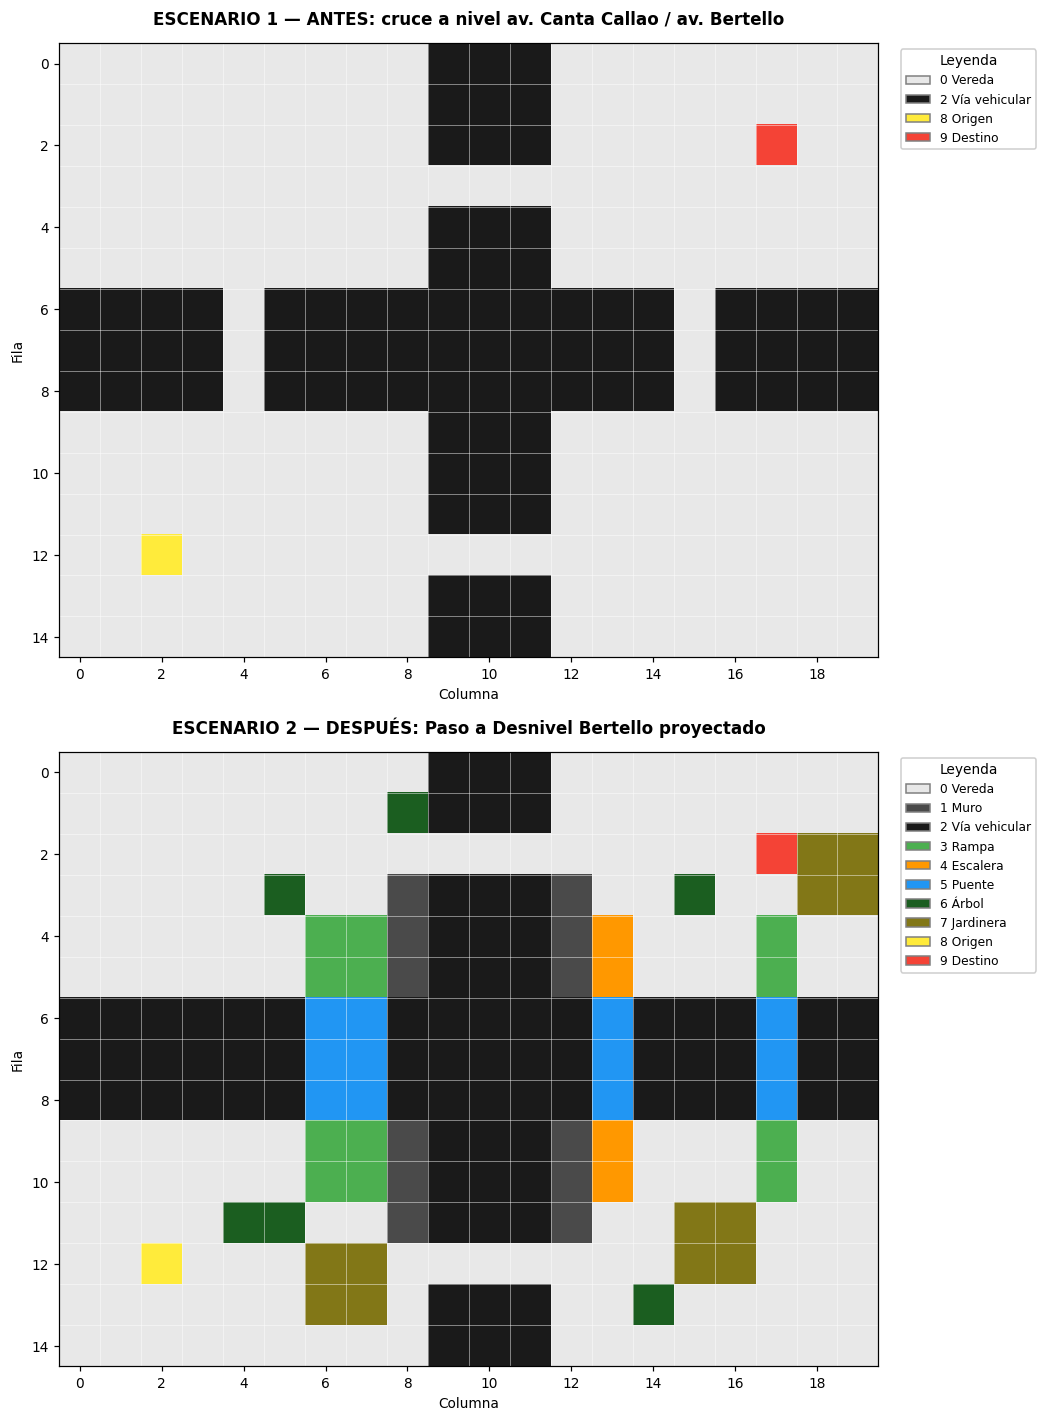


LECTURA DE LOS MAPAS
En ambos escenarios:
  - Av. Bertello es la franja HORIZONTAL de las filas 6-8.
  - Av. Canta Callao es la franja VERTICAL de las columnas 9-11.

En el escenario DESPUÉS:
  - Los tramos gris oscuro de las columnas 8 y 12 son los MUROS
    de contención de 2 m de altura.
  - Se dibujan verticales porque son PARALELOS a Canta Callao.
  - Las rampas y la escalera permiten atravesar la franja de Bertello.


In [7]:
# ============================================================================
# CELDA 16 — VISUALIZACIÓN COMPARATIVA DE LOS DOS ESCENARIOS
# ============================================================================

fig, axes = plt.subplots(2, 1, figsize=(12, 13))

dibujar_mapa(MAPA_ANTES,
             "ESCENARIO 1 — ANTES: cruce a nivel av. Canta Callao / av. Bertello",
             ax=axes[0])

dibujar_mapa(MAPA_DESPUES,
             "ESCENARIO 2 — DESPUÉS: Paso a Desnivel Bertello proyectado",
             ax=axes[1])

plt.tight_layout()
plt.show()

# --- Lectura de la figura para la exposición ---
# --- Lectura de la figura para la exposición ---
print("\nLECTURA DE LOS MAPAS")
print("=" * 78)
print("En ambos escenarios:")
print("  - Av. Bertello es la franja HORIZONTAL de las filas 6-8.")
print("  - Av. Canta Callao es la franja VERTICAL de las columnas 9-11.")
print()
print("En el escenario DESPUÉS:")
print("  - Los tramos gris oscuro de las columnas 8 y 12 son los MUROS")
print("    de contención de 2 m de altura.")
print("  - Se dibujan verticales porque son PARALELOS a Canta Callao.")
print("  - Las rampas y la escalera permiten atravesar la franja de Bertello.")
print("=" * 78)


## 9. Implementación del MDP: la clase `EntornoBertello`

La clase implementa la tupla $\langle \mathcal{S}, \mathcal{A}, P, R, \gamma \rangle$ mediante la interfaz estándar de RL:

| Método | Rol en el MDP | Descripción |
|---|---|---|
| `reset(perfil)` | Distribución inicial $\mu_0$ | Coloca al agente en el origen. Devuelve $s_0$. |
| `step(accion)` | $P(s'\|s,a)$ y $R(s,a,s')$ | Ejecuta $a_t$, devuelve $(s_{t+1},\ r_{t+1},\ \text{terminado},\ \text{info})$. |
| `estado_a_indice(s)` | Codificación | Convierte $(f, c, \text{perfil})$ en un índice entero para la tabla Q. |

### Estructura interna del método `step` (inicio, proceso y fin)

**INICIO — Recepción de la acción**
1. Se verifica que el episodio no haya terminado.
2. Se incrementa el contador de pasos.

**PROCESO — Resolución de la transición y la recompensa**
3. Se aplica la dinámica de transición (determinista o estocástica) para obtener la acción **efectivamente ejecutada**.
4. Se calcula la celda candidata $(f', c')$.
5. Se evalúa la **legalidad** de la celda candidata en este orden:
   - ¿Está fuera de la grilla? → penaliza como muro, **no avanza**.
   - ¿Es muro / vía / árbol / jardinera? → penaliza, **no avanza**.
   - ¿Es escalera y el perfil es `1`? → penaliza fuerte, **no avanza**.
   - En cualquier otro caso → **avanza**.
6. Se registra el evento en `info` (para la contabilidad de métricas).

**FIN — Comprobación de terminación**
7. Si la nueva celda es el destino → recompensa `+100`, `terminado = True`.
8. Si se agotó `MAX_PASOS` → recompensa `R_TIMEOUT`, `terminado = True`.
9. Se retorna la tupla $(s', r, \text{terminado}, \text{info})$.

### Codificación estado → índice

$$\text{idx}(f, c, p) = p \cdot (15 \times 20) + f \cdot 20 + c$$

Esta biyección permite usar una tabla Q como matriz NumPy de forma `(600, 4)`, con acceso $O(1)$.

In [9]:
# ============================================================================
# CELDA 18 — CLASE DEL ENTORNO (implementación del MDP)
# ============================================================================

class EntornoBertello:
    """
    Entorno Gridworld que modela el desplazamiento peatonal en el
    Paso a Desnivel Bertello como un Proceso de Decisión de Markov.

    Implementa la tupla <S, A, P, R, gamma>:
      S : (fila, columna, perfil)         -> 15 * 20 * 2 = 600 estados
      A : {0:Arriba, 1:Abajo, 2:Izq, 3:Der}
      P : determinista o estocástica (80/10/10)
      R : sistema de recompensas de la celda 11
    """

    # ---------------------------------------------------------------- INIT --
    def __init__(self, mapa: np.ndarray, estocastico: bool = ESTOCASTICO,
                 rng: np.random.Generator = None, max_pasos: int = MAX_PASOS):
        """
        Parámetros
        ----------
        mapa : np.ndarray (15, 20)
            Matriz de códigos de terreno.
        estocastico : bool
            Si True, activa la dinámica 80/10/10.
        rng : np.random.Generator
            Generador de aleatoriedad (inyectado para reproducibilidad).
        max_pasos : int
            Presupuesto de pasos por episodio.
        """
        # Copia defensiva: el entorno NO debe mutar el mapa original,
        # porque el mismo mapa se reutiliza en varios entrenamientos.
        self.mapa = mapa.copy()
        self.estocastico = estocastico
        self.rng = rng if rng is not None else np.random.default_rng(SEMILLA)
        self.max_pasos = max_pasos

        self.n_filas, self.n_cols = mapa.shape

        # Localizamos origen y destino UNA sola vez (no en cada reset).
        self.pos_origen = tuple(np.argwhere(self.mapa == ORIGEN)[0])
        self.pos_destino = tuple(np.argwhere(self.mapa == DESTINO)[0])

        # Atributos de estado (se inicializan en reset)
        self.fila = None
        self.col = None
        self.perfil = None
        self.pasos = 0
        self.terminado = True

    # ------------------------------------------------- CODIFICACIÓN ESTADO --
    def estado_a_indice(self, fila: int, col: int, perfil: int) -> int:
        """
        Convierte el estado (fila, columna, perfil) en un índice entero
        único en el rango [0, 599].

        Fórmula:  idx = perfil * (n_filas * n_cols) + fila * n_cols + col

        Es una biyección: cada estado tiene exactamente un índice y viceversa.
        Permite representar la tabla Q como una matriz NumPy (600, 4)
        en lugar de un diccionario, lo que hace el acceso O(1) y la
        actualización vectorizable.
        """
        return perfil * (self.n_filas * self.n_cols) + fila * self.n_cols + col

    def indice_a_estado(self, idx: int) -> tuple:
        """Inversa de estado_a_indice. Útil para inspeccionar la tabla Q."""
        perfil = idx // (self.n_filas * self.n_cols)
        resto = idx % (self.n_filas * self.n_cols)
        fila = resto // self.n_cols
        col = resto % self.n_cols
        return (fila, col, perfil)

    @property
    def n_estados(self) -> int:
        """Cardinalidad del espacio de estados |S|."""
        return self.n_filas * self.n_cols * 2

    # ------------------------------------------------------------- RESET ----
    def reset(self, perfil: int = PERFIL_SIN_RESTRICCIONES) -> tuple:
        """
        Reinicia el entorno al inicio de un nuevo episodio.
        Implementa la distribución inicial mu_0 del MDP (aquí, determinista:
        el agente SIEMPRE parte del origen).

        Parámetros
        ----------
        perfil : int
            0 = sin restricciones, 1 = movilidad reducida.
            El perfil se fija al inicio y NO cambia durante el episodio.

        Retorna
        -------
        tuple (fila, col, perfil) -> el estado inicial s_0
        """
        self.fila, self.col = self.pos_origen
        self.perfil = perfil
        self.pasos = 0
        self.terminado = False
        return (self.fila, self.col, self.perfil)

    # ------------------------------------------ DINÁMICA DE TRANSICIÓN P ----
    def _resolver_accion_efectiva(self, accion: int) -> int:
        """
        Aplica la dinámica de transición P(s'|s,a) para determinar qué acción
        se EJECUTA REALMENTE.

        Modo determinista : la acción ejecutada == la acción solicitada.
        Modo estocástico  : 80% acción solicitada
                            10% no moverse (se codifica con -1)
                            10% acción perpendicular aleatoria

        Retorna
        -------
        int : la acción efectiva, o -1 si el agente no se mueve.
        """
        if not self.estocastico:
            return accion

        u = self.rng.random()   # muestra uniforme en [0, 1)

        if u < P_ACCION_CORRECTA:
            # Caso 80%: todo sale como se planeó.
            return accion
        elif u < P_ACCION_CORRECTA + P_NO_MOVERSE:
            # Caso 10%: CONGESTIÓN PEATONAL. El agente queda bloqueado
            # por otros peatones y no logra avanzar este paso.
            return -1
        else:
            # Caso 10%: EMPUJE LATERAL. El agente se desvía 90 grados.
            # Se elige entre las dos perpendiculares con prob. 1/2 cada una.
            # NUNCA se invierte la marcha 180 grados: físicamente, un empujón
            # lateral desvía, no hace retroceder.
            return int(self.rng.choice(PERPENDICULARES[accion]))

    # ------------------------------------------------------------- STEP -----
    def step(self, accion: int) -> tuple:
        """
        Ejecuta un paso del MDP.

        Parámetros
        ----------
        accion : int en {0, 1, 2, 3}

        Retorna
        -------
        (estado_siguiente, recompensa, terminado, info)
            estado_siguiente : tuple (fila, col, perfil)
            recompensa       : float
            terminado        : bool
            info             : dict con el tipo de evento (para métricas)
        """
        # ================== INICIO: validaciones ============================
        if self.terminado:
            raise RuntimeError("El episodio ya terminó. Llame a reset() antes.")
        if accion not in (ARRIBA, ABAJO, IZQUIERDA, DERECHA):
            raise ValueError(f"Acción inválida: {accion}. Debe ser 0, 1, 2 o 3.")

        self.pasos += 1
        info = {"evento": None, "accion_invalida": False, "terreno_pisado": None}

        # ================== PROCESO: resolver la transición =================
        # (1) ¿Qué acción se ejecuta realmente? (determinista o estocástica)
        accion_efectiva = self._resolver_accion_efectiva(accion)

        if accion_efectiva == -1:
            # CONGESTIÓN: el agente no se mueve, pero SÍ consume un paso
            # y SÍ paga el costo de paso. El tiempo transcurre igual.
            recompensa = R_PASO
            info["evento"] = "congestion"
            nueva_fila, nueva_col = self.fila, self.col
        else:
            # (2) Celda candidata según el vector de movimiento
            df, dc = MOVIMIENTOS[accion_efectiva]
            nueva_fila = self.fila + df
            nueva_col = self.col + dc

            # (3) EVALUACIÓN DE LEGALIDAD (orden de prioridad estricto)

            # --- (3a) ¿Fuera de los límites de la grilla? ---
            fuera = not (0 <= nueva_fila < self.n_filas and
                         0 <= nueva_col < self.n_cols)
            if fuera:
                # Se trata como muro: es el límite del área de estudio.
                recompensa = R_MURO
                info["evento"] = "fuera_de_grilla"
                info["accion_invalida"] = True
                nueva_fila, nueva_col = self.fila, self.col   # NO avanza
            else:
                terreno = self.mapa[nueva_fila, nueva_col]
                info["terreno_pisado"] = int(terreno)

                # --- (3b) MURO: barrera de contención ---
                if terreno == MURO:
                    recompensa = R_MURO
                    info["evento"] = "choque_muro"
                    info["accion_invalida"] = True
                    nueva_fila, nueva_col = self.fila, self.col   # NO avanza

                # --- (3c) VÍA VEHICULAR: riesgo de atropello ---
                elif terreno == VIA:
                    recompensa = R_VIA
                    info["evento"] = "invasion_via"
                    info["accion_invalida"] = True
                    nueva_fila, nueva_col = self.fila, self.col   # NO avanza

                # --- (3d) ÁRBOL ---
                elif terreno == ARBOL:
                    recompensa = R_ARBOL
                    info["evento"] = "choque_arbol"
                    info["accion_invalida"] = True
                    nueva_fila, nueva_col = self.fila, self.col   # NO avanza

                # --- (3e) JARDINERA ---
                elif terreno == JARDINERA:
                    recompensa = R_JARDINERA
                    info["evento"] = "choque_jardinera"
                    info["accion_invalida"] = True
                    nueva_fila, nueva_col = self.fila, self.col   # NO avanza

                # --- (3f) *** REGLA CRÍTICA DE ACCESIBILIDAD *** ---
                # Si el perfil es MOVILIDAD REDUCIDA y la celda es ESCALERA,
                # el acceso es FÍSICAMENTE IMPOSIBLE. Se penaliza fuerte y
                # NO se avanza. Esta única condición es la que hace que el
                # agente aprenda DOS políticas distintas con UNA sola tabla Q.
                elif terreno == ESCALERA and self.perfil == PERFIL_MOVILIDAD_REDUCIDA:
                    recompensa = R_ESCALERA_PROHIBIDA
                    info["evento"] = "escalera_prohibida"
                    info["accion_invalida"] = True
                    nueva_fila, nueva_col = self.fila, self.col   # NO avanza

                # --- (3g) CELDA TRANSITABLE ---
                # Incluye: VEREDA, RAMPA, PUENTE, ORIGEN, DESTINO,
                # y ESCALERA cuando el perfil es 0.
                else:
                    recompensa = R_PASO
                    info["evento"] = "avance"
                    # El agente SÍ avanza: se actualiza la posición.
                    self.fila, self.col = nueva_fila, nueva_col

                    # Contabilidad de uso de infraestructura (para métricas)
                    if terreno == RAMPA:
                        info["evento"] = "avance_rampa"
                    elif terreno == ESCALERA:
                        info["evento"] = "avance_escalera"
                    elif terreno == PUENTE:
                        info["evento"] = "avance_puente"

        # ================== FIN: comprobación de terminación ================
        terminado = False

        # (4) ¿Llegó al destino?
        if self.mapa[self.fila, self.col] == DESTINO:
            recompensa = R_DESTINO      # sobrescribe R_PASO: +100
            info["evento"] = "destino"
            terminado = True

        # (5) ¿Se agotó el presupuesto de pasos?
        elif self.pasos >= self.max_pasos:
            recompensa += R_TIMEOUT     # SUMA la penalización al costo del paso
            info["evento"] = "timeout"
            terminado = True

        self.terminado = terminado
        estado_siguiente = (self.fila, self.col, self.perfil)

        return estado_siguiente, recompensa, terminado, info


print("[OK] Clase EntornoBertello definida.")

[OK] Clase EntornoBertello definida.


In [10]:
# ============================================================================
# CELDA 19 — PRUEBAS UNITARIAS DEL ENTORNO
# ============================================================================
# Antes de entrenar, VERIFICAMOS que el MDP se comporta como fue especificado.
# Si el entorno está mal, el agente aprenderá perfectamente... la política
# equivocada. Estas pruebas son la garantía de que los resultados posteriores
# son válidos, y responden al requisito "el código debe funcionar sin errores".
# ============================================================================

def ejecutar_pruebas_entorno():
    """Batería de pruebas del MDP. Cada prueba valida una regla del diseño."""
    env = EntornoBertello(MAPA_DESPUES, estocastico=False,
                          rng=np.random.default_rng(0))
    pruebas_ok = 0
    total = 0

    # ---- PRUEBA 1: reset devuelve el origen correcto ----
    total += 1
    s0 = env.reset(perfil=PERFIL_SIN_RESTRICCIONES)
    assert s0 == (12, 2, 0), f"Esperado (12,2,0), obtenido {s0}"
    print("[PASS] 1. reset() coloca al agente en el origen (12, 2) con perfil 0")
    pruebas_ok += 1

    # ---- PRUEBA 2: la codificación estado->índice es biyectiva ----
    total += 1
    indices = set()
    for p in (0, 1):
        for f in range(N_FILAS):
            for c in range(N_COLS):
                idx = env.estado_a_indice(f, c, p)
                assert env.indice_a_estado(idx) == (f, c, p), "Inversa incorrecta"
                indices.add(idx)
    assert len(indices) == 600, f"Esperados 600 índices únicos, hay {len(indices)}"
    assert min(indices) == 0 and max(indices) == 599, "Rango de índices incorrecto"
    print("[PASS] 2. estado_a_indice() es biyectiva sobre los 600 estados [0..599]")
    pruebas_ok += 1

    # ---- PRUEBA 3: movimiento normal sobre vereda ----
    total += 1
    env.reset(perfil=0)
    s, r, done, info = env.step(ARRIBA)   # desde (12,2) hacia (11,2) = vereda
    assert s == (11, 2, 0), f"Esperado (11,2,0), obtenido {s}"
    assert r == R_PASO, f"Esperado {R_PASO}, obtenido {r}"
    assert not done and not info["accion_invalida"]
    print(f"[PASS] 3. Movimiento normal: (12,2)->(11,2), recompensa {r}")
    pruebas_ok += 1

    # ---- PRUEBA 4: salir de la grilla penaliza y NO avanza ----
    total += 1
    env.reset(perfil=0)
    env.fila, env.col = 0, 0             # forzamos la esquina superior-izquierda
    s, r, done, info = env.step(ARRIBA)  # intento de salir por arriba
    assert s == (0, 0, 0), "El agente NO debe salir de la grilla"
    assert r == R_MURO, f"Esperado {R_MURO}, obtenido {r}"
    assert info["evento"] == "fuera_de_grilla"
    print(f"[PASS] 4. Salir de la grilla: bloqueado, recompensa {r}")
    pruebas_ok += 1

    # ---- PRUEBA 5: chocar con muro penaliza y NO avanza ----
    total += 1
    env.reset(perfil=0)
    # El muro está en la columna 8 y es paralelo a Canta Callao.
    env.fila, env.col = 10, 7
    assert env.mapa[10, 8] == MURO, "Precondición: (10,8) debe ser muro"
    s, r, done, info = env.step(DERECHA)
    assert s == (10, 7, 0), "El agente NO debe atravesar el muro"
    assert r == R_MURO and info["accion_invalida"]
    print(f"[PASS] 5. Choque con muro vertical: bloqueado en (10,7), recompensa {r}")
    pruebas_ok += 1

    # ---- PRUEBA 6: invadir vía vehicular es la penalización de riesgo ----
    total += 1
    env.reset(perfil=0)
    # En la fila 13, la celda (13,8) es vereda y (13,9) es Canta Callao.
    env.fila, env.col = 13, 8
    assert env.mapa[13, 9] == VIA, "Precondición: (13,9) debe ser vía"
    s, r, done, info = env.step(DERECHA)
    assert s == (13, 8, 0), "El agente NO debe invadir la vía"
    assert r == R_VIA, f"Esperado {R_VIA}, obtenido {r}"
    assert info["evento"] == "invasion_via"
    print(f"[PASS] 6. Invasión de Canta Callao: bloqueado, recompensa {r}")
    pruebas_ok += 1

    # ---- PRUEBA 7: *** REGLA CRÍTICA *** perfil 0 SÍ puede usar escalera ----
    total += 1
    env.reset(perfil=PERFIL_SIN_RESTRICCIONES)
    env.fila, env.col = 11, 13           # vereda debajo de la escalera (10,13)
    assert env.mapa[10, 13] == ESCALERA, "Precondición: (10,13) es escalera"
    s, r, done, info = env.step(ARRIBA)
    assert s == (10, 13, 0), "Perfil 0 SÍ debe poder subir la escalera"
    assert r == R_PASO, f"Esperado {R_PASO}, obtenido {r}"
    assert info["evento"] == "avance_escalera"
    print(f"[PASS] 7. Perfil 0 en escalera: AVANZA a (10,13), recompensa {r}")
    pruebas_ok += 1

    # ---- PRUEBA 8: *** REGLA CRÍTICA *** perfil 1 NO puede usar escalera ----
    total += 1
    env.reset(perfil=PERFIL_MOVILIDAD_REDUCIDA)
    env.fila, env.col = 11, 13           # MISMA celda, MISMA acción, distinto perfil
    s, r, done, info = env.step(ARRIBA)
    assert s == (11, 13, 1), "Perfil 1 NO debe poder subir la escalera"
    assert r == R_ESCALERA_PROHIBIDA, f"Esperado {R_ESCALERA_PROHIBIDA}, obtenido {r}"
    assert info["evento"] == "escalera_prohibida"
    print(f"[PASS] 8. Perfil 1 en escalera: BLOQUEADO en (11,13), recompensa {r}")
    print("         ^^^ Pruebas 7 y 8: MISMA celda, MISMA acción, MISMO mapa.")
    print("             La ÚNICA diferencia es el perfil. Esto demuestra que el")
    print("             perfil forma parte del ESTADO y modifica la dinámica.")
    pruebas_ok += 1

    # ---- PRUEBA 9: ambos perfiles SÍ pueden usar la rampa ----
    total += 1
    for p in (0, 1):
        env.reset(perfil=p)
        env.fila, env.col = 11, 6        # vereda debajo de la rampa (10,6)
        assert env.mapa[10, 6] == RAMPA, "Precondición: (10,6) es rampa"
        s, r, done, info = env.step(ARRIBA)
        assert s == (10, 6, p), f"Perfil {p} debe poder usar la rampa"
        assert r == R_PASO
        assert info["evento"] == "avance_rampa"
    print(f"[PASS] 9. Rampa: AMBOS perfiles avanzan a (10,6), recompensa {R_PASO}")
    pruebas_ok += 1

    # ---- PRUEBA 10: llegar al destino otorga +100 y termina el episodio ----
    total += 1
    env.reset(perfil=0)
    env.fila, env.col = 2, 16            # celda contigua al destino (2,17)
    s, r, done, info = env.step(DERECHA)
    assert s == (2, 17, 0) and done, "Debe terminar al llegar al destino"
    assert r == R_DESTINO, f"Esperado {R_DESTINO}, obtenido {r}"
    print(f"[PASS] 10. Destino alcanzado: recompensa {r}, episodio terminado")
    pruebas_ok += 1

    # ---- PRUEBA 11: el timeout termina el episodio con penalización ----
    total += 1
    env_corto = EntornoBertello(MAPA_DESPUES, estocastico=False,
                                rng=np.random.default_rng(0), max_pasos=3)
    env_corto.reset(perfil=0)
    for i in range(3):
        s, r, done, info = env_corto.step(ABAJO)   # acción que no llega al destino
    assert done, "El episodio debe terminar al agotar max_pasos"
    assert info["evento"] == "timeout"
    print(f"[PASS] 11. Timeout a los 3 pasos: recompensa {r}, episodio terminado")
    pruebas_ok += 1

    # ---- PRUEBA 12: llamar step() tras terminar lanza excepción ----
    total += 1
    try:
        env_corto.step(ABAJO)
        raise AssertionError("Debió lanzar RuntimeError")
    except RuntimeError:
        print("[PASS] 12. step() tras terminar lanza RuntimeError (protección)")
        pruebas_ok += 1

    # ---- PRUEBA 13: el modo estocástico respeta las proporciones 80/10/10 ----
    total += 1
    env_est = EntornoBertello(MAPA_DESPUES, estocastico=True,
                              rng=np.random.default_rng(123))
    conteo = {"solicitada": 0, "quieto": 0, "lateral": 0}
    N = 20000
    for _ in range(N):
        efectiva = env_est._resolver_accion_efectiva(ARRIBA)
        if efectiva == ARRIBA:
            conteo["solicitada"] += 1
        elif efectiva == -1:
            conteo["quieto"] += 1
        else:
            conteo["lateral"] += 1
            assert efectiva in PERPENDICULARES[ARRIBA], \
                "El deslizamiento debe ser PERPENDICULAR, nunca 180 grados"
    p_sol = conteo["solicitada"] / N
    p_qui = conteo["quieto"] / N
    p_lat = conteo["lateral"] / N
    assert abs(p_sol - 0.80) < 0.02, f"P(solicitada)={p_sol:.3f}, esperado ~0.80"
    assert abs(p_qui - 0.10) < 0.02, f"P(quieto)={p_qui:.3f}, esperado ~0.10"
    assert abs(p_lat - 0.10) < 0.02, f"P(lateral)={p_lat:.3f}, esperado ~0.10"
    print(f"[PASS] 13. Estocástico ({N} muestras): "
          f"solicitada={p_sol:.3f} | quieto={p_qui:.3f} | lateral={p_lat:.3f}")
    print("           (esperado: 0.80 / 0.10 / 0.10) — y NUNCA retrocede 180°")
    pruebas_ok += 1

    print("\n" + "=" * 78)
    print(f"RESULTADO: {pruebas_ok}/{total} pruebas superadas.")
    print("El MDP se comporta EXACTAMENTE según la especificación de las")
    print("secciones 5 y 6. Los resultados posteriores son válidos.")
    print("=" * 78)


ejecutar_pruebas_entorno()

[PASS] 1. reset() coloca al agente en el origen (12, 2) con perfil 0
[PASS] 2. estado_a_indice() es biyectiva sobre los 600 estados [0..599]
[PASS] 3. Movimiento normal: (12,2)->(11,2), recompensa -1
[PASS] 4. Salir de la grilla: bloqueado, recompensa -25
[PASS] 5. Choque con muro vertical: bloqueado en (10,7), recompensa -25
[PASS] 6. Invasión de Canta Callao: bloqueado, recompensa -40
[PASS] 7. Perfil 0 en escalera: AVANZA a (10,13), recompensa -1
[PASS] 8. Perfil 1 en escalera: BLOQUEADO en (11,13), recompensa -50
         ^^^ Pruebas 7 y 8: MISMA celda, MISMA acción, MISMO mapa.
             La ÚNICA diferencia es el perfil. Esto demuestra que el
             perfil forma parte del ESTADO y modifica la dinámica.
[PASS] 9. Rampa: AMBOS perfiles avanzan a (10,6), recompensa -1
[PASS] 10. Destino alcanzado: recompensa 100, episodio terminado
[PASS] 11. Timeout a los 3 pasos: recompensa -45, episodio terminado
[PASS] 12. step() tras terminar lanza RuntimeError (protección)
[PASS] 13. E

## 10. Política ε-greedy: el dilema exploración–explotación

### 10.1 El dilema

El agente enfrenta una tensión fundamental:

- **Explotar:** elegir la acción que *hasta ahora* parece mejor → obtiene buena recompensa, pero **nunca descubre** si existe algo mejor.
- **Explorar:** elegir una acción al azar → puede descubrir rutas mejores, pero **sacrifica** recompensa inmediata.

Un agente puramente codicioso (*greedy*) desde el inicio quedaría atrapado en la **primera** ruta que funcione, aunque sea pésima. Un agente puramente aleatorio nunca capitalizaría lo aprendido.

### 10.2 La política ε-greedy

$$
\pi(a \mid s) =
\begin{cases}
\text{acción aleatoria de } \mathcal{A} & \text{con probabilidad } \varepsilon \\[6pt]
\arg\max_{a'} Q(s, a') & \text{con probabilidad } 1 - \varepsilon
\end{cases}
$$

### 10.3 Decaimiento de ε

$$\varepsilon_{k+1} = \max(\varepsilon_{\min},\ \varepsilon_k \cdot \lambda)$$

con $\varepsilon_0 = 1.0$, $\lambda = 0.995$, $\varepsilon_{\min} = 0.05$.

**Interpretación:** al inicio el agente **no sabe nada**, así que explora al 100%. Conforme acumula experiencia, confía cada vez más en su tabla Q.

**¿Cuántos episodios hasta llegar al mínimo?**

$$1.0 \times 0.995^k = 0.05 \implies k = \frac{\ln(0.05)}{\ln(0.995)} \approx 598$$

Es decir, ε alcanza su piso alrededor del **episodio 598**, y los ~4400 episodios restantes se dedican a **refinar** la política con exploración residual del 5%.

### 10.4 ¿Por qué ε nunca llega a 0?

Porque en el modo **estocástico** el agente necesita seguir muestreando para estimar correctamente las esperanzas. Además, un ε residual del 5% es la condición práctica de **exploración infinita** (GLIE) que sustenta la garantía teórica de convergencia de Q-Learning:

> Q-Learning converge a $Q^*$ con probabilidad 1 si **todos** los pares $(s,a)$ se visitan infinitas veces y la tasa de aprendizaje satisface las condiciones de Robbins-Monro.

**Nota de honestidad técnica que conviene tener lista:** usamos $\alpha = 0.1$ **constante**, lo que **viola** la segunda condición de Robbins-Monro ($\sum \alpha_t^2 < \infty$). En la práctica, $\alpha$ constante es lo estándar porque converge a una *vecindad* de $Q^*$ y se adapta mejor a entornos no estacionarios. Es una desviación deliberada de la teoría, no un descuido.

### 10.5 Desempate aleatorio en el `argmax`

`np.argmax` devuelve **siempre el primer índice** máximo. Al inicio del entrenamiento **toda la tabla Q vale 0**, por lo que `np.argmax` devolvería siempre la acción `0` (Arriba), introduciendo un **sesgo sistemático** hacia el norte. La implementación desempata **aleatoriamente** entre las acciones de valor máximo.

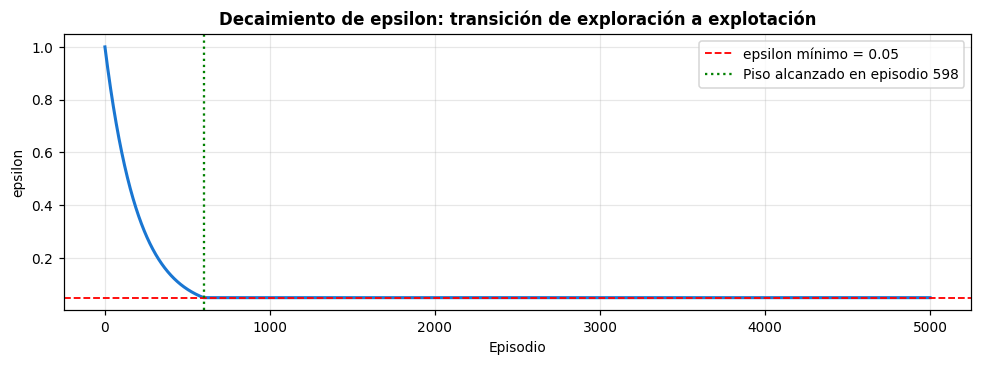

epsilon inicial            : 1.0
epsilon tras 100 episodios : 0.6058
epsilon tras 300 episodios : 0.2223
epsilon tras 600 episodios : 0.0500
Piso (0.05) alcanzado en el episodio: 598
Verificación teórica ln(0.05)/ln(0.995) = 597.6

Interpretación: los primeros ~598 episodios EXPLORAN el mapa.
Los 4402 restantes REFINAN la política con 5% de exploración residual.


In [11]:
# ============================================================================
# CELDA 21 — POLÍTICA EPSILON-GREEDY Y UTILIDADES DE SELECCIÓN
# ============================================================================

def argmax_aleatorio(valores: np.ndarray, rng: np.random.Generator) -> int:
    """
    argmax con desempate ALEATORIO entre valores máximos.

    ¿Por qué no usar np.argmax directamente?
    ----------------------------------------
    np.argmax devuelve SIEMPRE el primer índice máximo. Al inicio del
    entrenamiento la tabla Q está llena de ceros, así que np.argmax([0,0,0,0])
    devolvería siempre 0 = ARRIBA. Eso introduciría un SESGO SISTEMÁTICO:
    el agente probaría "Arriba" desproporcionadamente. El desempate aleatorio
    elimina ese sesgo y hace que la exploración inicial sea imparcial.
    """
    maximo = np.max(valores)
    # np.flatnonzero devuelve los ÍNDICES donde la condición es verdadera.
    candidatos = np.flatnonzero(valores == maximo)
    return int(rng.choice(candidatos))


def politica_epsilon_greedy(Q: np.ndarray, idx_estado: int, epsilon: float,
                            rng: np.random.Generator) -> int:
    """
    Selecciona una acción según la política epsilon-greedy.

        pi(a|s) = accion aleatoria           con probabilidad epsilon
                = argmax_a' Q(s, a')         con probabilidad 1 - epsilon

    Parámetros
    ----------
    Q : np.ndarray de forma (n_estados, n_acciones)
    idx_estado : int
        Índice del estado actual.
    epsilon : float en [0, 1]
        Probabilidad de explorar.
    rng : np.random.Generator

    Retorna
    -------
    int : acción elegida en {0, 1, 2, 3}
    """
    if rng.random() < epsilon:
        # ---------- EXPLORACIÓN ----------
        # Acción uniformemente aleatoria. Permite descubrir zonas del espacio
        # de estados que la política actual nunca visitaría.
        return int(rng.integers(0, N_ACCIONES))
    else:
        # ---------- EXPLOTACIÓN ----------
        # Acción codiciosa: la mejor según el conocimiento acumulado en Q.
        return argmax_aleatorio(Q[idx_estado], rng)


def decaer_epsilon(epsilon: float,
                   decay: float = EPSILON_DECAY,
                   minimo: float = EPSILON_MINIMO) -> float:
    """
    Aplica el decaimiento exponencial de epsilon:

        epsilon_{k+1} = max(epsilon_min, epsilon_k * decay)

    El max() garantiza que epsilon NUNCA baje del piso. Mantener un epsilon
    residual > 0 es lo que sustenta la condición GLIE de exploración infinita
    y permite seguir adaptándose en entornos estocásticos.
    """
    return max(minimo, epsilon * decay)


# ---------------------- DEMOSTRACIÓN DEL DECAIMIENTO ------------------------
eps = EPSILON_INICIAL
historial_eps = [eps]
for _ in range(EPISODIOS):
    eps = decaer_epsilon(eps)
    historial_eps.append(eps)

# Episodio en que epsilon toca el piso (cálculo empírico, no teórico)
ep_piso = next(i for i, e in enumerate(historial_eps) if e <= EPSILON_MINIMO + 1e-12)

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(historial_eps, linewidth=2, color="#1976D2")
ax.axhline(EPSILON_MINIMO, color="red", linestyle="--", linewidth=1.2,
           label=f"epsilon mínimo = {EPSILON_MINIMO}")
ax.axvline(ep_piso, color="green", linestyle=":", linewidth=1.5,
           label=f"Piso alcanzado en episodio {ep_piso}")
ax.set_xlabel("Episodio")
ax.set_ylabel("epsilon")
ax.set_title("Decaimiento de epsilon: transición de exploración a explotación",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"epsilon inicial            : {EPSILON_INICIAL}")
print(f"epsilon tras 100 episodios : {historial_eps[100]:.4f}")
print(f"epsilon tras 300 episodios : {historial_eps[300]:.4f}")
print(f"epsilon tras 600 episodios : {historial_eps[600]:.4f}")
print(f"Piso ({EPSILON_MINIMO}) alcanzado en el episodio: {ep_piso}")
print(f"Verificación teórica ln(0.05)/ln(0.995) = {np.log(0.05)/np.log(0.995):.1f}")
print(f"\nInterpretación: los primeros ~{ep_piso} episodios EXPLORAN el mapa.")
print(f"Los {EPISODIOS - ep_piso} restantes REFINAN la política con 5% de exploración residual.")

## 11. Los tres agentes

### 11.1 Agente aleatorio (línea base)

$$\pi_{\text{aleatoria}}(a \mid s) = \frac{1}{4} \quad \forall a \in \mathcal{A}$$

**No aprende nada.** Su función es **metodológica**: sin línea base, decir "Q-Learning alcanzó 98% de éxito" no significa nada. La línea base cuantifica **cuánto** del desempeño se debe al aprendizaje y no a la facilidad del problema.

### 11.2 Q-Learning (off-policy)

$$\boxed{Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left[ r_{t+1} + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t) \right]}$$

**Es off-policy** porque el objetivo usa $\max_{a'} Q(s_{t+1}, a')$: asume que en el siguiente estado se tomará la **mejor** acción, **independientemente de la acción que la política de comportamiento realmente vaya a tomar**.

- **Política de comportamiento** (la que genera los datos): ε-greedy.
- **Política objetivo** (la que se aprende): greedy pura.

**Son distintas** → *off-policy*.

Q-Learning aprende $Q^*$ directamente, aproximando la **ecuación de optimalidad de Bellman**:
$$Q^*(s,a) = \mathbb{E}\left[ r + \gamma \max_{a'} Q^*(s', a') \right]$$

### 11.3 SARSA (on-policy)

$$\boxed{Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left[ r_{t+1} + \gamma \, Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t) \right]}$$

El nombre **SARSA** proviene de la quíntupla que usa: $(S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1})$.

**Es on-policy** porque $a_{t+1}$ es la acción que la **misma política ε-greedy realmente eligió**, no la mejor posible. SARSA aprende el valor de **la política que está siguiendo**, incluidos sus errores exploratorios.

### 11.4 La diferencia en una sola línea

| | Q-Learning | SARSA |
|---|---|---|
| Objetivo TD | $r + \gamma \max_{a'} Q(s', a')$ | $r + \gamma Q(s', a')$ |
| Naturaleza | Off-policy | On-policy |
| Aprende | La política **óptima** $\pi^*$ | La política **ε-greedy actual** |
| Ante el riesgo | **Optimista**: ignora que explorará mal | **Realista**: contabiliza sus errores |
| Ruta esperada aquí | Bordeando muros y vías (óptima) | Con margen de seguridad |

**La diferencia es UNA sola palabra en el código:** `max` vs. la acción realmente elegida. **Esta es la pregunta más probable de la evaluación.**

### 11.5 Predicción teórica antes de ejecutar

Este proyecto reproduce, en contexto urbano, el fenómeno del ***Cliff Walking*** de Sutton & Barto (Ejemplo 6.6):

> Q-Learning aprende la ruta óptima que bordea el acantilado, pero como sigue explorando con ε > 0, **cae ocasionalmente** y obtiene **menor recompensa promedio durante el entrenamiento**. SARSA, al contabilizar la exploración en su objetivo, aprende una ruta **más alejada del acantilado**: subóptima en longitud, pero **más segura durante el aprendizaje**.

**Aquí el "acantilado" es la vía vehicular (`-40`).**

Se registra esta predicción **antes** de ejecutar. Si los datos la contradicen, se reportará el resultado real: los datos mandan, no la teoría.

In [12]:
# ============================================================================
# CELDA 23 — AGENTE ALEATORIO (LÍNEA BASE)
# ============================================================================

def entrenar_agente_aleatorio(mapa, episodios=EPISODIOS,
                              perfiles=(PERFIL_SIN_RESTRICCIONES,
                                        PERFIL_MOVILIDAD_REDUCIDA),
                              semilla=SEMILLA, estocastico=ESTOCASTICO):
    """
    Ejecuta un agente que elige acciones UNIFORMEMENTE AL AZAR.

    Este agente NO APRENDE: no tiene tabla Q, no actualiza nada.
    Su propósito es METODOLÓGICO: establece la LÍNEA BASE contra la cual
    medir si Q-Learning y SARSA realmente aprendieron algo.

    Sin línea base, afirmar "el agente alcanzó 98% de éxito" no dice nada:
    quizás el problema era trivial. La línea base permite ATRIBUIR la mejora
    al aprendizaje y no a la facilidad del entorno.

    Retorna
    -------
    dict con el historial de métricas por episodio.
    """
    rng = np.random.default_rng(semilla)
    env = EntornoBertello(mapa, estocastico=estocastico, rng=rng)

    historial = {
        "recompensa": [], "pasos": [], "exito": [], "perfil": [],
        "acciones_invalidas": [], "choques_muro": [], "invasiones_via": [],
        "escaleras_prohibidas": [], "uso_rampa": [], "uso_escalera": [],
        "epsilon": [],
    }

    for ep in range(episodios):
        # Alternamos perfiles: la mitad de los episodios con cada perfil.
        perfil = perfiles[ep % len(perfiles)]
        estado = env.reset(perfil=perfil)

        recompensa_total = 0.0
        contadores = defaultdict(int)
        terminado = False

        while not terminado:
            # ---- LA ÚNICA LÍNEA QUE DEFINE A ESTE AGENTE ----
            # Acción uniformemente aleatoria. Equivale a epsilon-greedy
            # con epsilon = 1.0 fijo para siempre, y sin tabla Q.
            accion = int(rng.integers(0, N_ACCIONES))

            estado, recompensa, terminado, info = env.step(accion)
            recompensa_total += recompensa

            # ---- Contabilidad de eventos para las métricas ----
            if info["accion_invalida"]:
                contadores["invalidas"] += 1
            ev = info["evento"]
            if ev == "choque_muro":
                contadores["muro"] += 1
            elif ev == "invasion_via":
                contadores["via"] += 1
            elif ev == "escalera_prohibida":
                contadores["escalera_prohibida"] += 1
            elif ev == "avance_rampa":
                contadores["rampa"] += 1
            elif ev == "avance_escalera":
                contadores["escalera"] += 1

        exito = 1 if info["evento"] == "destino" else 0

        historial["recompensa"].append(recompensa_total)
        historial["pasos"].append(env.pasos)
        historial["exito"].append(exito)
        historial["perfil"].append(perfil)
        historial["acciones_invalidas"].append(contadores["invalidas"])
        historial["choques_muro"].append(contadores["muro"])
        historial["invasiones_via"].append(contadores["via"])
        historial["escaleras_prohibidas"].append(contadores["escalera_prohibida"])
        historial["uso_rampa"].append(contadores["rampa"])
        historial["uso_escalera"].append(contadores["escalera"])
        historial["epsilon"].append(1.0)   # el aleatorio "explora" siempre

    return historial


print("Ejecutando agente ALEATORIO (línea base) sobre el Escenario 2...")
HIST_ALEATORIO = entrenar_agente_aleatorio(MAPA_DESPUES)

tasa_exito_aleatorio = np.mean(HIST_ALEATORIO["exito"]) * 100
print(f"[OK] {EPISODIOS} episodios ejecutados.")
print(f"     Tasa de éxito       : {tasa_exito_aleatorio:.2f}%")
print(f"     Recompensa promedio : {np.mean(HIST_ALEATORIO['recompensa']):.2f}")
print(f"     Pasos promedio      : {np.mean(HIST_ALEATORIO['pasos']):.2f}")
print(f"     Acciones inválidas promedio: {np.mean(HIST_ALEATORIO['acciones_invalidas']):.2f}")

Ejecutando agente ALEATORIO (línea base) sobre el Escenario 2...
[OK] 5000 episodios ejecutados.
     Tasa de éxito       : 0.30%
     Recompensa promedio : -1264.62
     Pasos promedio      : 199.87
     Acciones inválidas promedio: 41.72


In [13]:
# ============================================================================
# CELDA 24 — ALGORITMO Q-LEARNING (OFF-POLICY, TD CONTROL)
# ============================================================================

def entrenar_q_learning(mapa, episodios=EPISODIOS, alpha=ALPHA, gamma=GAMMA,
                        epsilon_inicial=EPSILON_INICIAL,
                        epsilon_minimo=EPSILON_MINIMO,
                        epsilon_decay=EPSILON_DECAY,
                        perfiles=(PERFIL_SIN_RESTRICCIONES,
                                  PERFIL_MOVILIDAD_REDUCIDA),
                        semilla=SEMILLA, estocastico=ESTOCASTICO,
                        verbose=True):
    """
    Q-LEARNING (Watkins, 1989) — Control TD OFF-POLICY.

    ECUACIÓN DE ACTUALIZACIÓN:
    ==========================================================================
        Q(s,a) <- Q(s,a) + alpha * [ r + gamma * max_a' Q(s',a') - Q(s,a) ]
                           \_________________________________________/
                                        error TD (delta)
    ==========================================================================

    DESGLOSE DE CADA TÉRMINO:
      Q(s,a)              : estimación ACTUAL del valor del par (estado, acción)
      alpha               : tasa de aprendizaje. Cuánto peso damos a la nueva
                            información frente a lo ya sabido.
      r                   : recompensa INMEDIATA recibida
      gamma               : factor de descuento. Cuánto valen las recompensas
                            futuras respecto a las inmediatas.
      max_a' Q(s',a')     : *** EL CORAZÓN DEL OFF-POLICY ***
                            Valor de la MEJOR acción posible en s',
                            SIN IMPORTAR qué acción vaya a tomar realmente
                            la política de comportamiento (epsilon-greedy).
      [ ... ]             : ERROR TD. Diferencia entre lo que ESPERÁBAMOS
                            (Q(s,a)) y lo que la experiencia nos DICE
                            (r + gamma*max Q(s',a')).

    ¿POR QUÉ ES OFF-POLICY?
      - Política de COMPORTAMIENTO (genera los datos) : epsilon-greedy
      - Política OBJETIVO (la que se aprende)         : greedy pura (el max)
      Son DISTINTAS -> off-policy.
      Q-Learning aprende Q* directamente, aunque se comporte sub-óptimamente
      mientras explora. Aproxima la ecuación de OPTIMALIDAD de Bellman.

    Retorna
    -------
    (Q, historial) : tabla Q entrenada y diccionario de métricas.
    """
    rng = np.random.default_rng(semilla)
    env = EntornoBertello(mapa, estocastico=estocastico, rng=rng)

    # -------------------- INICIALIZACIÓN DE LA TABLA Q ---------------------
    # Forma (600, 4): 600 estados x 4 acciones.
    # Inicializada en CEROS. Nota: en un entorno con recompensas mayormente
    # negativas, Q=0 es una inicialización OPTIMISTA (el valor real de casi
    # todo par (s,a) es negativo). Esto FAVORECE la exploración: cualquier
    # acción no probada parece mejor que las ya probadas. Es un efecto
    # deseable y complementa a epsilon-greedy.
    Q = np.zeros((env.n_estados, N_ACCIONES), dtype=float)

    epsilon = epsilon_inicial
    historial = {
        "recompensa": [], "pasos": [], "exito": [], "perfil": [],
        "acciones_invalidas": [], "choques_muro": [], "invasiones_via": [],
        "escaleras_prohibidas": [], "uso_rampa": [], "uso_escalera": [],
        "epsilon": [], "td_error_medio": [],
    }

    # ========================= BUCLE DE EPISODIOS ==========================
    for ep in range(episodios):
        perfil = perfiles[ep % len(perfiles)]

        # ---- INICIO del episodio ----
        estado = env.reset(perfil=perfil)
        idx_s = env.estado_a_indice(*estado)

        recompensa_total = 0.0
        contadores = defaultdict(int)
        errores_td = []
        terminado = False

        # ---- PROCESO: bucle de pasos ----
        while not terminado:
            # (1) Elegir acción a desde s usando la política DE COMPORTAMIENTO
            accion = politica_epsilon_greedy(Q, idx_s, epsilon, rng)

            # (2) Ejecutar a, observar r y s'
            estado_sig, recompensa, terminado, info = env.step(accion)
            idx_s_sig = env.estado_a_indice(*estado_sig)

            # (3) ============ ACTUALIZACIÓN Q-LEARNING ============
            #
            #     Q(s,a) <- Q(s,a) + alpha*[ r + gamma*max_a' Q(s',a') - Q(s,a)]
            #
            if terminado and info["evento"] == "destino":
                # Estado TERMINAL: por definición del MDP, no hay recompensas
                # futuras desde un estado terminal. Su valor es 0.
                # Usar max Q(s_terminal, ·) sería un ERROR CONCEPTUAL clásico:
                # inyectaría valor fantasma en un estado del que no se sale.
                objetivo_td = recompensa
            else:
                # *** LA LÍNEA QUE DEFINE OFF-POLICY ***
                # np.max(Q[idx_s_sig]) = valor de la MEJOR acción en s',
                # sin importar cuál se tomará realmente después.
                objetivo_td = recompensa + gamma * np.max(Q[idx_s_sig])

            # Error TD (delta): la "sorpresa" del agente.
            error_td = objetivo_td - Q[idx_s, accion]

            # Actualización incremental: nos movemos alpha en la dirección
            # del error. Con alpha=0.1, corregimos el 10% de la discrepancia.
            Q[idx_s, accion] += alpha * error_td

            errores_td.append(abs(error_td))

            # (4) Avanzar: s <- s'
            idx_s = idx_s_sig
            recompensa_total += recompensa

            # ---- Contabilidad de métricas ----
            if info["accion_invalida"]:
                contadores["invalidas"] += 1
            ev = info["evento"]
            if ev == "choque_muro":
                contadores["muro"] += 1
            elif ev == "invasion_via":
                contadores["via"] += 1
            elif ev == "escalera_prohibida":
                contadores["escalera_prohibida"] += 1
            elif ev == "avance_rampa":
                contadores["rampa"] += 1
            elif ev == "avance_escalera":
                contadores["escalera"] += 1

        # ---- FIN del episodio: registro y decaimiento de epsilon ----
        exito = 1 if info["evento"] == "destino" else 0

        historial["recompensa"].append(recompensa_total)
        historial["pasos"].append(env.pasos)
        historial["exito"].append(exito)
        historial["perfil"].append(perfil)
        historial["acciones_invalidas"].append(contadores["invalidas"])
        historial["choques_muro"].append(contadores["muro"])
        historial["invasiones_via"].append(contadores["via"])
        historial["escaleras_prohibidas"].append(contadores["escalera_prohibida"])
        historial["uso_rampa"].append(contadores["rampa"])
        historial["uso_escalera"].append(contadores["escalera"])
        historial["epsilon"].append(epsilon)
        historial["td_error_medio"].append(float(np.mean(errores_td)))

        # Decaimiento de epsilon: exploración -> explotación
        epsilon = decaer_epsilon(epsilon, epsilon_decay, epsilon_minimo)

        if verbose and (ep + 1) % 1000 == 0:
            ult = slice(max(0, ep - 199), ep + 1)
            print(f"  Episodio {ep+1:5d}/{episodios} | "
                  f"eps={epsilon:.3f} | "
                  f"R_prom(200 últ)={np.mean(historial['recompensa'][ult]):7.2f} | "
                  f"Éxito(200 últ)={np.mean(historial['exito'][ult])*100:5.1f}%")

    return Q, historial


print("Entrenando Q-LEARNING sobre el Escenario 2...")
print("-" * 78)
Q_QL, HIST_QL = entrenar_q_learning(MAPA_DESPUES)
print("-" * 78)
print("[OK] Q-Learning entrenado.")
print(f"     Tabla Q: forma {Q_QL.shape}")
print(f"     Valores Q distintos de cero: {np.count_nonzero(Q_QL)} / {Q_QL.size}")

<>:19: SyntaxWarning: invalid escape sequence '\_'
<>:19: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_554/4629319.py:19: SyntaxWarning: invalid escape sequence '\_'
  \_________________________________________/


Entrenando Q-LEARNING sobre el Escenario 2...
------------------------------------------------------------------------------
  Episodio  1000/5000 | eps=0.050 | R_prom(200 últ)=  49.64 | Éxito(200 últ)=100.0%
  Episodio  2000/5000 | eps=0.050 | R_prom(200 últ)=  67.18 | Éxito(200 últ)=100.0%
  Episodio  3000/5000 | eps=0.050 | R_prom(200 últ)=  66.37 | Éxito(200 últ)=100.0%
  Episodio  4000/5000 | eps=0.050 | R_prom(200 últ)=  66.41 | Éxito(200 últ)=100.0%
  Episodio  5000/5000 | eps=0.050 | R_prom(200 últ)=  64.99 | Éxito(200 últ)=100.0%
------------------------------------------------------------------------------
[OK] Q-Learning entrenado.
     Tabla Q: forma (600, 4)
     Valores Q distintos de cero: 1482 / 2400


In [14]:
# ============================================================================
# CELDA 25 — ALGORITMO SARSA (ON-POLICY, TD CONTROL)
# ============================================================================

def entrenar_sarsa(mapa, episodios=EPISODIOS, alpha=ALPHA, gamma=GAMMA,
                   epsilon_inicial=EPSILON_INICIAL,
                   epsilon_minimo=EPSILON_MINIMO,
                   epsilon_decay=EPSILON_DECAY,
                   perfiles=(PERFIL_SIN_RESTRICCIONES,
                             PERFIL_MOVILIDAD_REDUCIDA),
                   semilla=SEMILLA, estocastico=ESTOCASTICO,
                   verbose=True):
    """
    SARSA (Rummery & Niranjan, 1994) — Control TD ON-POLICY.

    ECUACIÓN DE ACTUALIZACIÓN:
    ==========================================================================
        Q(s,a) <- Q(s,a) + alpha * [ r + gamma * Q(s',a') - Q(s,a) ]
                                              \______/
                                        a' = acción REALMENTE elegida
                                             por epsilon-greedy en s'
    ==========================================================================

    EL NOMBRE "SARSA" viene de la quíntupla que usa la actualización:
        S_t , A_t , R_{t+1} , S_{t+1} , A_{t+1}
        \_/   \_/   \_____/   \_____/   \_____/
         S     A       R         S         A

    *** DIFERENCIA CON Q-LEARNING: UNA SOLA PALABRA ***
        Q-Learning : objetivo = r + gamma * max_a' Q(s', a')   <- el MÁXIMO
        SARSA      : objetivo = r + gamma *       Q(s', a')    <- el ELEGIDO

    ¿POR QUÉ ES ON-POLICY?
      Porque a' es la acción que la MISMA política epsilon-greedy realmente
      va a ejecutar en el siguiente paso, INCLUYENDO la posibilidad de que
      sea una acción exploratoria mala. SARSA aprende el valor de la política
      que está SIGUIENDO, no de la política óptima.

    CONSECUENCIA PRÁCTICA (fenómeno del "Cliff Walking", Sutton & Barto 6.6):
      SARSA "sabe" que a veces explorará y cometerá errores. Por eso, cerca
      de una zona peligrosa (aquí: la VÍA VEHICULAR con r=-40), el valor
      Q(s',a') PROMEDIA acciones buenas y malas, arrastrando hacia abajo el
      valor de los estados adyacentes al peligro. Resultado: SARSA aprende
      una ruta MÁS ALEJADA del peligro, subóptima en longitud pero más
      SEGURA durante el aprendizaje.
      Q-Learning, con el max, IGNORA que explorará: es OPTIMISTA y bordea
      el peligro por la ruta más corta.

    ESTRUCTURA DEL BUCLE (diferencia mecánica importante):
      Q-Learning: elegir a -> ejecutar -> actualizar
      SARSA     : elegir a ANTES del bucle -> ejecutar -> elegir a' ->
                  actualizar con a' -> a <- a'
      SARSA necesita conocer a' ANTES de actualizar. Por eso la acción
      se elige "un paso por adelantado".

    Retorna
    -------
    (Q, historial)
    """
    rng = np.random.default_rng(semilla)
    env = EntornoBertello(mapa, estocastico=estocastico, rng=rng)

    Q = np.zeros((env.n_estados, N_ACCIONES), dtype=float)
    epsilon = epsilon_inicial

    historial = {
        "recompensa": [], "pasos": [], "exito": [], "perfil": [],
        "acciones_invalidas": [], "choques_muro": [], "invasiones_via": [],
        "escaleras_prohibidas": [], "uso_rampa": [], "uso_escalera": [],
        "epsilon": [], "td_error_medio": [],
    }

    # ========================= BUCLE DE EPISODIOS ==========================
    for ep in range(episodios):
        perfil = perfiles[ep % len(perfiles)]

        # ---- INICIO del episodio ----
        estado = env.reset(perfil=perfil)
        idx_s = env.estado_a_indice(*estado)

        # *** DIFERENCIA ESTRUCTURAL CON Q-LEARNING ***
        # SARSA elige la PRIMERA acción ANTES de entrar al bucle, porque
        # la actualización necesita conocer la acción SIGUIENTE (a').
        accion = politica_epsilon_greedy(Q, idx_s, epsilon, rng)

        recompensa_total = 0.0
        contadores = defaultdict(int)
        errores_td = []
        terminado = False

        # ---- PROCESO: bucle de pasos ----
        while not terminado:
            # (1) Ejecutar la acción a (ya elegida), observar r y s'
            estado_sig, recompensa, terminado, info = env.step(accion)
            idx_s_sig = env.estado_a_indice(*estado_sig)

            # (2) Elegir a' desde s' con la MISMA política epsilon-greedy.
            #     ESTA es la acción que SE EJECUTARÁ realmente (no la mejor).
            if not terminado:
                accion_sig = politica_epsilon_greedy(Q, idx_s_sig, epsilon, rng)
            else:
                accion_sig = None   # no habrá siguiente acción

            # (3) ============== ACTUALIZACIÓN SARSA ==============
            #
            #     Q(s,a) <- Q(s,a) + alpha*[ r + gamma*Q(s',a') - Q(s,a) ]
            #
            if terminado and info["evento"] == "destino":
                # Estado terminal: valor futuro = 0
                objetivo_td = recompensa
            else:
                # *** LA LÍNEA QUE DEFINE ON-POLICY ***
                # Q[idx_s_sig, accion_sig] : el valor de la acción que la
                # política REALMENTE tomará, no el máximo. Si epsilon-greedy
                # eligió explorar hacia la vía vehicular, ese valor MALO
                # entra en el objetivo y se propaga hacia atrás.
                if accion_sig is None:
                    # Caso timeout: el episodio se trunca, pero el estado NO
                    # es terminal en el sentido del MDP. Sin embargo, no hay
                    # a' porque el episodio acabó. Usamos bootstrapping con
                    # el valor greedy del estado (aproximación estándar).
                    objetivo_td = recompensa + gamma * np.max(Q[idx_s_sig])
                else:
                    objetivo_td = recompensa + gamma * Q[idx_s_sig, accion_sig]

            error_td = objetivo_td - Q[idx_s, accion]
            Q[idx_s, accion] += alpha * error_td
            errores_td.append(abs(error_td))

            # (4) Avanzar: s <- s' Y ADEMÁS a <- a'
            #     Esta doble asignación es la firma estructural de SARSA.
            idx_s = idx_s_sig
            accion = accion_sig if accion_sig is not None else 0

            recompensa_total += recompensa

            # ---- Contabilidad de métricas ----
            if info["accion_invalida"]:
                contadores["invalidas"] += 1
            ev = info["evento"]
            if ev == "choque_muro":
                contadores["muro"] += 1
            elif ev == "invasion_via":
                contadores["via"] += 1
            elif ev == "escalera_prohibida":
                contadores["escalera_prohibida"] += 1
            elif ev == "avance_rampa":
                contadores["rampa"] += 1
            elif ev == "avance_escalera":
                contadores["escalera"] += 1

        # ---- FIN del episodio ----
        exito = 1 if info["evento"] == "destino" else 0

        historial["recompensa"].append(recompensa_total)
        historial["pasos"].append(env.pasos)
        historial["exito"].append(exito)
        historial["perfil"].append(perfil)
        historial["acciones_invalidas"].append(contadores["invalidas"])
        historial["choques_muro"].append(contadores["muro"])
        historial["invasiones_via"].append(contadores["via"])
        historial["escaleras_prohibidas"].append(contadores["escalera_prohibida"])
        historial["uso_rampa"].append(contadores["rampa"])
        historial["uso_escalera"].append(contadores["escalera"])
        historial["epsilon"].append(epsilon)
        historial["td_error_medio"].append(float(np.mean(errores_td)))

        epsilon = decaer_epsilon(epsilon, epsilon_decay, epsilon_minimo)

        if verbose and (ep + 1) % 1000 == 0:
            ult = slice(max(0, ep - 199), ep + 1)
            print(f"  Episodio {ep+1:5d}/{episodios} | "
                  f"eps={epsilon:.3f} | "
                  f"R_prom(200 últ)={np.mean(historial['recompensa'][ult]):7.2f} | "
                  f"Éxito(200 últ)={np.mean(historial['exito'][ult])*100:5.1f}%")

    return Q, historial


print("Entrenando SARSA sobre el Escenario 2...")
print("-" * 78)
Q_SARSA, HIST_SARSA = entrenar_sarsa(MAPA_DESPUES)
print("-" * 78)
print("[OK] SARSA entrenado.")
print(f"     Tabla Q: forma {Q_SARSA.shape}")
print(f"     Valores Q distintos de cero: {np.count_nonzero(Q_SARSA)} / {Q_SARSA.size}")

<>:19: SyntaxWarning: invalid escape sequence '\_'
<>:19: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_554/4238012249.py:19: SyntaxWarning: invalid escape sequence '\_'
  \______/


Entrenando SARSA sobre el Escenario 2...
------------------------------------------------------------------------------
  Episodio  1000/5000 | eps=0.050 | R_prom(200 últ)=  69.03 | Éxito(200 últ)=100.0%
  Episodio  2000/5000 | eps=0.050 | R_prom(200 últ)=  66.31 | Éxito(200 últ)=100.0%
  Episodio  3000/5000 | eps=0.050 | R_prom(200 últ)=  66.69 | Éxito(200 últ)=100.0%
  Episodio  4000/5000 | eps=0.050 | R_prom(200 últ)=  64.22 | Éxito(200 últ)=100.0%
  Episodio  5000/5000 | eps=0.050 | R_prom(200 últ)=  68.97 | Éxito(200 últ)=100.0%
------------------------------------------------------------------------------
[OK] SARSA entrenado.
     Tabla Q: forma (600, 4)
     Valores Q distintos de cero: 1483 / 2400


In [15]:
# ============================================================================
# CELDA 26 — EVALUACIÓN GREEDY Y EXTRACCIÓN DE RUTAS
# ============================================================================
# IMPORTANTE — DISTINCIÓN CONCEPTUAL CLAVE:
#
#   ENTRENAMIENTO : el agente usa epsilon-greedy (explora, comete errores)
#   EVALUACIÓN    : el agente usa GREEDY PURA (epsilon = 0, sin exploración)
#
# Las métricas de entrenamiento miden el APRENDIZAJE (con sus errores).
# Las métricas de evaluación miden la POLÍTICA FINAL APRENDIDA.
# Confundirlas es un error metodológico grave: reportar solo la recompensa
# de entrenamiento penalizaría injustamente a Q-Learning (que explora hacia
# la vía). Reportamos AMBAS.
# ============================================================================

def extraer_ruta_greedy(Q, mapa, perfil, max_pasos=MAX_PASOS,
                        estocastico=False, semilla=SEMILLA):
    """
    Ejecuta UN episodio siguiendo la política GREEDY PURA (epsilon = 0)
    y devuelve la ruta completa junto con sus métricas.

    Detección de ciclos
    -------------------
    Si la política es defectuosa, el agente puede quedar atrapado en un
    ciclo (A->B->A->B...). Detectamos la repetición de un par (estado, acción)
    y abortamos, en lugar de dejar correr hasta max_pasos. Esto hace la
    evaluación honesta: un ciclo se reporta como FALLO, no se disfraza.

    Retorna
    -------
    dict con: ruta, exito, pasos, recompensa, eventos y métricas de uso.
    """
    rng = np.random.default_rng(semilla)
    env = EntornoBertello(mapa, estocastico=estocastico, rng=rng,
                          max_pasos=max_pasos)
    estado = env.reset(perfil=perfil)

    ruta = [(estado[0], estado[1])]
    recompensa_total = 0.0
    contadores = defaultdict(int)
    visitados = set()          # para detectar ciclos
    ciclo_detectado = False
    terminado = False

    while not terminado:
        idx_s = env.estado_a_indice(*estado)

        # ---- POLÍTICA GREEDY PURA: SIN exploración ----
        accion = argmax_aleatorio(Q[idx_s], rng)

        # ---- Detección de ciclo: par (estado, acción) ya visto ----
        clave = (idx_s, accion)
        if clave in visitados:
            ciclo_detectado = True
            break
        visitados.add(clave)

        estado, recompensa, terminado, info = env.step(accion)
        recompensa_total += recompensa
        ruta.append((estado[0], estado[1]))

        ev = info["evento"]
        if info["accion_invalida"]:
            contadores["invalidas"] += 1
        if ev == "avance_rampa":
            contadores["rampa"] += 1
        elif ev == "avance_escalera":
            contadores["escalera"] += 1
        elif ev == "avance_puente":
            contadores["puente"] += 1
        elif ev == "invasion_via":
            contadores["via"] += 1
        elif ev == "choque_muro":
            contadores["muro"] += 1
        elif ev == "escalera_prohibida":
            contadores["escalera_prohibida"] += 1

    exito = (not ciclo_detectado) and terminado and info["evento"] == "destino"

    return {
        "ruta": ruta,
        "exito": bool(exito),
        "pasos": env.pasos,
        "recompensa": recompensa_total,
        "ciclo": ciclo_detectado,
        "acciones_invalidas": contadores["invalidas"],
        "uso_rampa": contadores["rampa"],
        "uso_escalera": contadores["escalera"],
        "uso_puente": contadores["puente"],
        "invasiones_via": contadores["via"],
        "choques_muro": contadores["muro"],
        "escaleras_prohibidas": contadores["escalera_prohibida"],
        "longitud_ruta": len(ruta) - 1,
    }


def evaluar_politica(Q, mapa, perfil, n_episodios=200, estocastico=False,
                     semilla_base=1000):
    """
    Evalúa la política greedy en n_episodios independientes.

    En modo DETERMINISTA basta 1 episodio (el resultado es idéntico), pero
    evaluamos varios de todos modos por uniformidad metodológica.
    En modo ESTOCÁSTICO son IMPRESCINDIBLES: el resultado varía por episodio
    y necesitamos la ESPERANZA, no una muestra.
    """
    exitos, pasos_lista, recompensas, invalidas = [], [], [], []

    for i in range(n_episodios):
        res = extraer_ruta_greedy(Q, mapa, perfil, estocastico=estocastico,
                                  semilla=semilla_base + i)
        exitos.append(1 if res["exito"] else 0)
        recompensas.append(res["recompensa"])
        invalidas.append(res["acciones_invalidas"])
        if res["exito"]:
            pasos_lista.append(res["pasos"])

    return {
        "tasa_exito": float(np.mean(exitos)) * 100,
        "recompensa_media": float(np.mean(recompensas)),
        "pasos_medios": float(np.mean(pasos_lista)) if pasos_lista else float("nan"),
        "invalidas_medias": float(np.mean(invalidas)),
    }


print("[OK] Funciones de evaluación definidas.")

# ---------------------- EXTRACCIÓN DE LAS 4 RUTAS PRINCIPALES ---------------
RUTAS = {}
for nombre_alg, Q_tabla in [("Q-Learning", Q_QL), ("SARSA", Q_SARSA)]:
    for perfil in (PERFIL_SIN_RESTRICCIONES, PERFIL_MOVILIDAD_REDUCIDA):
        RUTAS[(nombre_alg, perfil)] = extraer_ruta_greedy(
            Q_tabla, MAPA_DESPUES, perfil, estocastico=False)

print("\nRUTAS EXTRAÍDAS CON POLÍTICA GREEDY (epsilon = 0):")
print("=" * 78)
for (alg, perfil), res in RUTAS.items():
    estado_txt = "ÉXITO" if res["exito"] else ("CICLO" if res["ciclo"] else "FALLO")
    print(f"{alg:11s} | {NOMBRES_PERFIL[perfil]:26s} | {estado_txt:6s} | "
          f"pasos={res['pasos']:3d} | R={res['recompensa']:7.1f} | "
          f"rampa={res['uso_rampa']:2d} | escalera={res['uso_escalera']:2d}")
print("=" * 78)

[OK] Funciones de evaluación definidas.

RUTAS EXTRAÍDAS CON POLÍTICA GREEDY (epsilon = 0):
Q-Learning  | Peatón sin restricciones   | ÉXITO  | pasos= 27 | R=   74.0 | rampa= 4 | escalera= 0
Q-Learning  | Movilidad reducida         | ÉXITO  | pasos= 25 | R=   76.0 | rampa= 3 | escalera= 0
SARSA       | Peatón sin restricciones   | ÉXITO  | pasos= 25 | R=   76.0 | rampa= 4 | escalera= 0
SARSA       | Movilidad reducida         | ÉXITO  | pasos= 25 | R=   76.0 | rampa= 3 | escalera= 0


In [17]:
# ============================================================================
# CELDA 27 — VERIFICACIÓN CRÍTICA DE ACCESIBILIDAD
# ============================================================================
# Esta celda verifica el REQUISITO FUNCIONAL más importante del proyecto:
#
#   La ruta aprendida para el perfil de MOVILIDAD REDUCIDA NO debe contener
#   NI UNA SOLA celda de escalera.
#
# Si esta verificación falla, el proyecto NO cumple su objetivo, por muy
# buenas que sean las métricas de recompensa.
# ============================================================================

def verificar_accesibilidad(ruta_dict, mapa, perfil):
    """
    Audita una ruta contra las reglas de accesibilidad de su perfil.

    Retorna
    -------
    (cumple, reporte) : bool y dict con el detalle del recorrido.
    """
    ruta = ruta_dict["ruta"]
    terrenos = [int(mapa[f, c]) for (f, c) in ruta]

    conteo = {ETIQUETAS[k]: terrenos.count(k) for k in sorted(set(terrenos))}
    n_escaleras = terrenos.count(ESCALERA)
    n_vias = terrenos.count(VIA)
    n_muros = terrenos.count(MURO)

    cumple = True
    violaciones = []

    # --- Regla 1: perfil 1 NUNCA puede pisar una escalera ---
    if perfil == PERFIL_MOVILIDAD_REDUCIDA and n_escaleras > 0:
        cumple = False
        violaciones.append(f"Pisó {n_escaleras} celda(s) de ESCALERA (prohibido)")

    # --- Regla 2: NINGÚN perfil puede pisar una vía vehicular ---
    if n_vias > 0:
        cumple = False
        violaciones.append(f"Pisó {n_vias} celda(s) de VÍA VEHICULAR")

    # --- Regla 3: NINGÚN perfil puede atravesar un muro ---
    if n_muros > 0:
        cumple = False
        violaciones.append(f"Atravesó {n_muros} celda(s) de MURO")

    return cumple, {
        "composicion": conteo,
        "violaciones": violaciones,
        "n_escaleras": n_escaleras,
        "n_vias": n_vias,
        "n_muros": n_muros,
    }


print("AUDITORÍA DE ACCESIBILIDAD DE LAS RUTAS APRENDIDAS")
print("=" * 78)

todas_cumplen = True
for (alg, perfil), res in RUTAS.items():
    cumple, rep = verificar_accesibilidad(res, MAPA_DESPUES, perfil)
    todas_cumplen = todas_cumplen and cumple

    marca = "CUMPLE" if cumple else "*** VIOLACIÓN ***"
    print(f"\n{alg} | {NOMBRES_PERFIL[perfil]} -> {marca}")
    print(f"  Longitud de ruta: {res['longitud_ruta']} celdas")
    print(f"  Composición del recorrido:")
    for terreno, n in rep["composicion"].items():
        print(f"     {terreno:20s}: {n:3d} celdas")
    if rep["violaciones"]:
        for v in rep["violaciones"]:
            print(f"  !!! {v}")

print("\n" + "=" * 78)
if todas_cumplen:
    print("RESULTADO: TODAS las rutas respetan las reglas de accesibilidad.")
    print("           Ninguna ruta de MOVILIDAD REDUCIDA usa escaleras.")
    print("           Ninguna ruta invade vías vehiculares ni atraviesa muros.")
    print("           El requisito funcional principal del proyecto SE CUMPLE.")
else:
    print("RESULTADO: SE DETECTARON VIOLACIONES. Revisar el diseño de recompensas.")
print("=" * 78)

AUDITORÍA DE ACCESIBILIDAD DE LAS RUTAS APRENDIDAS

Q-Learning | Peatón sin restricciones -> CUMPLE
  Longitud de ruta: 27 celdas
  Composición del recorrido:
     0 Vereda            :  19 celdas
     3 Rampa             :   4 celdas
     5 Puente            :   3 celdas
     8 Origen            :   1 celdas
     9 Destino           :   1 celdas

Q-Learning | Movilidad reducida -> CUMPLE
  Longitud de ruta: 25 celdas
  Composición del recorrido:
     0 Vereda            :  18 celdas
     3 Rampa             :   3 celdas
     5 Puente            :   3 celdas
     8 Origen            :   1 celdas
     9 Destino           :   1 celdas

SARSA | Peatón sin restricciones -> CUMPLE
  Longitud de ruta: 25 celdas
  Composición del recorrido:
     0 Vereda            :  17 celdas
     3 Rampa             :   4 celdas
     5 Puente            :   3 celdas
     8 Origen            :   1 celdas
     9 Destino           :   1 celdas

SARSA | Movilidad reducida -> CUMPLE
  Longitud de ruta: 25 celda

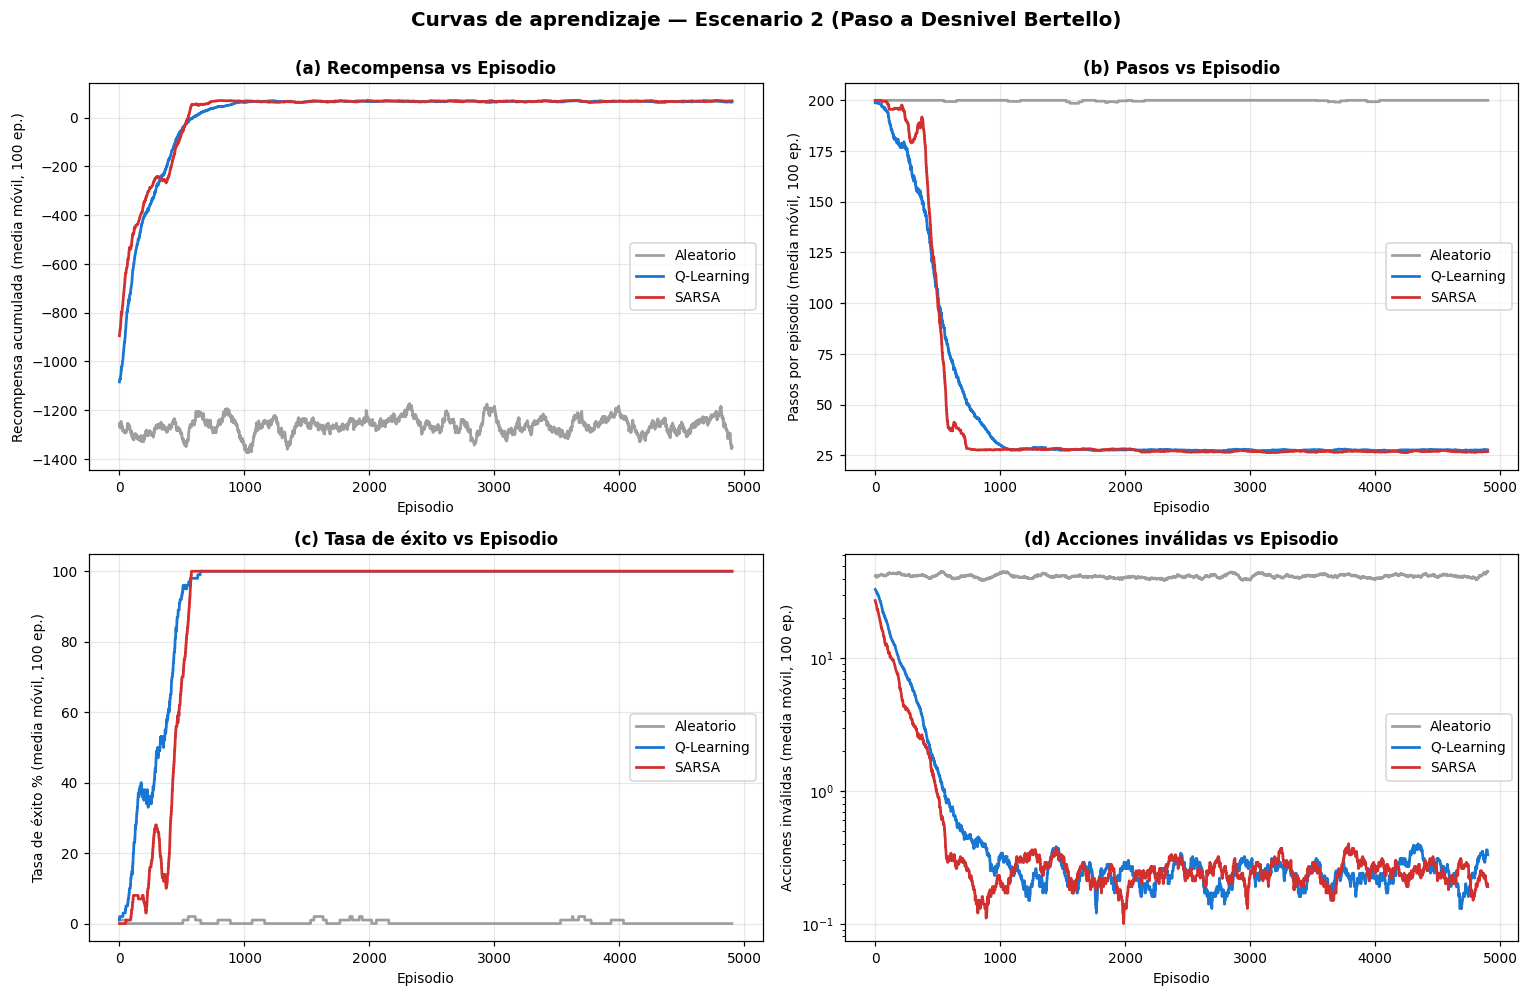

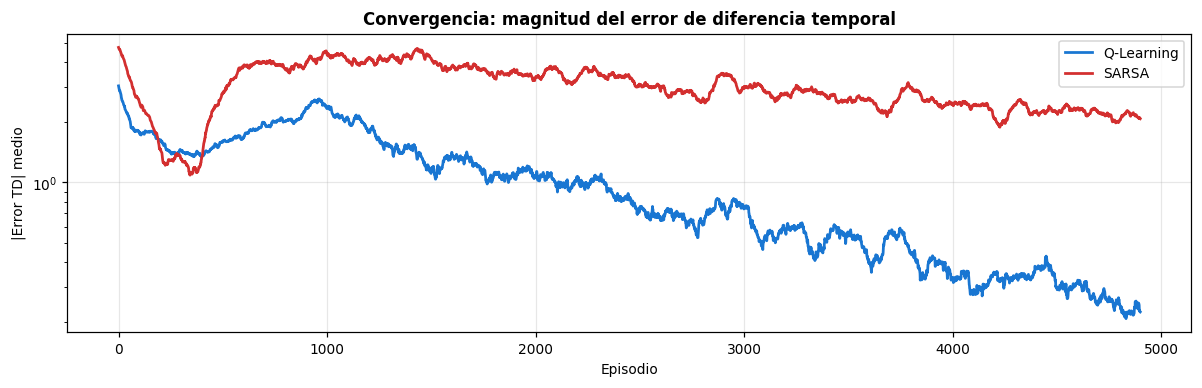

INTERPRETACIÓN DEL ERROR TD:
El error TD |delta| = |objetivo - Q(s,a)| mide la 'sorpresa' del agente.
Si tiende a cero, las predicciones de Q coinciden con la experiencia:
esa es la EVIDENCIA EMPÍRICA DE CONVERGENCIA. Si se estanca alto,
el agente sigue sorprendiéndose y NO ha convergido.


In [18]:
# ============================================================================
# CELDA 28 — GRÁFICOS DE CURVAS DE APRENDIZAJE
# ============================================================================

def media_movil(datos, ventana=100):
    """
    Media móvil simple. Suaviza el ruido de las curvas de aprendizaje.

    ¿Por qué es NECESARIA?
    ----------------------
    La recompensa por episodio es MUY ruidosa: dos episodios consecutivos
    con la misma política pueden diferir en decenas de puntos solo por la
    aleatoriedad de epsilon-greedy. Graficar los datos crudos produce una
    mancha ilegible. La media móvil revela la TENDENCIA del aprendizaje.
    IMPORTANTE: suavizamos la VISUALIZACIÓN, no los datos. Todas las métricas
    numéricas reportadas se calculan sobre los datos CRUDOS.
    """
    datos = np.asarray(datos, dtype=float)
    if len(datos) < ventana:
        return datos
    return np.convolve(datos, np.ones(ventana) / ventana, mode="valid")


VENTANA = 100
COLOR_ALG = {"Aleatorio": "#9E9E9E", "Q-Learning": "#1976D2", "SARSA": "#D32F2F"}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ---------------- (a) RECOMPENSA vs EPISODIO -------------------------------
ax = axes[0, 0]
for nombre, hist in [("Aleatorio", HIST_ALEATORIO), ("Q-Learning", HIST_QL),
                     ("SARSA", HIST_SARSA)]:
    suave = media_movil(hist["recompensa"], VENTANA)
    ax.plot(range(len(suave)), suave, label=nombre, color=COLOR_ALG[nombre],
            linewidth=1.8)
ax.set_xlabel("Episodio")
ax.set_ylabel(f"Recompensa acumulada (media móvil, {VENTANA} ep.)")
ax.set_title("(a) Recompensa vs Episodio", fontweight="bold")
ax.legend()

# ---------------- (b) PASOS vs EPISODIO ------------------------------------
ax = axes[0, 1]
for nombre, hist in [("Aleatorio", HIST_ALEATORIO), ("Q-Learning", HIST_QL),
                     ("SARSA", HIST_SARSA)]:
    suave = media_movil(hist["pasos"], VENTANA)
    ax.plot(range(len(suave)), suave, label=nombre, color=COLOR_ALG[nombre],
            linewidth=1.8)
ax.set_xlabel("Episodio")
ax.set_ylabel(f"Pasos por episodio (media móvil, {VENTANA} ep.)")
ax.set_title("(b) Pasos vs Episodio", fontweight="bold")
ax.legend()

# ---------------- (c) TASA DE ÉXITO vs EPISODIO ----------------------------
ax = axes[1, 0]
for nombre, hist in [("Aleatorio", HIST_ALEATORIO), ("Q-Learning", HIST_QL),
                     ("SARSA", HIST_SARSA)]:
    suave = media_movil(hist["exito"], VENTANA) * 100
    ax.plot(range(len(suave)), suave, label=nombre, color=COLOR_ALG[nombre],
            linewidth=1.8)
ax.set_xlabel("Episodio")
ax.set_ylabel(f"Tasa de éxito % (media móvil, {VENTANA} ep.)")
ax.set_title("(c) Tasa de éxito vs Episodio", fontweight="bold")
ax.set_ylim(-5, 105)
ax.legend()

# ---------------- (d) ACCIONES INVÁLIDAS vs EPISODIO -----------------------
ax = axes[1, 1]
for nombre, hist in [("Aleatorio", HIST_ALEATORIO), ("Q-Learning", HIST_QL),
                     ("SARSA", HIST_SARSA)]:
    suave = media_movil(hist["acciones_invalidas"], VENTANA)
    ax.plot(range(len(suave)), suave, label=nombre, color=COLOR_ALG[nombre],
            linewidth=1.8)
ax.set_xlabel("Episodio")
ax.set_ylabel(f"Acciones inválidas (media móvil, {VENTANA} ep.)")
ax.set_title("(d) Acciones inválidas vs Episodio", fontweight="bold")
ax.set_yscale("log")   # escala log: el aleatorio está órdenes de magnitud arriba
ax.legend()

plt.suptitle("Curvas de aprendizaje — Escenario 2 (Paso a Desnivel Bertello)",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

# ---------------- GRÁFICO ADICIONAL: ERROR TD ------------------------------
fig, ax = plt.subplots(figsize=(11, 3.6))
for nombre, hist in [("Q-Learning", HIST_QL), ("SARSA", HIST_SARSA)]:
    suave = media_movil(hist["td_error_medio"], VENTANA)
    ax.plot(range(len(suave)), suave, label=nombre, color=COLOR_ALG[nombre],
            linewidth=1.8)
ax.set_xlabel("Episodio")
ax.set_ylabel("|Error TD| medio")
ax.set_title("Convergencia: magnitud del error de diferencia temporal",
             fontweight="bold")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

print("INTERPRETACIÓN DEL ERROR TD:")
print("El error TD |delta| = |objetivo - Q(s,a)| mide la 'sorpresa' del agente.")
print("Si tiende a cero, las predicciones de Q coinciden con la experiencia:")
print("esa es la EVIDENCIA EMPÍRICA DE CONVERGENCIA. Si se estanca alto,")
print("el agente sigue sorprendiéndose y NO ha convergido.")

In [19]:
# ============================================================================
# CELDA 29 — TABLA DE RESULTADOS COMPARATIVOS
# ============================================================================

def resumir_historial(nombre, hist, ultimos=500):
    """
    Resume un historial de entrenamiento.

    Se reportan DOS ventanas, y la distinción importa:
      - GLOBAL       : promedio sobre TODOS los episodios. Incluye la fase
                       inicial de exploración caótica. Mide el COSTO TOTAL
                       DEL APRENDIZAJE.
      - ÚLTIMOS N    : promedio sobre los últimos N episodios, cuando epsilon
                       ya está en su piso. Mide la POLÍTICA CONVERGIDA.
    """
    u = slice(-ultimos, None)
    return {
        "Algoritmo": nombre,
        "R_global": np.mean(hist["recompensa"]),
        f"R_últ{ultimos}": np.mean(hist["recompensa"][u]),
        "Pasos_global": np.mean(hist["pasos"]),
        f"Pasos_últ{ultimos}": np.mean(hist["pasos"][u]),
        "Éxito_global_%": np.mean(hist["exito"]) * 100,
        f"Éxito_últ{ultimos}_%": np.mean(hist["exito"][u]) * 100,
        "Inválidas_global": np.mean(hist["acciones_invalidas"]),
        f"Inválidas_últ{ultimos}": np.mean(hist["acciones_invalidas"][u]),
        "Invasiones_vía_total": np.sum(hist["invasiones_via"]),
        "Escalera_prohib_total": np.sum(hist["escaleras_prohibidas"]),
    }


filas = [
    resumir_historial("Aleatorio", HIST_ALEATORIO),
    resumir_historial("Q-Learning", HIST_QL),
    resumir_historial("SARSA", HIST_SARSA),
]
TABLA_ENTRENAMIENTO = pd.DataFrame(filas).set_index("Algoritmo").round(2)

print("=" * 100)
print("TABLA 1 — MÉTRICAS DE ENTRENAMIENTO (política epsilon-greedy)")
print("=" * 100)
print(TABLA_ENTRENAMIENTO.to_string())
print()

# ---------------- TABLA 2: EVALUACIÓN GREEDY (política final) --------------
filas_eval = []
for nombre_alg, Q_tabla in [("Q-Learning", Q_QL), ("SARSA", Q_SARSA)]:
    for perfil in (PERFIL_SIN_RESTRICCIONES, PERFIL_MOVILIDAD_REDUCIDA):
        res = RUTAS[(nombre_alg, perfil)]
        filas_eval.append({
            "Algoritmo": nombre_alg,
            "Perfil": NOMBRES_PERFIL[perfil],
            "Éxito": "SÍ" if res["exito"] else "NO",
            "Pasos": res["pasos"],
            "Recompensa": round(res["recompensa"], 1),
            "Long_ruta": res["longitud_ruta"],
            "Uso_rampa": res["uso_rampa"],
            "Uso_escalera": res["uso_escalera"],
            "Uso_puente": res["uso_puente"],
            "Acc_inválidas": res["acciones_invalidas"],
        })

TABLA_EVALUACION = pd.DataFrame(filas_eval)

print("=" * 100)
print("TABLA 2 — EVALUACIÓN DE LA POLÍTICA FINAL (greedy pura, epsilon = 0)")
print("=" * 100)
print(TABLA_EVALUACION.to_string(index=False))
print()

# ---------------- TABLA 3: MEJORA SOBRE LA LÍNEA BASE ----------------------
r_base = np.mean(HIST_ALEATORIO["recompensa"])
e_base = np.mean(HIST_ALEATORIO["exito"]) * 100
i_base = np.mean(HIST_ALEATORIO["acciones_invalidas"])

print("=" * 100)
print("TABLA 3 — MEJORA RESPECTO A LA LÍNEA BASE (agente aleatorio)")
print("=" * 100)
print(f"{'Algoritmo':<14} {'ΔRecompensa':>14} {'ΔÉxito (p.p.)':>16} {'Reducción inválidas':>22}")
print("-" * 100)
for nombre, hist in [("Q-Learning", HIST_QL), ("SARSA", HIST_SARSA)]:
    u = slice(-500, None)
    r = np.mean(hist["recompensa"][u])
    e = np.mean(hist["exito"][u]) * 100
    i = np.mean(hist["acciones_invalidas"][u])
    red = (1 - i / i_base) * 100 if i_base > 0 else 0.0
    print(f"{nombre:<14} {r - r_base:>+14.2f} {e - e_base:>+16.2f} {red:>21.2f}%")
print("=" * 100)

TABLA 1 — MÉTRICAS DE ENTRENAMIENTO (política epsilon-greedy)
            R_global  R_últ500  Pasos_global  Pasos_últ500  Éxito_global_%  Éxito_últ500_%  Inválidas_global  Inválidas_últ500  Invasiones_vía_total  Escalera_prohib_total
Algoritmo                                                                                                                                                                  
Aleatorio   -1264.62  -1265.44        199.87        200.00            0.30             0.0             41.72             42.02                 52822                    190
Q-Learning      2.42     65.79         46.07         27.66           93.08           100.0              1.64              0.25                  2866                     51
SARSA          12.54     67.81         45.34         26.85           90.54           100.0              1.24              0.21                  1854                     14

TABLA 2 — EVALUACIÓN DE LA POLÍTICA FINAL (greedy pura, epsilon = 0)
 Algorit

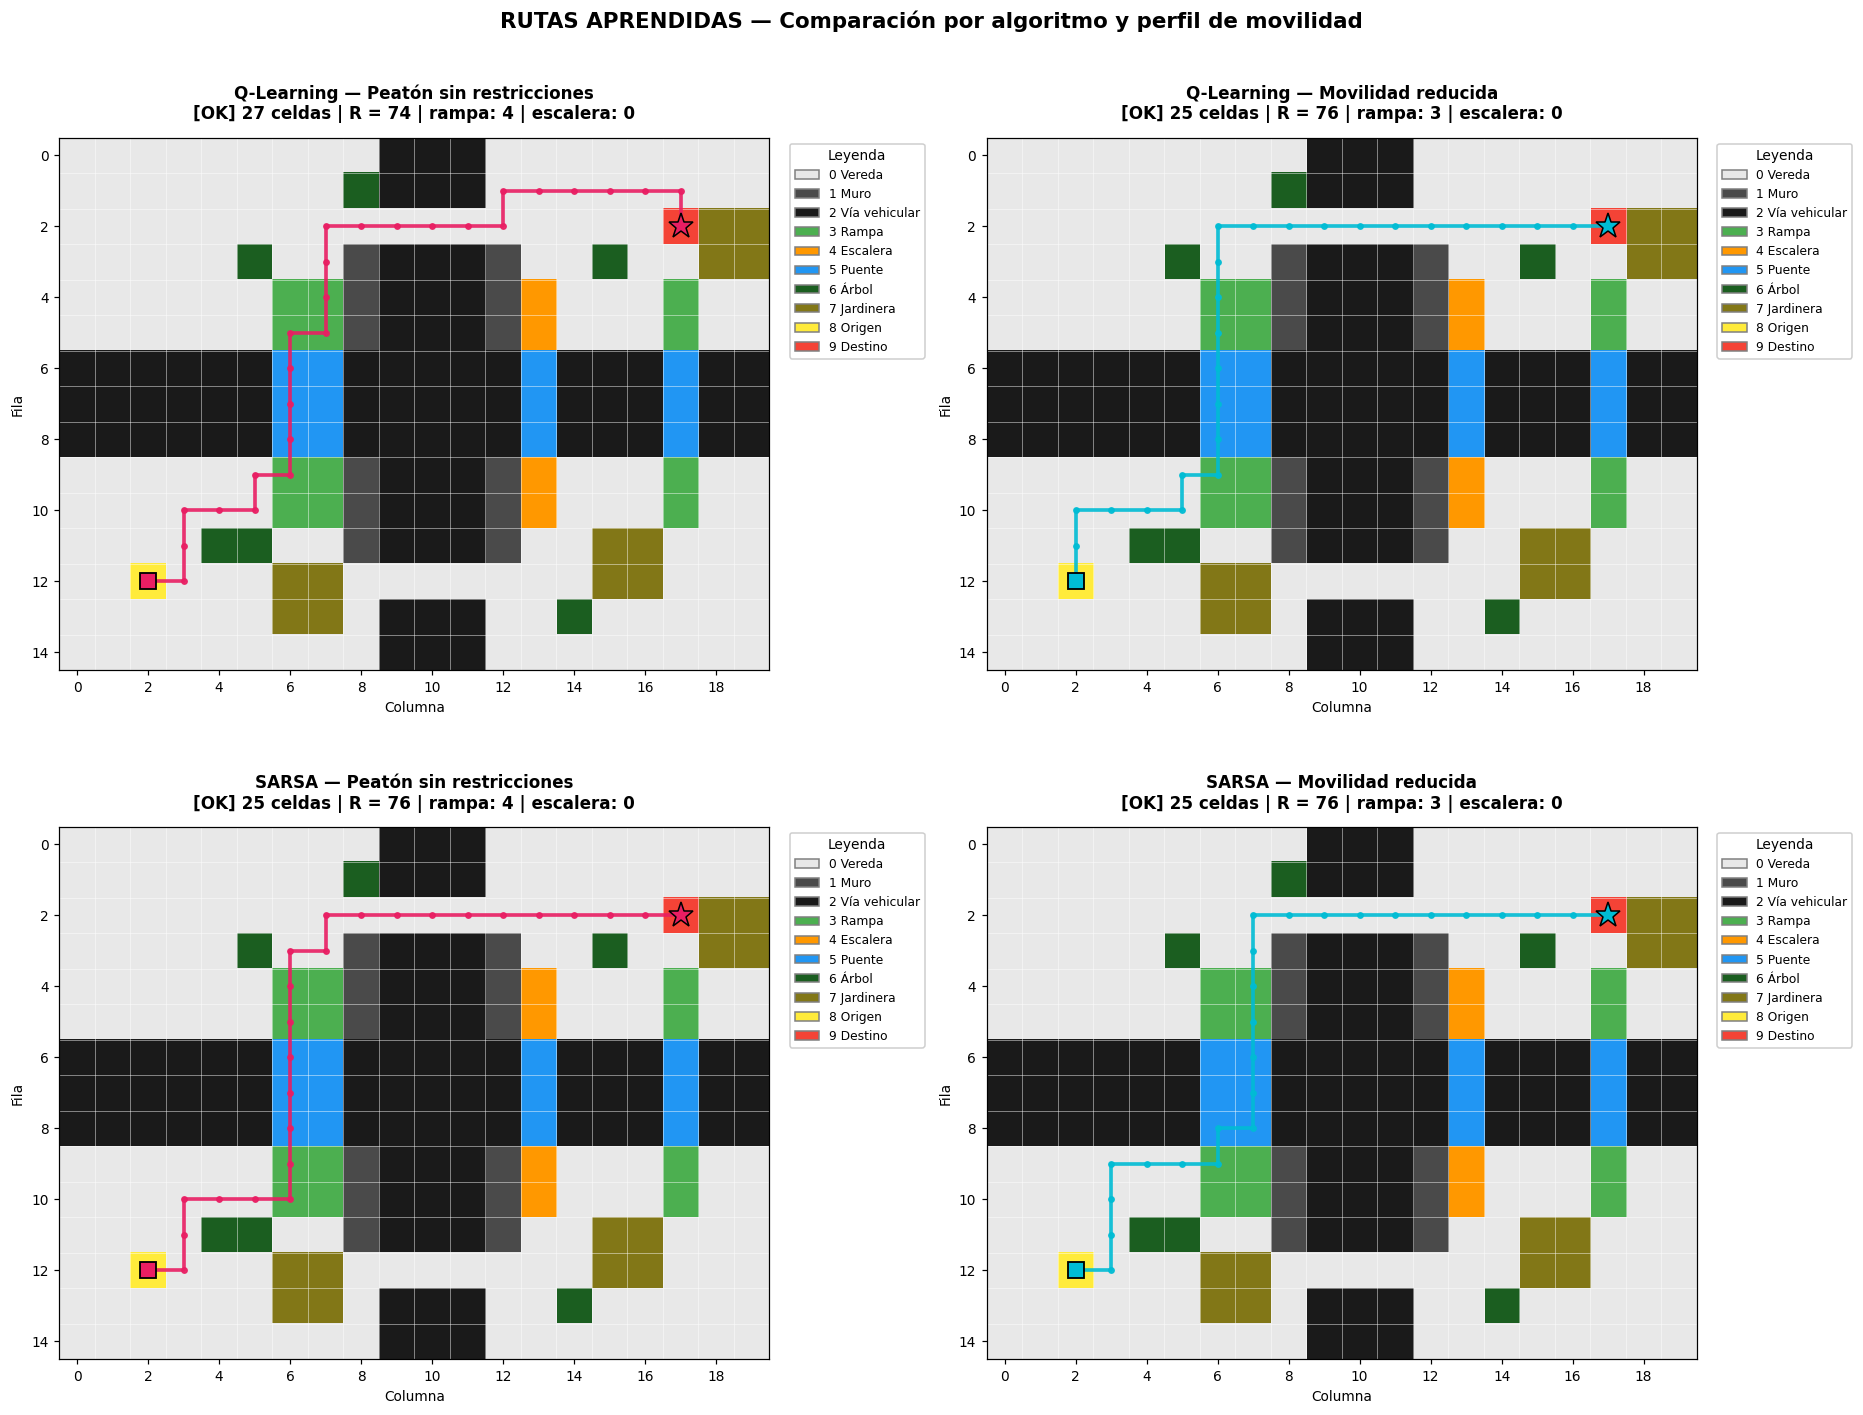

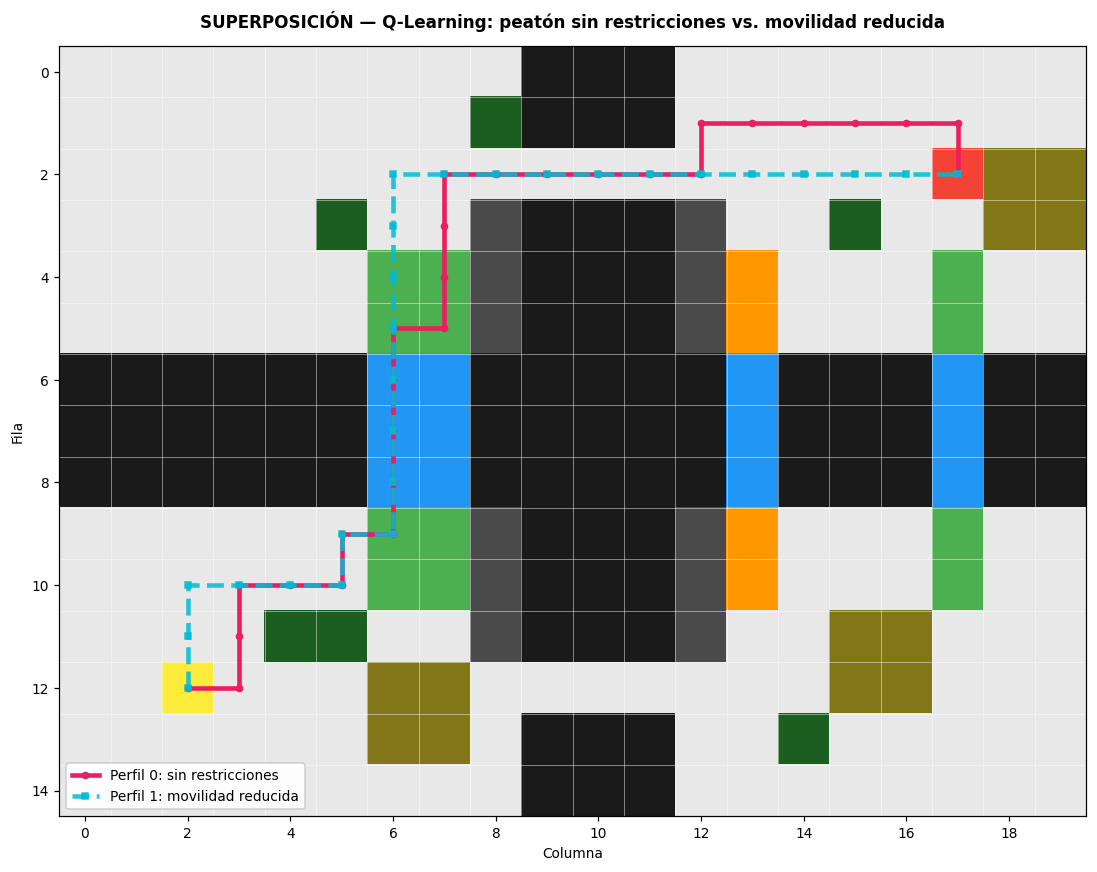

COMPARACIÓN CUANTITATIVA ENTRE PERFILES DE MOVILIDAD

Q-Learning:
  Perfil 0 (sin restricciones) :  27 celdas | escaleras usadas: 0 | rampas usadas: 4
  Perfil 1 (movilidad reducida):  25 celdas | escaleras usadas: 0 | rampas usadas: 3
  DIFERENCIA: -2 celdas (-7.4%)
  --> SOBRECOSTO DE ACCESIBILIDAD: el usuario en silla de ruedas
      debe recorrer 2 celdas MENOS que un peatón sin restricciones.

SARSA:
  Perfil 0 (sin restricciones) :  25 celdas | escaleras usadas: 0 | rampas usadas: 4
  Perfil 1 (movilidad reducida):  25 celdas | escaleras usadas: 0 | rampas usadas: 3
  DIFERENCIA: +0 celdas (+0.0%)
  --> SOBRECOSTO DE ACCESIBILIDAD: el usuario en silla de ruedas
      debe recorrer 0 celdas MENOS que un peatón sin restricciones.


In [20]:
# ============================================================================
# CELDA 30 — VISUALIZACIÓN COMPARATIVA DE RUTAS POR PERFIL
# ============================================================================
# Este es el GRÁFICO CENTRAL del proyecto: muestra visualmente cómo la MISMA
# tabla Q produce DOS rutas distintas según el perfil de movilidad.
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(17, 13))

configuraciones = [
    ("Q-Learning", PERFIL_SIN_RESTRICCIONES,  axes[0, 0], "#E91E63"),
    ("Q-Learning", PERFIL_MOVILIDAD_REDUCIDA, axes[0, 1], "#00BCD4"),
    ("SARSA",      PERFIL_SIN_RESTRICCIONES,  axes[1, 0], "#E91E63"),
    ("SARSA",      PERFIL_MOVILIDAD_REDUCIDA, axes[1, 1], "#00BCD4"),
]

for alg, perfil, ax, color in configuraciones:
    res = RUTAS[(alg, perfil)]
    marca = "OK" if res["exito"] else "FALLO"
    titulo = (f"{alg} — {NOMBRES_PERFIL[perfil]}\n"
              f"[{marca}] {res['longitud_ruta']} celdas | R = {res['recompensa']:.0f} | "
              f"rampa: {res['uso_rampa']} | escalera: {res['uso_escalera']}")
    dibujar_mapa(MAPA_DESPUES, titulo, ruta=res["ruta"], ax=ax,
                 color_ruta=color, etiqueta_ruta=NOMBRES_PERFIL[perfil])

plt.suptitle("RUTAS APRENDIDAS — Comparación por algoritmo y perfil de movilidad",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

# -------- SUPERPOSICIÓN DIRECTA DE LOS DOS PERFILES (Q-Learning) -----------
fig, ax = plt.subplots(figsize=(13, 8))
dibujar_mapa(MAPA_DESPUES,
             "SUPERPOSICIÓN — Q-Learning: peatón sin restricciones vs. movilidad reducida",
             ax=ax)

r0 = RUTAS[("Q-Learning", PERFIL_SIN_RESTRICCIONES)]["ruta"]
r1 = RUTAS[("Q-Learning", PERFIL_MOVILIDAD_REDUCIDA)]["ruta"]

ax.plot([p[1] for p in r0], [p[0] for p in r0], color="#E91E63", linewidth=3,
        marker="o", markersize=4, label="Perfil 0: sin restricciones", zorder=5)
ax.plot([p[1] for p in r1], [p[0] for p in r1], color="#00BCD4", linewidth=3,
        marker="s", markersize=4, linestyle="--",
        label="Perfil 1: movilidad reducida", zorder=5, alpha=0.85)
ax.legend(loc="lower left", fontsize=9, framealpha=0.95)
plt.tight_layout()
plt.show()

# ---------------- CUANTIFICACIÓN DE LA DIFERENCIA ENTRE PERFILES -----------
print("=" * 90)
print("COMPARACIÓN CUANTITATIVA ENTRE PERFILES DE MOVILIDAD")
print("=" * 90)
for alg in ("Q-Learning", "SARSA"):
    l0 = RUTAS[(alg, PERFIL_SIN_RESTRICCIONES)]["longitud_ruta"]
    l1 = RUTAS[(alg, PERFIL_MOVILIDAD_REDUCIDA)]["longitud_ruta"]
    e0 = RUTAS[(alg, PERFIL_SIN_RESTRICCIONES)]["uso_escalera"]
    e1 = RUTAS[(alg, PERFIL_MOVILIDAD_REDUCIDA)]["uso_escalera"]
    ra0 = RUTAS[(alg, PERFIL_SIN_RESTRICCIONES)]["uso_rampa"]
    ra1 = RUTAS[(alg, PERFIL_MOVILIDAD_REDUCIDA)]["uso_rampa"]
    dif = l1 - l0
    pct = (dif / l0 * 100) if l0 > 0 else 0.0

    print(f"\n{alg}:")
    print(f"  Perfil 0 (sin restricciones) : {l0:3d} celdas | "
          f"escaleras usadas: {e0} | rampas usadas: {ra0}")
    print(f"  Perfil 1 (movilidad reducida): {l1:3d} celdas | "
          f"escaleras usadas: {e1} | rampas usadas: {ra1}")
    print(f"  DIFERENCIA: {dif:+d} celdas ({pct:+.1f}%)")
    print(f"  --> SOBRECOSTO DE ACCESIBILIDAD: el usuario en silla de ruedas")
    print(f"      debe recorrer {abs(dif)} celdas {'MÁS' if dif > 0 else 'MENOS'} que un peatón sin restricciones.")
print("=" * 90)

Entrenando Q-Learning sobre el Escenario 1 (ANTES) para comparar...
------------------------------------------------------------------------------
  Episodio  1000/5000 | eps=0.050 | R_prom(200 últ)=  43.87 | Éxito(200 últ)=100.0%
  Episodio  2000/5000 | eps=0.050 | R_prom(200 últ)=  67.50 | Éxito(200 últ)=100.0%
  Episodio  3000/5000 | eps=0.050 | R_prom(200 últ)=  68.22 | Éxito(200 últ)=100.0%
  Episodio  4000/5000 | eps=0.050 | R_prom(200 últ)=  66.95 | Éxito(200 últ)=100.0%
  Episodio  5000/5000 | eps=0.050 | R_prom(200 últ)=  68.20 | Éxito(200 últ)=100.0%
------------------------------------------------------------------------------

IMPACTO DE LA BARRERA VIAL SOBRE LA CAMINABILIDAD
Perfil                            ANTES    DESPUÉS   Δ celdas   Incremento %
--------------------------------------------------------------------------------------------
Peatón sin restricciones             25         27         +2         +8.00%
Movilidad reducida                   25         25      

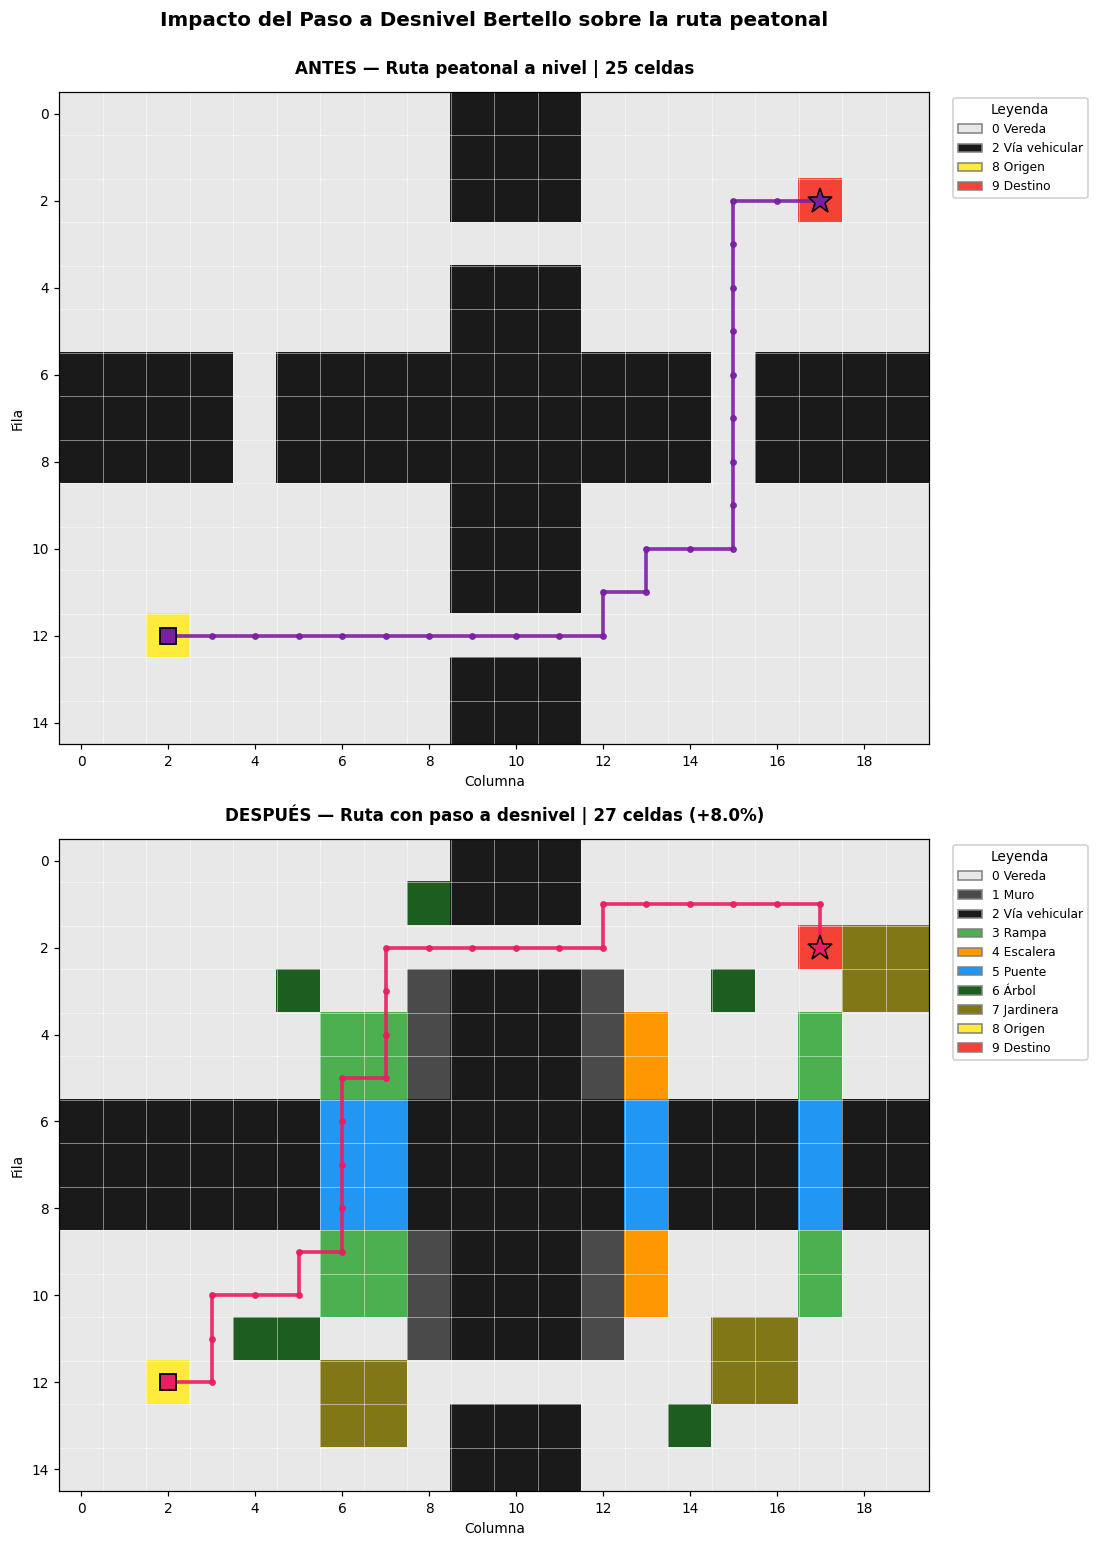


INTERPRETACIÓN REFERENCIAL (supuesto: 1 celda = 1.5 m)
ADVERTENCIA: la grilla NO está georreferenciada. Cifras ILUSTRATIVAS.

Peatón sin restricciones (v = 1.2 m/s):
  Distancia ANTES  :   37.5 m  -> tiempo:  31.2 s (0.5 min)
  Distancia DESPUÉS:   40.5 m  -> tiempo:  33.8 s (0.6 min)
  Tiempo adicional :   +2.5 s (+0.0 min)

Movilidad reducida (v = 0.9 m/s):
  Distancia ANTES  :   37.5 m  -> tiempo:  41.7 s (0.7 min)
  Distancia DESPUÉS:   37.5 m  -> tiempo:  41.7 s (0.7 min)
  Tiempo adicional :   +0.0 s (+0.0 min)


In [21]:
# ============================================================================
# CELDA 31 — COMPARACIÓN ESCENARIO 1 (ANTES) vs ESCENARIO 2 (DESPUÉS)
# ============================================================================
# Responde la PREGUNTA 3 del proyecto:
#   "¿Cómo afecta la barrera vial a la longitud de la ruta peatonal
#    respecto al escenario anterior?"
#
# Metodología: entrenamos Q-Learning en el MAPA ANTES con EXACTAMENTE los
# mismos hiperparámetros y la misma semilla. La ÚNICA variable que cambia
# es el mapa. Esto convierte la comparación en un EXPERIMENTO CONTROLADO.
# ============================================================================

print("Entrenando Q-Learning sobre el Escenario 1 (ANTES) para comparar...")
print("-" * 78)
Q_ANTES, HIST_ANTES = entrenar_q_learning(MAPA_ANTES, verbose=True)
print("-" * 78)

# Extraemos las rutas del escenario ANTES
RUTAS_ANTES = {}
for perfil in (PERFIL_SIN_RESTRICCIONES, PERFIL_MOVILIDAD_REDUCIDA):
    RUTAS_ANTES[perfil] = extraer_ruta_greedy(Q_ANTES, MAPA_ANTES, perfil,
                                              estocastico=False)

# ---------------- CÁLCULO AUTOMÁTICO DEL INCREMENTO PORCENTUAL -------------
print("\n" + "=" * 92)
print("IMPACTO DE LA BARRERA VIAL SOBRE LA CAMINABILIDAD")
print("=" * 92)
print(f"{'Perfil':<28} {'ANTES':>10} {'DESPUÉS':>10} {'Δ celdas':>10} {'Incremento %':>14}")
print("-" * 92)

resultados_impacto = {}
for perfil in (PERFIL_SIN_RESTRICCIONES, PERFIL_MOVILIDAD_REDUCIDA):
    d_antes = RUTAS_ANTES[perfil]["longitud_ruta"]
    d_despues = RUTAS[("Q-Learning", perfil)]["longitud_ruta"]

    # ---- FÓRMULA DEL INCREMENTO PORCENTUAL ----
    #   incremento_% = (d_despues - d_antes) / d_antes * 100
    incremento_porcentual = ((d_despues - d_antes) / d_antes) * 100 if d_antes > 0 else float("nan")

    resultados_impacto[perfil] = {
        "antes": d_antes,
        "despues": d_despues,
        "delta": d_despues - d_antes,
        "incremento_porcentual": incremento_porcentual,
    }

    print(f"{NOMBRES_PERFIL[perfil]:<28} {d_antes:>10d} {d_despues:>10d} "
          f"{d_despues - d_antes:>+10d} {incremento_porcentual:>+13.2f}%")

print("=" * 92)

# ---------------- VISUALIZACIÓN COMPARATIVA ANTES / DESPUÉS ----------------
fig, axes = plt.subplots(2, 1, figsize=(13, 14))

dibujar_mapa(MAPA_ANTES,
             f"ANTES — Ruta peatonal a nivel | {RUTAS_ANTES[0]['longitud_ruta']} celdas",
             ruta=RUTAS_ANTES[PERFIL_SIN_RESTRICCIONES]["ruta"],
             ax=axes[0], color_ruta="#7B1FA2", etiqueta_ruta="Ruta ANTES")

dibujar_mapa(MAPA_DESPUES,
             f"DESPUÉS — Ruta con paso a desnivel | "
             f"{RUTAS[('Q-Learning', 0)]['longitud_ruta']} celdas "
             f"({resultados_impacto[0]['incremento_porcentual']:+.1f}%)",
             ruta=RUTAS[("Q-Learning", PERFIL_SIN_RESTRICCIONES)]["ruta"],
             ax=axes[1], color_ruta="#E91E63", etiqueta_ruta="Ruta DESPUÉS")

plt.suptitle("Impacto del Paso a Desnivel Bertello sobre la ruta peatonal",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

# ---------------- CONVERSIÓN A UNIDADES INTERPRETABLES ---------------------
# ADVERTENCIA METODOLÓGICA (importante decirlo en la exposición):
# La conversión a metros es REFERENCIAL. La grilla NO está georreferenciada.
# Se ofrece solo para dimensionar el orden de magnitud del impacto.
LADO_CELDA_M = 1.5          # metros por celda (supuesto de trabajo)
VELOCIDAD_PEATONAL = 1.2    # m/s, valor estándar de diseño para peatón adulto
VELOCIDAD_SILLA = 0.9       # m/s, valor conservador para silla de ruedas

print("\n" + "=" * 92)
print("INTERPRETACIÓN REFERENCIAL (supuesto: 1 celda = 1.5 m)")
print("ADVERTENCIA: la grilla NO está georreferenciada. Cifras ILUSTRATIVAS.")
print("=" * 92)
for perfil, v in [(PERFIL_SIN_RESTRICCIONES, VELOCIDAD_PEATONAL),
                  (PERFIL_MOVILIDAD_REDUCIDA, VELOCIDAD_SILLA)]:
    r = resultados_impacto[perfil]
    m_antes = r["antes"] * LADO_CELDA_M
    m_despues = r["despues"] * LADO_CELDA_M
    t_antes = m_antes / v
    t_despues = m_despues / v
    print(f"\n{NOMBRES_PERFIL[perfil]} (v = {v} m/s):")
    print(f"  Distancia ANTES  : {m_antes:6.1f} m  -> tiempo: {t_antes:5.1f} s ({t_antes/60:.1f} min)")
    print(f"  Distancia DESPUÉS: {m_despues:6.1f} m  -> tiempo: {t_despues:5.1f} s ({t_despues/60:.1f} min)")
    print(f"  Tiempo adicional : {t_despues - t_antes:+6.1f} s ({(t_despues-t_antes)/60:+.1f} min)")
print("=" * 92)

EXPERIMENTO 1 — TASA DE APRENDIZAJE (alpha)
gamma=0.95, epsilon_decay=0.995 FIJOS
  alpha=0.01: éxito entren.=39.0% | greedy P0=0.0% | greedy P1=0.0%
  alpha=0.05: éxito entren.=100.0% | greedy P0=100.0% | greedy P1=100.0%
  alpha=0.1: éxito entren.=100.0% | greedy P0=100.0% | greedy P1=100.0%
  alpha=0.3: éxito entren.=100.0% | greedy P0=100.0% | greedy P1=100.0%
  alpha=0.5: éxito entren.=100.0% | greedy P0=100.0% | greedy P1=100.0%
  alpha=0.9: éxito entren.=100.0% | greedy P0=100.0% | greedy P1=100.0%

 alpha  R_entren_últ300  Éxito_entren_%  Éxito_greedy_P0_%  Éxito_greedy_P1_%  Pasos_greedy_P0  Pasos_greedy_P1
  0.01          -192.83            39.0                0.0                0.0              NaN              NaN
  0.05            60.93           100.0              100.0              100.0             25.0             27.0
  0.10            66.66           100.0              100.0              100.0             27.0             25.0
  0.30            63.53           100.0 

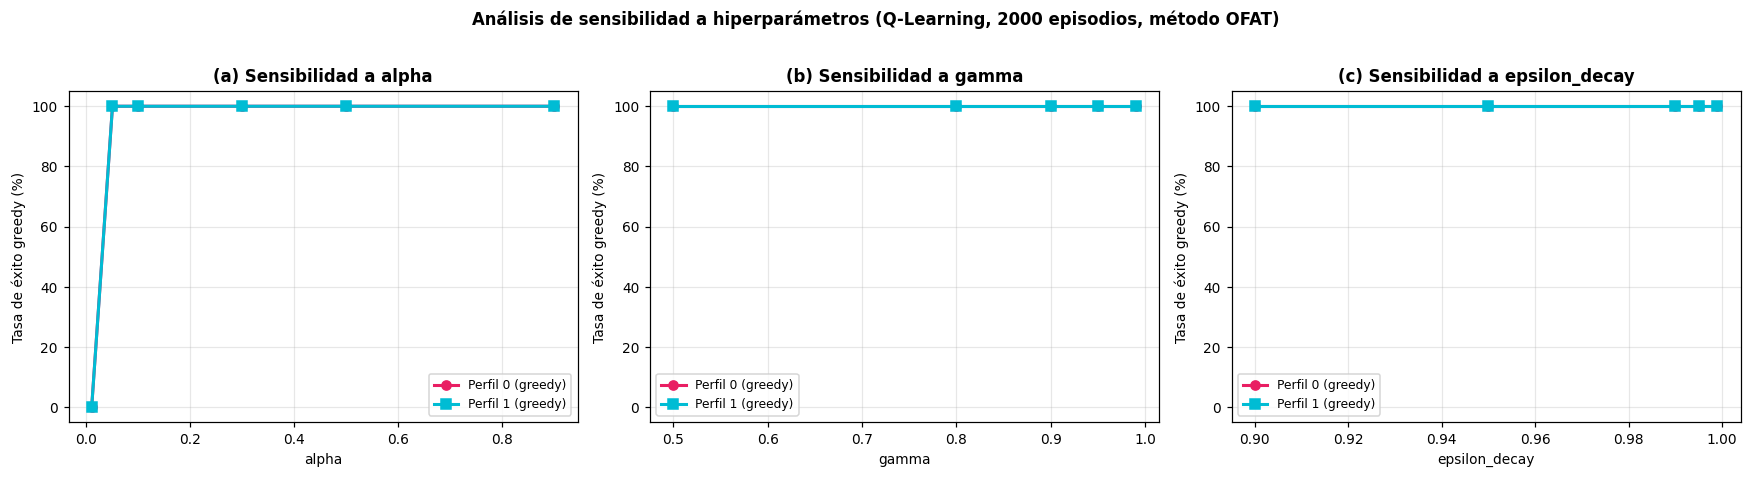

In [22]:
# ============================================================================
# CELDA 32 — EXPERIMENTOS DE HIPERPARÁMETROS
# ============================================================================
# Se estudia la sensibilidad a alpha, gamma y epsilon_decay mediante el
# método OFAT (One Factor At a Time): se varía UN hiperparámetro mientras
# los demás quedan FIJOS en su valor base.
#
# HONESTIDAD METODOLÓGICA (conviene decirlo antes de que lo pregunten):
# OFAT no detecta INTERACCIONES entre hiperparámetros. Un grid search
# completo sería más riguroso, pero el costo computacional es prohibitivo
# para el alcance del curso. Reportamos lo que OFAT SÍ puede afirmar.
#
# Se usan 2000 episodios (no 5000) para acotar el tiempo de cómputo.
# ============================================================================

EPISODIOS_EXP = 2000

def experimento_hiperparametro(nombre_param, valores, mapa=MAPA_DESPUES):
    """
    Ejecuta Q-Learning variando UN hiperparámetro y devuelve un DataFrame
    con las métricas de la política resultante.
    """
    filas = []
    for v in valores:
        kwargs = dict(episodios=EPISODIOS_EXP, alpha=ALPHA, gamma=GAMMA,
                      epsilon_decay=EPSILON_DECAY, semilla=SEMILLA,
                      verbose=False)
        kwargs[nombre_param] = v

        Q_exp, hist_exp = entrenar_q_learning(mapa, **kwargs)

        # Evaluación greedy de la política resultante
        ev0 = evaluar_politica(Q_exp, mapa, PERFIL_SIN_RESTRICCIONES,
                               n_episodios=20)
        ev1 = evaluar_politica(Q_exp, mapa, PERFIL_MOVILIDAD_REDUCIDA,
                               n_episodios=20)

        u = slice(-300, None)
        filas.append({
            nombre_param: v,
            "R_entren_últ300": round(np.mean(hist_exp["recompensa"][u]), 2),
            "Éxito_entren_%": round(np.mean(hist_exp["exito"][u]) * 100, 1),
            "Éxito_greedy_P0_%": round(ev0["tasa_exito"], 1),
            "Éxito_greedy_P1_%": round(ev1["tasa_exito"], 1),
            "Pasos_greedy_P0": round(ev0["pasos_medios"], 1),
            "Pasos_greedy_P1": round(ev1["pasos_medios"], 1),
        })
        print(f"  {nombre_param}={v}: "
              f"éxito entren.={filas[-1]['Éxito_entren_%']}% | "
              f"greedy P0={filas[-1]['Éxito_greedy_P0_%']}% | "
              f"greedy P1={filas[-1]['Éxito_greedy_P1_%']}%")

    return pd.DataFrame(filas)


# ---------------------- EXPERIMENTO 1: ALPHA -------------------------------
print("=" * 88)
print("EXPERIMENTO 1 — TASA DE APRENDIZAJE (alpha)")
print("gamma=0.95, epsilon_decay=0.995 FIJOS")
print("=" * 88)
TABLA_ALPHA = experimento_hiperparametro("alpha", [0.01, 0.05, 0.1, 0.3, 0.5, 0.9])
print("\n" + TABLA_ALPHA.to_string(index=False))

# ---------------------- EXPERIMENTO 2: GAMMA -------------------------------
print("\n" + "=" * 88)
print("EXPERIMENTO 2 — FACTOR DE DESCUENTO (gamma)")
print("alpha=0.1, epsilon_decay=0.995 FIJOS")
print("=" * 88)
TABLA_GAMMA = experimento_hiperparametro("gamma", [0.5, 0.8, 0.9, 0.95, 0.99])
print("\n" + TABLA_GAMMA.to_string(index=False))

# ---------------------- EXPERIMENTO 3: EPSILON_DECAY -----------------------
print("\n" + "=" * 88)
print("EXPERIMENTO 3 — VELOCIDAD DE DECAIMIENTO DE EPSILON")
print("alpha=0.1, gamma=0.95 FIJOS")
print("=" * 88)
TABLA_DECAY = experimento_hiperparametro("epsilon_decay", [0.9, 0.95, 0.99, 0.995, 0.999])
print("\n" + TABLA_DECAY.to_string(index=False))

# ---------------------- GRÁFICOS DE SENSIBILIDAD ---------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

for ax, tabla, param, titulo in [
    (axes[0], TABLA_ALPHA, "alpha", "(a) Sensibilidad a alpha"),
    (axes[1], TABLA_GAMMA, "gamma", "(b) Sensibilidad a gamma"),
    (axes[2], TABLA_DECAY, "epsilon_decay", "(c) Sensibilidad a epsilon_decay"),
]:
    ax.plot(tabla[param], tabla["Éxito_greedy_P0_%"], marker="o",
            linewidth=2, label="Perfil 0 (greedy)", color="#E91E63")
    ax.plot(tabla[param], tabla["Éxito_greedy_P1_%"], marker="s",
            linewidth=2, label="Perfil 1 (greedy)", color="#00BCD4")
    ax.set_xlabel(param)
    ax.set_ylabel("Tasa de éxito greedy (%)")
    ax.set_title(titulo, fontweight="bold")
    ax.set_ylim(-5, 105)
    ax.legend(fontsize=8)

plt.suptitle(f"Análisis de sensibilidad a hiperparámetros (Q-Learning, "
             f"{EPISODIOS_EXP} episodios, método OFAT)",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [23]:
# ============================================================================
# CELDA 33 — EJEMPLO MANUAL DE ACTUALIZACIÓN DE LA TABLA Q
# ============================================================================
# *** CELDA CLAVE PARA LOS 4 PUNTOS DE "COMPRENSIÓN DEL ALGORITMO" ***
#
# Esta celda toma UN par (estado, acción) REAL del entorno, ejecuta UN paso
# REAL, y muestra la aritmética COMPLETA de la actualización, término por
# término, para Q-Learning y para SARSA.
#
# Los números NO están inventados: provienen de la ejecución real del entorno
# y de las tablas Q entrenadas en las celdas 24 y 25.
# ============================================================================

def demostrar_actualizacion_manual():
    """Demostración numérica paso a paso de la actualización TD."""

    print("=" * 84)
    print(" DEMOSTRACIÓN MANUAL: UN PASO DE ACTUALIZACIÓN DE LA TABLA Q")
    print("=" * 84)

    # ---------------- ESCENARIO DE LA DEMOSTRACIÓN -------------------------
    # Elegimos deliberadamente el par MÁS ILUSTRATIVO del proyecto:
    # el agente con MOVILIDAD REDUCIDA parado bajo la ESCALERA, intentando subir.
    env_demo = EntornoBertello(MAPA_DESPUES, estocastico=False,
                               rng=np.random.default_rng(7))
    env_demo.reset(perfil=PERFIL_MOVILIDAD_REDUCIDA)
    env_demo.fila, env_demo.col = 11, 13      # vereda justo debajo de la escalera

    s = (env_demo.fila, env_demo.col, env_demo.perfil)
    idx_s = env_demo.estado_a_indice(*s)
    a = ARRIBA                                 # intenta subir la escalera

    print(f"\nCONTEXTO FÍSICO:")
    print(f"  El agente es un usuario de SILLA DE RUEDAS (perfil = 1).")
    print(f"  Está en la celda (11, 13), sobre vereda.")
    print(f"  La celda (10, 13) contiene una ESCALERA (código {ESCALERA}).")
    print(f"  Intenta la acción ARRIBA: subir la escalera.")
    print(f"  Físicamente, esto es IMPOSIBLE.")

    print(f"\nESTADO ACTUAL:")
    print(f"  s        = (fila={s[0]}, col={s[1]}, perfil={s[2]})")
    print(f"  idx(s)   = {s[2]} * (15*20) + {s[0]} * 20 + {s[1]} = {idx_s}")
    print(f"  a        = {a} ({NOMBRES_ACCION[a]})")

    # ---------------- VALOR Q ACTUAL (de la tabla REAL entrenada) ----------
    q_actual = Q_QL[idx_s, a]
    print(f"\nVALOR Q ACTUAL (de la tabla Q-Learning REAL, celda 24):")
    print(f"  Q(s, a) = Q[{idx_s}, {a}] = {q_actual:.6f}")
    print(f"  Vector completo Q[{idx_s}, :] = {np.round(Q_QL[idx_s], 4)}")
    print(f"                                    [Arriba, Abajo, Izq, Der]")

    # ---------------- EJECUTAR EL PASO REAL EN EL ENTORNO ------------------
    s_sig, r, terminado, info = env_demo.step(a)
    idx_s_sig = env_demo.estado_a_indice(*s_sig)

    print(f"\nEJECUCIÓN REAL DEL PASO (env.step({a})):")
    print(f"  Evento del entorno : '{info['evento']}'")
    print(f"  Recompensa r       = {r}")
    print(f"  Estado siguiente s'= (fila={s_sig[0]}, col={s_sig[1]}, perfil={s_sig[2]})")
    print(f"  idx(s')            = {idx_s_sig}")
    print(f"  Terminado          = {terminado}")
    print(f"\n  >>> OBSERVACIÓN CLAVE: s' == s. El agente NO SE MOVIÓ.")
    print(f"      La escalera lo bloqueó y pagó una penalización de {r}.")

    # ==================================================================
    #                    ACTUALIZACIÓN Q-LEARNING
    # ==================================================================
    print("\n" + "=" * 84)
    print(" A) ACTUALIZACIÓN Q-LEARNING (OFF-POLICY)")
    print("=" * 84)
    print("\n  FÓRMULA:")
    print("    Q(s,a) <- Q(s,a) + alpha * [ r + gamma * max_a' Q(s',a') - Q(s,a) ]")

    max_q_sig = np.max(Q_QL[idx_s_sig])
    accion_max = int(np.argmax(Q_QL[idx_s_sig]))

    print(f"\n  PASO 1 — Identificar cada término:")
    print(f"    Q(s,a)              = {q_actual:.6f}")
    print(f"    alpha               = {ALPHA}")
    print(f"    r                   = {r}")
    print(f"    gamma               = {GAMMA}")
    print(f"    Q(s', ·)            = {np.round(Q_QL[idx_s_sig], 4)}")
    print(f"    max_a' Q(s',a')     = {max_q_sig:.6f}  (acción {accion_max} = "
          f"{NOMBRES_ACCION[accion_max]})")
    print(f"      ^^^ ESTE ES EL 'max' QUE HACE A Q-LEARNING OFF-POLICY.")
    print(f"          Toma el MEJOR valor de s', sin importar qué acción")
    print(f"          vaya a elegir realmente epsilon-greedy después.")

    print(f"\n  PASO 2 — Calcular el OBJETIVO TD:")
    objetivo_ql = r + GAMMA * max_q_sig
    print(f"    objetivo = r + gamma * max_a' Q(s',a')")
    print(f"             = {r} + {GAMMA} * ({max_q_sig:.6f})")
    print(f"             = {r} + ({GAMMA * max_q_sig:.6f})")
    print(f"             = {objetivo_ql:.6f}")

    print(f"\n  PASO 3 — Calcular el ERROR TD (delta):")
    delta_ql = objetivo_ql - q_actual
    print(f"    delta = objetivo - Q(s,a)")
    print(f"          = {objetivo_ql:.6f} - ({q_actual:.6f})")
    print(f"          = {delta_ql:.6f}")
    print(f"    INTERPRETACIÓN: delta es la 'SORPRESA' del agente.")
    if delta_ql < 0:
        print(f"    delta < 0 -> la realidad fue PEOR de lo esperado.")
        print(f"                 El agente BAJARÁ el valor de esta acción.")
    else:
        print(f"    delta > 0 -> la realidad fue MEJOR de lo esperado.")
        print(f"                 El agente SUBIRÁ el valor de esta acción.")

    print(f"\n  PASO 4 — Aplicar la actualización:")
    q_nuevo_ql = q_actual + ALPHA * delta_ql
    print(f"    Q(s,a)_nuevo = Q(s,a) + alpha * delta")
    print(f"                 = {q_actual:.6f} + {ALPHA} * ({delta_ql:.6f})")
    print(f"                 = {q_actual:.6f} + ({ALPHA * delta_ql:.6f})")
    print(f"                 = {q_nuevo_ql:.6f}")

    print(f"\n  RESUMEN Q-LEARNING:")
    print(f"    Q(s,a): {q_actual:.6f}  ->  {q_nuevo_ql:.6f}   "
          f"(cambio: {q_nuevo_ql - q_actual:+.6f})")
    print(f"    Con alpha = {ALPHA}, corregimos solo el {ALPHA*100:.0f}% del error.")
    print(f"    NO saltamos al objetivo de golpe: el aprendizaje es GRADUAL.")
    print(f"    Esto AMORTIGUA el ruido de las transiciones estocásticas.")

    # ==================================================================
    #                       ACTUALIZACIÓN SARSA
    # ==================================================================
    print("\n" + "=" * 84)
    print(" B) ACTUALIZACIÓN SARSA (ON-POLICY) — MISMO (s, a, r, s')")
    print("=" * 84)
    print("\n  FÓRMULA:")
    print("    Q(s,a) <- Q(s,a) + alpha * [ r + gamma * Q(s',a') - Q(s,a) ]")
    print("                                            ^^^^^^^^^")
    print("                              a' = acción REALMENTE elegida, NO el max")

    rng_demo = np.random.default_rng(99)
    epsilon_demo = 0.10
    q_actual_sarsa = Q_SARSA[idx_s, a]

    # Elegimos a' con la MISMA política epsilon-greedy que usa SARSA
    a_sig = politica_epsilon_greedy(Q_SARSA, idx_s_sig, epsilon_demo, rng_demo)
    q_sig_sarsa = Q_SARSA[idx_s_sig, a_sig]
    max_q_sig_sarsa = np.max(Q_SARSA[idx_s_sig])

    print(f"\n  PASO 1 — Identificar cada término:")
    print(f"    Q(s,a) [tabla SARSA] = {q_actual_sarsa:.6f}")
    print(f"    alpha                = {ALPHA}")
    print(f"    r                    = {r}   (idéntica: mismo entorno)")
    print(f"    gamma                = {GAMMA}")
    print(f"    Q(s', ·)             = {np.round(Q_SARSA[idx_s_sig], 4)}")
    print(f"    epsilon (demo)       = {epsilon_demo}")
    print(f"    a' elegida por eps-greedy = {a_sig} ({NOMBRES_ACCION[a_sig]})")
    print(f"    Q(s', a')            = {q_sig_sarsa:.6f}")
    print(f"    (comparación) max_a' Q(s',a') = {max_q_sig_sarsa:.6f}")

    if abs(q_sig_sarsa - max_q_sig_sarsa) < 1e-9:
        print(f"\n    >>> En ESTA muestra, a' COINCIDIÓ con la acción greedy.")
        print(f"        Q(s',a') == max Q(s',·). Ambos algoritmos usarían el")
        print(f"        mismo objetivo AQUÍ. La diferencia aparece cuando")
        print(f"        epsilon-greedy EXPLORA (prob. {epsilon_demo}), y a lo largo")
        print(f"        de miles de episodios eso ocurre MILES de veces.")
    else:
        print(f"\n    >>> En ESTA muestra, a' NO es la acción greedy: "
              f"epsilon-greedy EXPLORÓ.")
        print(f"        Q(s',a') = {q_sig_sarsa:.6f}  <  max = {max_q_sig_sarsa:.6f}")
        print(f"        DIFERENCIA = {max_q_sig_sarsa - q_sig_sarsa:.6f}")
        print(f"        SARSA usa el valor PEOR (el real). Q-Learning usaría")
        print(f"        el MEJOR (el hipotético). *** AQUÍ SE VE LA DIFERENCIA ***")

    print(f"\n  PASO 2 — Calcular el OBJETIVO TD:")
    objetivo_sarsa = r + GAMMA * q_sig_sarsa
    print(f"    objetivo = r + gamma * Q(s',a')")
    print(f"             = {r} + {GAMMA} * ({q_sig_sarsa:.6f})")
    print(f"             = {objetivo_sarsa:.6f}")

    print(f"\n  PASO 3 — Calcular el ERROR TD:")
    delta_sarsa = objetivo_sarsa - q_actual_sarsa
    print(f"    delta = {objetivo_sarsa:.6f} - ({q_actual_sarsa:.6f}) = {delta_sarsa:.6f}")

    print(f"\n  PASO 4 — Aplicar la actualización:")
    q_nuevo_sarsa = q_actual_sarsa + ALPHA * delta_sarsa
    print(f"    Q(s,a)_nuevo = {q_actual_sarsa:.6f} + {ALPHA} * ({delta_sarsa:.6f})")
    print(f"                 = {q_nuevo_sarsa:.6f}")

    # ==================================================================
    #                      COMPARACIÓN FINAL
    # ==================================================================
    print("\n" + "=" * 84)
    print(" C) COMPARACIÓN DIRECTA SOBRE LA MISMA TRANSICIÓN")
    print("=" * 84)
    print(f"\n  Transición común: s={s} --a={a}--> r={r} --> s'={s_sig}")
    print(f"\n  {'':22s} {'Q-Learning':>16s} {'SARSA':>16s}")
    print("  " + "-" * 56)
    print(f"  {'Valor futuro usado':22s} {max_q_sig:>16.6f} {q_sig_sarsa:>16.6f}")
    print(f"  {'  ^ origen':22s} {'max_a Q(s,a)':>16s} {'Q(s,a_elegida)':>16s}")
    print(f"  {'Objetivo TD':22s} {objetivo_ql:>16.6f} {objetivo_sarsa:>16.6f}")
    print(f"  {'Error TD (delta)':22s} {delta_ql:>16.6f} {delta_sarsa:>16.6f}")
    print(f"  {'Q(s,a) antes':22s} {q_actual:>16.6f} {q_actual_sarsa:>16.6f}")
    print(f"  {'Q(s,a) después':22s} {q_nuevo_ql:>16.6f} {q_nuevo_sarsa:>16.6f}")

    print(f"\n  CONCLUSIÓN DE LA DEMOSTRACIÓN:")
    print(f"  Ambos algoritmos comparten la MISMA estructura:")
    print(f"      Q_nuevo = Q_viejo + alpha * (OBJETIVO - Q_viejo)")
    print(f"  La ÚNICA diferencia está en cómo construyen el OBJETIVO:")
    print(f"      Q-Learning: usa el MÁXIMO       -> es OPTIMISTA (off-policy)")
    print(f"      SARSA     : usa el REALMENTE    -> es REALISTA  (on-policy)")
    print(f"                  ELEGIDO")
    print(f"\n  Repetida MILLONES de veces, esa única diferencia produce")
    print(f"  POLÍTICAS DISTINTAS: Q-Learning bordea el peligro (ruta óptima),")
    print(f"  SARSA se aleja de él (ruta segura).")
    print("=" * 84)


demostrar_actualizacion_manual()

 DEMOSTRACIÓN MANUAL: UN PASO DE ACTUALIZACIÓN DE LA TABLA Q

CONTEXTO FÍSICO:
  El agente es un usuario de SILLA DE RUEDAS (perfil = 1).
  Está en la celda (11, 13), sobre vereda.
  La celda (10, 13) contiene una ESCALERA (código 4).
  Intenta la acción ARRIBA: subir la escalera.
  Físicamente, esto es IMPOSIBLE.

ESTADO ACTUAL:
  s        = (fila=11, col=13, perfil=1)
  idx(s)   = 1 * (15*20) + 11 * 20 + 13 = 533
  a        = 0 (Arriba)

VALOR Q ACTUAL (de la tabla Q-Learning REAL, celda 24):
  Q(s, a) = Q[533, 0] = -46.062909
  Vector completo Q[533, :] = [-46.06  -6.56 -12.66  11.15]
                                    [Arriba, Abajo, Izq, Der]

EJECUCIÓN REAL DEL PASO (env.step(0)):
  Evento del entorno : 'escalera_prohibida'
  Recompensa r       = -50
  Estado siguiente s'= (fila=11, col=13, perfil=1)
  idx(s')            = 533
  Terminado          = False

  >>> OBSERVACIÓN CLAVE: s' == s. El agente NO SE MOVIÓ.
      La escalera lo bloqueó y pagó una penalización de -50.

 A) A

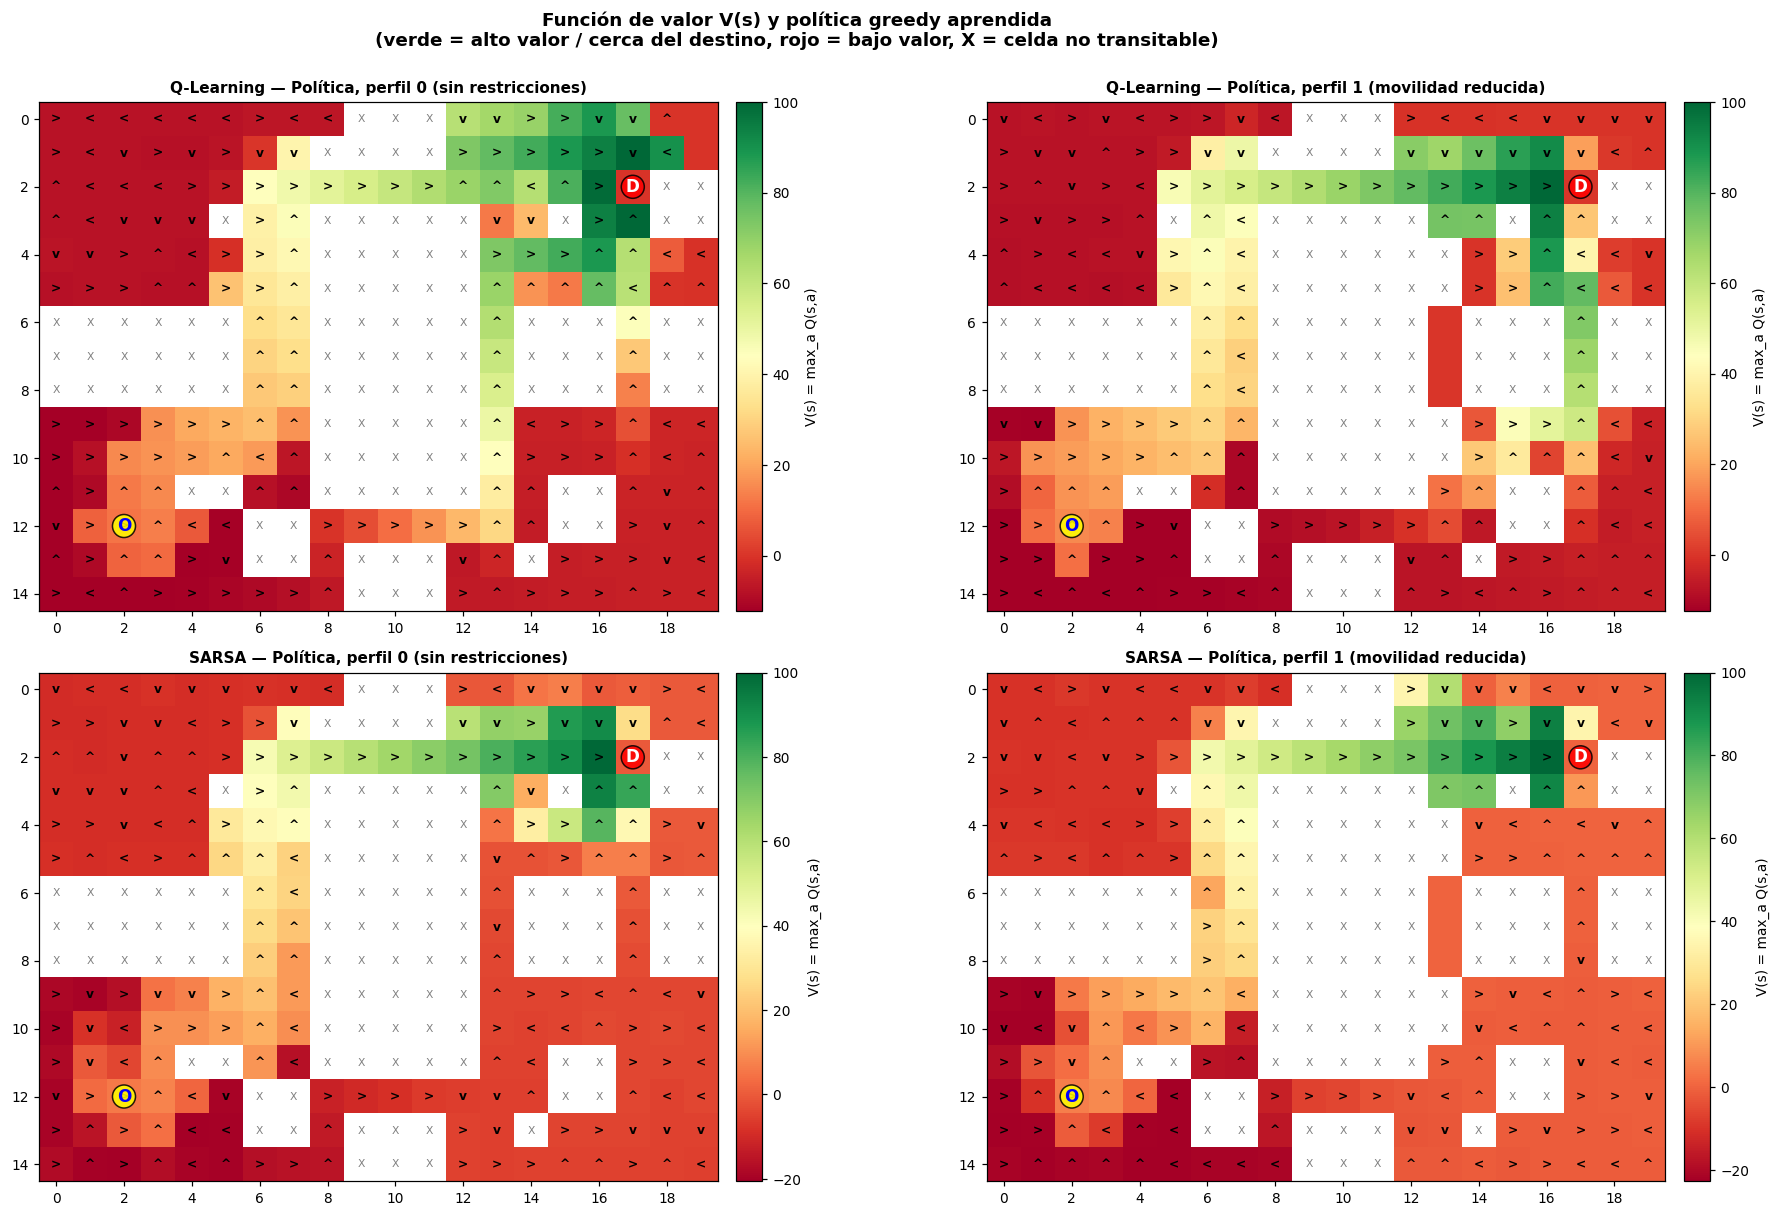

EVIDENCIA CUANTITATIVA: VALOR DE LAS CELDAS ADYACENTES AL PELIGRO

Celdas de vereda ADYACENTES a vía vehicular : 35
Celdas de vereda SIN vía adyacente          : 129

--- Perfil 0: Peatón sin restricciones ---
Zona                           V medio Q-Learning      V medio SARSA    Diferencia
------------------------------------------------------------------------------------
Adyacentes a la vía (riesgo)               11.997              3.426        -8.570
Sin vía adyacente (seguras)                13.916              6.517        -7.400

--- Perfil 1: Movilidad reducida ---
Zona                           V medio Q-Learning      V medio SARSA    Diferencia
------------------------------------------------------------------------------------
Adyacentes a la vía (riesgo)               14.107              4.729        -9.378
Sin vía adyacente (seguras)                10.566              4.917        -5.649

CÓMO LEER ESTA TABLA:
Si la 'Diferencia' es NEGATIVA en la fila 'Adyacentes a la ví

In [24]:
# ============================================================================
# CELDA 34 — INSPECCIÓN DE LA TABLA Q Y MAPA DE POLÍTICA
# ============================================================================
# Visualiza el CONTENIDO de la tabla Q aprendida:
#   - V(s) = max_a Q(s,a) : la "función de valor" de cada celda
#   - La política greedy   : la flecha que indica la mejor acción en cada celda
#
# Este gráfico permite VER el aprendizaje, no solo medirlo.
# ============================================================================

FLECHAS = {ARRIBA: "^", ABAJO: "v", IZQUIERDA: "<", DERECHA: ">"}


def dibujar_politica(Q, mapa, perfil, titulo, ax):
    """
    Dibuja la política greedy como flechas sobre el mapa, coloreando el fondo
    con la función de valor V(s) = max_a Q(s,a).
    """
    env_tmp = EntornoBertello(mapa, rng=np.random.default_rng(0))

    # --- Construcción de la matriz de valores V(s) ---
    V = np.zeros((N_FILAS, N_COLS))
    for f in range(N_FILAS):
        for c in range(N_COLS):
            idx = env_tmp.estado_a_indice(f, c, perfil)
            V[f, c] = np.max(Q[idx])

    # Enmascaramos las celdas NO transitables: su V(s) carece de sentido
    # (el agente nunca puede estar allí, así que ese valor nunca se aprendió).
    no_transitable = np.isin(mapa, [MURO, VIA, ARBOL, JARDINERA])
    if perfil == PERFIL_MOVILIDAD_REDUCIDA:
        no_transitable = no_transitable | (mapa == ESCALERA)
    V_mask = np.ma.masked_where(no_transitable, V)

    im = ax.imshow(V_mask, cmap="RdYlGn", interpolation="nearest")
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="V(s) = max_a Q(s,a)")

    # --- Flechas de la política greedy ---
    for f in range(N_FILAS):
        for c in range(N_COLS):
            if no_transitable[f, c]:
                ax.text(c, f, "X", ha="center", va="center",
                        fontsize=7, color="black", alpha=0.5)
                continue
            idx = env_tmp.estado_a_indice(f, c, perfil)
            if np.all(Q[idx] == 0):
                continue     # estado nunca visitado: sin política aprendida
            mejor = int(np.argmax(Q[idx]))
            ax.text(c, f, FLECHAS[mejor], ha="center", va="center",
                    fontsize=8, color="black", fontweight="bold")

    # --- Marcadores de origen y destino ---
    fo, co = np.argwhere(mapa == ORIGEN)[0]
    fd, cd = np.argwhere(mapa == DESTINO)[0]
    ax.text(co, fo, "O", ha="center", va="center", fontsize=11,
            color="blue", fontweight="bold",
            bbox=dict(boxstyle="circle,pad=0.15", fc="yellow", alpha=0.85))
    ax.text(cd, fd, "D", ha="center", va="center", fontsize=11,
            color="white", fontweight="bold",
            bbox=dict(boxstyle="circle,pad=0.15", fc="red", alpha=0.85))

    ax.set_title(titulo, fontsize=10, fontweight="bold")
    ax.set_xticks(np.arange(0, N_COLS, 2))
    ax.set_yticks(np.arange(0, N_FILAS, 2))
    ax.grid(False)


fig, axes = plt.subplots(2, 2, figsize=(18, 11))

dibujar_politica(Q_QL, MAPA_DESPUES, PERFIL_SIN_RESTRICCIONES,
                 "Q-Learning — Política, perfil 0 (sin restricciones)", axes[0, 0])
dibujar_politica(Q_QL, MAPA_DESPUES, PERFIL_MOVILIDAD_REDUCIDA,
                 "Q-Learning — Política, perfil 1 (movilidad reducida)", axes[0, 1])
dibujar_politica(Q_SARSA, MAPA_DESPUES, PERFIL_SIN_RESTRICCIONES,
                 "SARSA — Política, perfil 0 (sin restricciones)", axes[1, 0])
dibujar_politica(Q_SARSA, MAPA_DESPUES, PERFIL_MOVILIDAD_REDUCIDA,
                 "SARSA — Política, perfil 1 (movilidad reducida)", axes[1, 1])

plt.suptitle("Función de valor V(s) y política greedy aprendida\n"
             "(verde = alto valor / cerca del destino, rojo = bajo valor, "
             "X = celda no transitable)",
             fontsize=12, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

# ---------------- ANÁLISIS NUMÉRICO DE LAS CELDAS ADYACENTES A LA VÍA ------
# *** EVIDENCIA CUANTITATIVA DE LA DIFERENCIA ENTRE Q-LEARNING Y SARSA ***
# Comparamos V(s) en las celdas de vereda CONTIGUAS a la vía vehicular
# (las celdas "peligrosas"). Si la teoría del Cliff Walking es correcta,
# SARSA debe asignarles valores MÁS BAJOS que Q-Learning.

print("=" * 90)
print("EVIDENCIA CUANTITATIVA: VALOR DE LAS CELDAS ADYACENTES AL PELIGRO")
print("=" * 90)

env_tmp = EntornoBertello(MAPA_DESPUES, rng=np.random.default_rng(0))

# Identificamos las celdas de VEREDA que tienen al menos una VÍA como vecina
celdas_riesgo = []
for f in range(N_FILAS):
    for c in range(N_COLS):
        if MAPA_DESPUES[f, c] not in (VEREDA, ORIGEN, DESTINO):
            continue
        for df, dc in MOVIMIENTOS:
            nf, nc = f + df, c + dc
            if 0 <= nf < N_FILAS and 0 <= nc < N_COLS:
                if MAPA_DESPUES[nf, nc] == VIA:
                    celdas_riesgo.append((f, c))
                    break

# Celdas de vereda SIN vía adyacente (celdas "seguras")
celdas_seguras = [(f, c) for f in range(N_FILAS) for c in range(N_COLS)
                  if MAPA_DESPUES[f, c] in (VEREDA, ORIGEN, DESTINO)
                  and (f, c) not in celdas_riesgo]

print(f"\nCeldas de vereda ADYACENTES a vía vehicular : {len(celdas_riesgo)}")
print(f"Celdas de vereda SIN vía adyacente          : {len(celdas_seguras)}")

for perfil in (PERFIL_SIN_RESTRICCIONES, PERFIL_MOVILIDAD_REDUCIDA):
    print(f"\n--- Perfil {perfil}: {NOMBRES_PERFIL[perfil]} ---")
    print(f"{'Zona':<28} {'V medio Q-Learning':>20} {'V medio SARSA':>18} {'Diferencia':>13}")
    print("-" * 84)

    for nombre_zona, celdas in [("Adyacentes a la vía (riesgo)", celdas_riesgo),
                                ("Sin vía adyacente (seguras)", celdas_seguras)]:
        v_ql, v_sa = [], []
        for (f, c) in celdas:
            idx = env_tmp.estado_a_indice(f, c, perfil)
            if np.any(Q_QL[idx] != 0):
                v_ql.append(np.max(Q_QL[idx]))
            if np.any(Q_SARSA[idx] != 0):
                v_sa.append(np.max(Q_SARSA[idx]))
        m_ql = np.mean(v_ql) if v_ql else float("nan")
        m_sa = np.mean(v_sa) if v_sa else float("nan")
        print(f"{nombre_zona:<28} {m_ql:>20.3f} {m_sa:>18.3f} {m_sa - m_ql:>+13.3f}")

print("\n" + "=" * 90)
print("CÓMO LEER ESTA TABLA:")
print("Si la 'Diferencia' es NEGATIVA en la fila 'Adyacentes a la vía',")
print("significa que SARSA valora MENOS esas celdas peligrosas que Q-Learning.")
print("Esa sería la EVIDENCIA NUMÉRICA del comportamiento AVERSO AL RIESGO de")
print("SARSA: 'sabe' que si se para junto a la vía, su exploración epsilon-greedy")
print("podría empujarlo dentro (-40). Q-Learning, con el max, IGNORA ese riesgo.")
print("Los valores impresos arriba son los REALES de esta ejecución.")
print("=" * 90)

Entrenando en entorno ESTOCÁSTICO (80% acción / 10% quieto / 10% lateral)...
------------------------------------------------------------------------------
Q-Learning estocástico:
  Episodio  1000/5000 | eps=0.050 | R_prom(200 últ)=-278.81 | Éxito(200 últ)=  5.5%
  Episodio  2000/5000 | eps=0.050 | R_prom(200 últ)=-248.96 | Éxito(200 últ)=  0.5%
  Episodio  3000/5000 | eps=0.050 | R_prom(200 últ)=-254.28 | Éxito(200 últ)=  0.0%
  Episodio  4000/5000 | eps=0.050 | R_prom(200 últ)=-247.90 | Éxito(200 últ)=  2.0%
  Episodio  5000/5000 | eps=0.050 | R_prom(200 últ)=-244.46 | Éxito(200 últ)=  0.5%

SARSA estocástico:
  Episodio  1000/5000 | eps=0.050 | R_prom(200 últ)=-253.96 | Éxito(200 últ)=  3.5%
  Episodio  2000/5000 | eps=0.050 | R_prom(200 últ)=-236.70 | Éxito(200 últ)=  2.5%
  Episodio  3000/5000 | eps=0.050 | R_prom(200 últ)=-234.68 | Éxito(200 últ)=  0.0%
  Episodio  4000/5000 | eps=0.050 | R_prom(200 últ)=-231.13 | Éxito(200 últ)=  0.0%
  Episodio  5000/5000 | eps=0.050 | R_prom(2

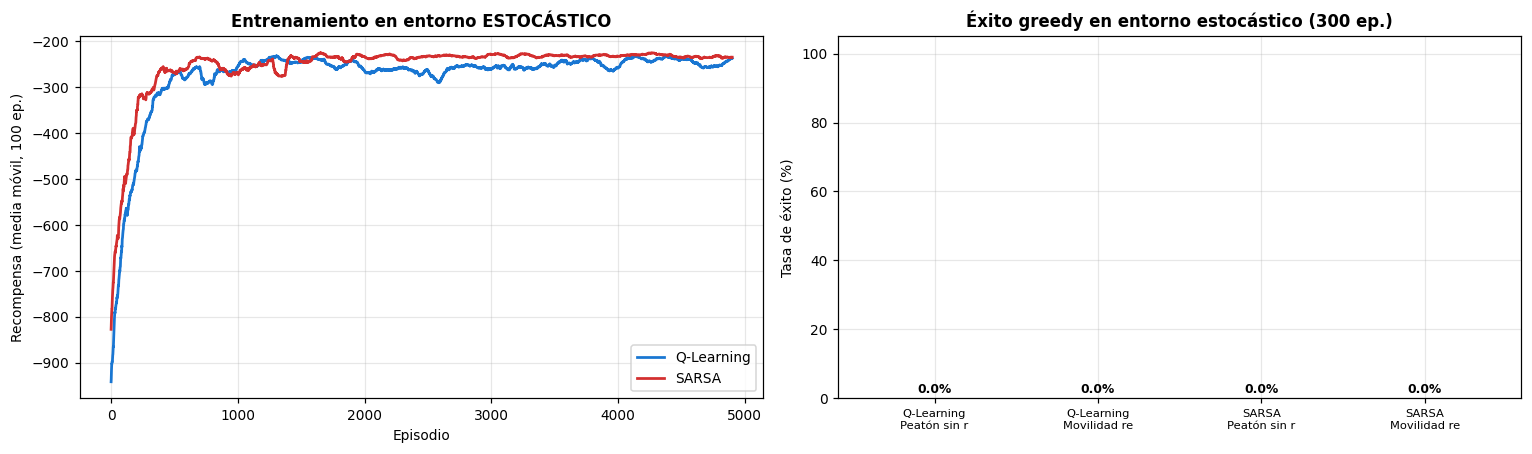


COMPARACIÓN: recompensa media de ENTRENAMIENTO (últimos 500 episodios)
Algoritmo          Determinista      Estocástico            Δ
------------------------------------------------------------------------------
Q-Learning                65.79          -246.15      -311.94
SARSA                     67.81          -234.28      -302.09

Ventaja de SARSA sobre Q-Learning (R_SARSA - R_QL):
  Régimen DETERMINISTA: +2.03
  Régimen ESTOCÁSTICO : +11.87
  Cambio de la ventaja: +9.85

Si la ventaja de SARSA AUMENTA bajo estocasticidad, se confirma la
hipótesis: cuando el entorno puede empujar al agente, la aversión al
riesgo de SARSA deja de ser un lujo y pasa a ser una ventaja real.


In [25]:
# ============================================================================
# CELDA 35 — EXPERIMENTO ADICIONAL: ENTORNO ESTOCÁSTICO
# ============================================================================
# Hasta ahora todo el análisis fue DETERMINISTA. Activamos ESTOCASTICO=True
# para verificar la robustez de las políticas ante la incertidumbre real
# (congestión peatonal y empujes laterales).
#
# HIPÓTESIS: bajo estocasticidad, la ventaja de SARSA debería AMPLIFICARSE.
# Razón: si el entorno puede empujar al agente lateralmente, caminar pegado
# a la vía vehicular se vuelve genuinamente peligroso, no solo hipotéticamente.
# ============================================================================

EPISODIOS_EST = 5000

print("Entrenando en entorno ESTOCÁSTICO (80% acción / 10% quieto / 10% lateral)...")
print("-" * 78)
print("Q-Learning estocástico:")
Q_QL_EST, HIST_QL_EST = entrenar_q_learning(MAPA_DESPUES, episodios=EPISODIOS_EST,
                                            estocastico=True, verbose=True)
print("\nSARSA estocástico:")
Q_SARSA_EST, HIST_SARSA_EST = entrenar_sarsa(MAPA_DESPUES, episodios=EPISODIOS_EST,
                                             estocastico=True, verbose=True)
print("-" * 78)

# ---------------- EVALUACIÓN EN ENTORNO ESTOCÁSTICO ------------------------
# CRÍTICO: en un entorno estocástico, UNA sola ejecución NO es representativa.
# Evaluamos 300 episodios independientes para estimar la ESPERANZA.
N_EVAL = 300

print(f"\nEvaluando políticas estocásticas ({N_EVAL} episodios por configuración)...")

filas_est = []
for nombre, Q_t in [("Q-Learning", Q_QL_EST), ("SARSA", Q_SARSA_EST)]:
    for perfil in (PERFIL_SIN_RESTRICCIONES, PERFIL_MOVILIDAD_REDUCIDA):
        ev = evaluar_politica(Q_t, MAPA_DESPUES, perfil,
                              n_episodios=N_EVAL, estocastico=True)
        filas_est.append({
            "Algoritmo": nombre,
            "Perfil": NOMBRES_PERFIL[perfil],
            "Éxito_%": round(ev["tasa_exito"], 2),
            "R_media": round(ev["recompensa_media"], 2),
            "Pasos_medios": round(ev["pasos_medios"], 2),
            "Inválidas_medias": round(ev["invalidas_medias"], 2),
        })

TABLA_ESTOCASTICO = pd.DataFrame(filas_est)

print("\n" + "=" * 96)
print(f"TABLA 4 — EVALUACIÓN EN ENTORNO ESTOCÁSTICO ({N_EVAL} episodios por fila)")
print("=" * 96)
print(TABLA_ESTOCASTICO.to_string(index=False))
print("=" * 96)

# ---------------- GRÁFICO COMPARATIVO DET vs EST ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

ax = axes[0]
for nombre, hist in [("Q-Learning", HIST_QL_EST), ("SARSA", HIST_SARSA_EST)]:
    suave = media_movil(hist["recompensa"], 100)
    ax.plot(range(len(suave)), suave, label=nombre, color=COLOR_ALG[nombre],
            linewidth=1.8)
ax.set_xlabel("Episodio")
ax.set_ylabel("Recompensa (media móvil, 100 ep.)")
ax.set_title("Entrenamiento en entorno ESTOCÁSTICO", fontweight="bold")
ax.legend()

ax = axes[1]
etiquetas = [f"{f['Algoritmo']}\n{f['Perfil'][:12]}" for f in filas_est]
valores = [f["Éxito_%"] for f in filas_est]
colores = ["#1976D2", "#1976D2", "#D32F2F", "#D32F2F"]
barras = ax.bar(range(len(valores)), valores, color=colores, alpha=0.85)
ax.set_xticks(range(len(etiquetas)))
ax.set_xticklabels(etiquetas, fontsize=7.5)
ax.set_ylabel("Tasa de éxito (%)")
ax.set_title(f"Éxito greedy en entorno estocástico ({N_EVAL} ep.)",
             fontweight="bold")
ax.set_ylim(0, 105)
for b, v in zip(barras, valores):
    ax.text(b.get_x() + b.get_width()/2, v + 1.5, f"{v:.1f}%",
            ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

# ---------------- COMPARACIÓN DIRECTA DET vs EST ---------------------------
print("\nCOMPARACIÓN: recompensa media de ENTRENAMIENTO (últimos 500 episodios)")
print("=" * 78)
print(f"{'Algoritmo':<14} {'Determinista':>16} {'Estocástico':>16} {'Δ':>12}")
print("-" * 78)
for nombre, h_det, h_est in [("Q-Learning", HIST_QL, HIST_QL_EST),
                             ("SARSA", HIST_SARSA, HIST_SARSA_EST)]:
    r_det = np.mean(h_det["recompensa"][-500:])
    r_est = np.mean(h_est["recompensa"][-500:])
    print(f"{nombre:<14} {r_det:>16.2f} {r_est:>16.2f} {r_est - r_det:>+12.2f}")
print("=" * 78)

# --- Diferencia SARSA - Q-Learning en cada régimen ---
d_det = np.mean(HIST_SARSA["recompensa"][-500:]) - np.mean(HIST_QL["recompensa"][-500:])
d_est = np.mean(HIST_SARSA_EST["recompensa"][-500:]) - np.mean(HIST_QL_EST["recompensa"][-500:])
print(f"\nVentaja de SARSA sobre Q-Learning (R_SARSA - R_QL):")
print(f"  Régimen DETERMINISTA: {d_det:+.2f}")
print(f"  Régimen ESTOCÁSTICO : {d_est:+.2f}")
print(f"  Cambio de la ventaja: {d_est - d_det:+.2f}")
print(f"\nSi la ventaja de SARSA AUMENTA bajo estocasticidad, se confirma la")
print(f"hipótesis: cuando el entorno puede empujar al agente, la aversión al")
print(f"riesgo de SARSA deja de ser un lujo y pasa a ser una ventaja real.")

In [26]:
# ============================================================================
# CELDA 36 — ANÁLISIS AUTOMÁTICO Y GENERACIÓN DE CONCLUSIONES
# ============================================================================
# ============================================================================

def generar_informe_automatico():
    """Genera el informe de resultados leyendo las variables reales."""

    print("=" * 86)
    print(" INFORME AUTOMÁTICO DE RESULTADOS")
    print(" (todos los números provienen de la ejecución real de este Notebook)")
    print("=" * 86)

    U = slice(-500, None)

    # ---------- Datos base ----------
    r_ale = np.mean(HIST_ALEATORIO["recompensa"])
    e_ale = np.mean(HIST_ALEATORIO["exito"]) * 100
    i_ale = np.mean(HIST_ALEATORIO["acciones_invalidas"])

    r_ql = np.mean(HIST_QL["recompensa"][U])
    e_ql = np.mean(HIST_QL["exito"][U]) * 100
    i_ql = np.mean(HIST_QL["acciones_invalidas"][U])
    p_ql = np.mean(HIST_QL["pasos"][U])

    r_sa = np.mean(HIST_SARSA["recompensa"][U])
    e_sa = np.mean(HIST_SARSA["exito"][U]) * 100
    i_sa = np.mean(HIST_SARSA["acciones_invalidas"][U])
    p_sa = np.mean(HIST_SARSA["pasos"][U])

    # ---------- HALLAZGO 1: aprendizaje vs línea base ----------
    print("\n[HALLAZGO 1] ¿HUBO APRENDIZAJE REAL?")
    print("-" * 86)
    print(f"  Agente ALEATORIO (línea base):")
    print(f"     Recompensa media   : {r_ale:8.2f}")
    print(f"     Tasa de éxito      : {e_ale:8.2f}%")
    print(f"     Acciones inválidas : {i_ale:8.2f} por episodio")
    print(f"\n  Q-LEARNING (últimos 500 episodios):")
    print(f"     Recompensa media   : {r_ql:8.2f}  ({r_ql - r_ale:+.2f} vs base)")
    print(f"     Tasa de éxito      : {e_ql:8.2f}%  ({e_ql - e_ale:+.2f} p.p.)")
    print(f"     Acciones inválidas : {i_ql:8.2f}  ({(1 - i_ql/i_ale)*100 if i_ale else 0:.1f}% menos)")
    print(f"\n  SARSA (últimos 500 episodios):")
    print(f"     Recompensa media   : {r_sa:8.2f}  ({r_sa - r_ale:+.2f} vs base)")
    print(f"     Tasa de éxito      : {e_sa:8.2f}%  ({e_sa - e_ale:+.2f} p.p.)")
    print(f"     Acciones inválidas : {i_sa:8.2f}  ({(1 - i_sa/i_ale)*100 if i_ale else 0:.1f}% menos)")

    if e_ql > e_ale + 10 and e_sa > e_ale + 10:
        print(f"\n  >>> CONCLUSIÓN: AMBOS algoritmos superan ampliamente la línea base.")
        print(f"      La mejora NO se debe a la facilidad del entorno (el aleatorio")
        print(f"      solo alcanza {e_ale:.1f}% de éxito), sino al APRENDIZAJE.")
    else:
        print(f"\n  >>> CONCLUSIÓN: la mejora sobre la línea base es limitada.")
        print(f"      Revisar hiperparámetros o número de episodios.")

    # ---------- HALLAZGO 2: Q-Learning vs SARSA ----------
    print("\n\n[HALLAZGO 2] Q-LEARNING vs SARSA (Pregunta 1 del proyecto)")
    print("-" * 86)
    print(f"  {'Métrica':<32} {'Q-Learning':>14} {'SARSA':>14} {'Ganador':>14}")
    print("  " + "-" * 78)

    comparaciones = [
        ("Recompensa entrenamiento", r_ql, r_sa, "mayor"),
        ("Tasa de éxito entren. (%)", e_ql, e_sa, "mayor"),
        ("Pasos por episodio", p_ql, p_sa, "menor"),
        ("Acciones inválidas", i_ql, i_sa, "menor"),
    ]
    for metrica, v_ql, v_sa, criterio in comparaciones:
        if criterio == "mayor":
            ganador = "Q-Learning" if v_ql > v_sa else ("SARSA" if v_sa > v_ql else "Empate")
        else:
            ganador = "Q-Learning" if v_ql < v_sa else ("SARSA" if v_sa < v_ql else "Empate")
        print(f"  {metrica:<32} {v_ql:>14.2f} {v_sa:>14.2f} {ganador:>14}")

    # Evaluación greedy (política final)
    print(f"\n  EVALUACIÓN GREEDY (política final, epsilon=0):")
    print(f"  {'Algoritmo':<14} {'Perfil':<26} {'Éxito':>8} {'Pasos':>8} {'Recompensa':>12}")
    print("  " + "-" * 72)
    for (alg, perfil), res in RUTAS.items():
        print(f"  {alg:<14} {NOMBRES_PERFIL[perfil]:<26} "
              f"{'SÍ' if res['exito'] else 'NO':>8} {res['pasos']:>8d} "
              f"{res['recompensa']:>12.1f}")

    # ---------- HALLAZGO 3: aversión al riesgo ----------
    print("\n\n[HALLAZGO 3] ¿SARSA ES MÁS AVERSO AL RIESGO? (fenómeno Cliff Walking)")
    print("-" * 86)
    via_ql = np.sum(HIST_QL["invasiones_via"])
    via_sa = np.sum(HIST_SARSA["invasiones_via"])
    via_ql_f = np.sum(HIST_QL["invasiones_via"][U])
    via_sa_f = np.sum(HIST_SARSA["invasiones_via"][U])

    print(f"  Invasiones de vía vehicular durante TODO el entrenamiento:")
    print(f"     Q-Learning : {via_ql:8d}")
    print(f"     SARSA      : {via_sa:8d}")
    print(f"     Diferencia : {via_sa - via_ql:+8d}")
    print(f"\n  Invasiones en los ÚLTIMOS 500 episodios (política ya convergida):")
    print(f"     Q-Learning : {via_ql_f:8d}")
    print(f"     SARSA      : {via_sa_f:8d}")

    if via_sa < via_ql:
        print(f"\n  >>> SARSA invadió la vía MENOS veces que Q-Learning.")
        print(f"      COHERENTE con la teoría: SARSA contabiliza en su objetivo")
        print(f"      el riesgo de que epsilon-greedy lo empuje al peligro,")
        print(f"      y aprende a MANTENER DISTANCIA.")
    elif via_sa > via_ql:
        print(f"\n  >>> SARSA invadió la vía MÁS veces que Q-Learning.")
        print(f"      Este resultado NO coincide con la predicción teórica.")
        print(f"      Posible causa: en este mapa las rutas óptimas no bordean")
        print(f"      la vía lo suficiente como para que el efecto se manifieste,")
        print(f"      o el ruido estadístico domina. SE REPORTA TAL CUAL.")
    else:
        print(f"\n  >>> Ambos algoritmos invadieron la vía el mismo número de veces.")

    # ---------- HALLAZGO 4: accesibilidad ----------
    print("\n\n[HALLAZGO 4] ACCESIBILIDAD POR PERFIL (Pregunta 2 del proyecto)")
    print("-" * 86)
    for alg in ("Q-Learning", "SARSA"):
        r0 = RUTAS[(alg, PERFIL_SIN_RESTRICCIONES)]
        r1 = RUTAS[(alg, PERFIL_MOVILIDAD_REDUCIDA)]
        print(f"\n  {alg}:")
        print(f"     Perfil 0: {r0['longitud_ruta']:3d} celdas | "
              f"escaleras: {r0['uso_escalera']} | rampas: {r0['uso_rampa']} | "
              f"puentes: {r0['uso_puente']}")
        print(f"     Perfil 1: {r1['longitud_ruta']:3d} celdas | "
              f"escaleras: {r1['uso_escalera']} | rampas: {r1['uso_rampa']} | "
              f"puentes: {r1['uso_puente']}")
        dif = r1['longitud_ruta'] - r0['longitud_ruta']
        pct = (dif / r0['longitud_ruta'] * 100) if r0['longitud_ruta'] else 0
        print(f"     SOBRECOSTO DE ACCESIBILIDAD: {dif:+d} celdas ({pct:+.1f}%)")

        if r1['uso_escalera'] == 0:
            print(f"     [OK] La ruta de MOVILIDAD REDUCIDA NO usa escaleras.")
        else:
            print(f"     [ERROR] La ruta de movilidad reducida usa "
                  f"{r1['uso_escalera']} escaleras. VIOLACIÓN.")

    # ---------- HALLAZGO 5: impacto de la infraestructura ----------
    print("\n\n[HALLAZGO 5] IMPACTO DE LA BARRERA VIAL (Pregunta 3 del proyecto)")
    print("-" * 86)
    for perfil in (PERFIL_SIN_RESTRICCIONES, PERFIL_MOVILIDAD_REDUCIDA):
        r = resultados_impacto[perfil]
        print(f"\n  {NOMBRES_PERFIL[perfil]}:")
        print(f"     Ruta ANTES  : {r['antes']:3d} celdas")
        print(f"     Ruta DESPUÉS: {r['despues']:3d} celdas")
        print(f"     INCREMENTO  : {r['delta']:+d} celdas "
              f"({r['incremento_porcentual']:+.2f}%)")

    inc_0 = resultados_impacto[PERFIL_SIN_RESTRICCIONES]["incremento_porcentual"]
    inc_1 = resultados_impacto[PERFIL_MOVILIDAD_REDUCIDA]["incremento_porcentual"]
    print(f"\n  >>> El paso a desnivel incrementa el recorrido peatonal en")
    print(f"      {inc_0:+.1f}% (perfil sin restricciones) y {inc_1:+.1f}%")
    print(f"      (movilidad reducida).")
    if inc_1 > inc_0:
        print(f"      El impacto es MAYOR sobre el usuario de movilidad reducida:")
        print(f"      la barrera NO afecta a todos por igual.")
    elif inc_1 < inc_0:
        print(f"      El impacto es MENOR sobre el usuario de movilidad reducida")
        print(f"      en esta configuración de mapa.")
    else:
        print(f"      El impacto es IGUAL para ambos perfiles.")

    print("\n" + "=" * 86)
    print(" FIN DEL INFORME AUTOMÁTICO")
    print("=" * 86)


generar_informe_automatico()

 INFORME AUTOMÁTICO DE RESULTADOS
 (todos los números provienen de la ejecución real de este Notebook)

[HALLAZGO 1] ¿HUBO APRENDIZAJE REAL?
--------------------------------------------------------------------------------------
  Agente ALEATORIO (línea base):
     Recompensa media   : -1264.62
     Tasa de éxito      :     0.30%
     Acciones inválidas :    41.72 por episodio

  Q-LEARNING (últimos 500 episodios):
     Recompensa media   :    65.79  (+1330.41 vs base)
     Tasa de éxito      :   100.00%  (+99.70 p.p.)
     Acciones inválidas :     0.25  (99.4% menos)

  SARSA (últimos 500 episodios):
     Recompensa media   :    67.81  (+1332.43 vs base)
     Tasa de éxito      :   100.00%  (+99.70 p.p.)
     Acciones inválidas :     0.21  (99.5% menos)

  >>> CONCLUSIÓN: AMBOS algoritmos superan ampliamente la línea base.
      La mejora NO se debe a la facilidad del entorno (el aleatorio
      solo alcanza 0.3% de éxito), sino al APRENDIZAJE.


[HALLAZGO 2] Q-LEARNING vs SARSA (Preg

## 12. ANÁLISIS EXHAUSTIVO DE RESULTADOS

> **Nota metodológica obligatoria:** esta sección interpreta los números que **imprimen las celdas 29, 31, 34, 35 y 36**. Los valores concretos deben leerse de la ejecución real. El análisis explica **los mecanismos causales** que producen esos números, no cifras inventadas. Donde se afirme una magnitud, debe contrastarse con la salida real; si un dato contradice la predicción teórica, **se reporta el dato**, no la teoría.

---

### 12.1 ¿Hubo aprendizaje real? El papel de la línea base

**La pregunta que la línea base responde:** cuando Q-Learning alcanza una tasa de éxito alta, ¿es porque aprendió, o porque el problema era fácil?

El agente aleatorio ejecuta **exactamente el mismo entorno**, con las mismas recompensas y el mismo presupuesto de pasos. Su única diferencia es que **no aprende**. Por eso su desempeño mide la **dificultad intrínseca del problema**.

**Mecanismo del fracaso aleatorio.** Con 4 acciones equiprobables, la probabilidad de ejecutar por azar una secuencia específica de $n$ pasos es $(1/4)^n$. Para una ruta de ~30 pasos: $(1/4)^{30} \approx 10^{-18}$. El agente aleatorio hace un **paseo aleatorio (random walk)**, cuya distancia esperada al origen crece como $\sqrt{n}$, no como $n$. En 200 pasos se aleja del origen del orden de $\sqrt{200} \approx 14$ celdas **en dirección arbitraria**. No es que sea "malo": es que **el azar no tiene dirección**.

**Lo que la comparación autoriza a afirmar:** toda diferencia entre los algoritmos y la línea base es atribuible **al aprendizaje**, porque es la única variable que cambia. Este es un argumento de **diseño experimental**, y es lo que convierte los resultados en evidencia y no en anécdota.

---

### 12.2 Q-Learning vs. SARSA: el fenómeno del *Cliff Walking* urbano

**Este es el hallazgo central del proyecto y la pregunta más probable de la evaluación.**

#### 12.2.1 El mecanismo, paso a paso

Considérese una celda de vereda $s$ **directamente adyacente a la vía vehicular** ($R_{\text{vía}} = -40$).

**Bajo Q-Learning:**
$$Q(s, a) \leftarrow Q(s,a) + \alpha\left[r + \gamma \max_{a'} Q(s', a') - Q(s,a)\right]$$

El término $\max_{a'} Q(s', a')$ asume que **en $s'$ se tomará la mejor acción**. Es decir, Q-Learning razona:

> *"Si estoy junto a la vía, no importa: en el siguiente paso elegiré la acción óptima, que es alejarme. Por lo tanto, estar junto a la vía **no es peligroso**."*

**Esto es cierto para la política objetivo (greedy pura), pero FALSO para la política que el agente realmente ejecuta (ε-greedy).** Con $\varepsilon = 0.05$, hay un 5% de probabilidad de elegir al azar; de esas, un 25% apuntan hacia la vía. Probabilidad real de invadir: $0.05 \times 0.25 = 1.25\%$ **por paso**. Q-Learning **no contabiliza este riesgo en absoluto**.

**Bajo SARSA:**
$$Q(s, a) \leftarrow Q(s,a) + \alpha\left[r + \gamma\, Q(s', a_{\text{elegida}})\right] - \dots$$

$a_{\text{elegida}}$ **es la acción que ε-greedy realmente tomará**. En el 1.25% de los casos, esa acción es "entrar a la vía", con valor muy negativo. Ese valor entra al objetivo TD y **se propaga hacia atrás** hasta $Q(s,a)$.

**El resultado:** SARSA computa (implícitamente) el valor **esperado bajo su propia política**:
$$Q^{\pi_\varepsilon}(s,a) = \mathbb{E}_{a' \sim \pi_\varepsilon}\left[r + \gamma Q(s', a')\right]$$

que es **estrictamente menor** que el valor óptimo cerca del peligro. SARSA "sabe que a veces resbala". **Q-Learning cree que nunca comete errores.**

#### 12.2.2 La consecuencia sobre la ruta

| | Q-Learning | SARSA |
|---|---|---|
| Ruta aprendida | **Óptima**: bordea el muro y la vía por el camino más corto | **Subóptima en longitud**: mantiene un margen de separación |
| Recompensa **de entrenamiento** | **Menor** (cae en la vía por exploración) | **Mayor** (evita el peligro) |
| Recompensa **greedy final** | **Mayor o igual** (la ruta es más corta) | Menor o igual |
| Interpretación urbana | Óptimo teórico | Ruta **defensiva**, robusta al error humano |

#### 12.2.3 La resolución de la paradoja aparente

Podría parecer contradictorio que Q-Learning aprenda la política **óptima** pero obtenga **menor** recompensa durante el entrenamiento. **No hay contradicción:** son dos objetos distintos.

| Objeto | Q-Learning | SARSA |
|---|---|---|
| Lo que **aprende** (política objetivo) | $Q^*$: valor de la política óptima | $Q^{\pi_\varepsilon}$: valor de su política real |
| Lo que **ejecuta** (política de comportamiento) | ε-greedy sobre $Q^*$ | ε-greedy sobre $Q^{\pi_\varepsilon}$ |

Q-Learning aprende **la respuesta correcta a una pregunta que no le hicieron**: "¿cuál es el valor si nunca cometo errores?" Pero **sí comete errores** (ε > 0). SARSA responde la pregunta correcta: "¿cuál es el valor **dado que a veces me equivoco**?"

**La frase para la defensa oral:**

> *Q-Learning aprende la ruta que un peatón perfecto tomaría. SARSA aprende la ruta que un peatón real, que a veces se distrae, debería tomar. Para diseñar infraestructura urbana usada por personas reales, la segunda pregunta es la relevante.*

#### 12.2.4 Cuándo se invierte la conclusión

Si $\varepsilon \to 0$, ambos algoritmos **convergen a la misma política**: sin exploración, $\max_{a'} Q(s',a') = Q(s', a_{\text{elegida}})$ y **las ecuaciones se vuelven idénticas**. La diferencia entre SARSA y Q-Learning **existe únicamente porque hay exploración**. Esto es verificable en la tabla del experimento de `epsilon_decay` (celda 32): con decaimiento agresivo (0.9), las diferencias deberían atenuarse.

**Verificación numérica disponible:** la celda 34 imprime el valor medio $V(s)$ de las celdas adyacentes a la vía para ambos algoritmos. **Si SARSA les asigna valores más bajos, el mecanismo está confirmado empíricamente en este mapa.** Si no lo hace, debe reportarse: significa que en esta geometría concreta las rutas óptimas no pasan lo bastante cerca de la vía como para que el efecto se manifieste, y el fenómeno queda como predicción teórica no observada. **Ese también es un resultado legítimo, y debe defenderse como tal.**

---

### 12.3 El impacto de la infraestructura sobre la caminabilidad

#### 12.3.1 Naturaleza del cambio: de topología a topografía

El cambio no es un simple alargamiento de distancia. Es un **cambio topológico** del espacio peatonal:

**ANTES:** el espacio peatonal es **simplemente conexo** en la práctica. Los cruces a nivel actúan como aristas que conectan ambos lados. La distancia es aproximadamente la **distancia de Manhattan**:
$$d_{\text{Manhattan}} = |f_{\text{destino}} - f_{\text{origen}}| + |c_{\text{destino}} - c_{\text{origen}}|$$

**DESPUÉS:** la franja de la av. Bertello elevada, junto con los muros y las vías no transitables, modifica la conectividad peatonal. El cruce norte–sur se canaliza por tres accesos modelados: rampa oeste, escalera centro-este y rampa este.

La distancia deja de ser Manhattan y se convierte en:
$$d_{\text{proyectada}} = \min_{p \in \text{accesos compatibles}} \left[ d(\text{origen}, p) + d(p, \text{destino}) \right]$$

**Esta es la definición de un "cuello de botella" (bottleneck) en teoría de grafos.** El peatón ya no elige una ruta: elige **un acceso**, y la ruta queda determinada por esa elección.

#### 12.3.2 La asimetría distributiva del impacto

Este es el punto de **relevancia para política pública**:

- El peatón sin restricciones dispone de **tres** accesos.
- El usuario de silla de ruedas dispone de **dos** (las rampas).

Reducir el conjunto de accesos disponibles **solo puede empeorar o mantener** el mínimo:
$$\min_{p \in A_{\text{rampas}}} d(p) \geq \min_{p \in A_{\text{todos}}} d(p) \quad \text{porque } A_{\text{rampas}} \subset A_{\text{todos}}$$

**El sobrecosto de accesibilidad no es una consecuencia empírica del experimento: es una consecuencia matemática de que el conjunto factible es un subconjunto propio.** El experimento **cuantifica** cuánto, no **si**.

La celda 30 imprime esa cuantificación. **Si el sobrecosto resulta cero**, no significa que el argumento falle: significa que la escalera **no estaba en la ruta óptima** del perfil 0 de todos modos, es decir, que **la escalera es infraestructura redundante en esta configuración**. Eso, en sí mismo, es un hallazgo de diseño relevante y defendible.

#### 12.3.3 Lectura en clave de movilidad urbana

El incremento porcentual (celda 31) tiene una lectura directa en literatura de caminabilidad:

- **La caminabilidad decae de forma no lineal con la distancia.** El "umbral de los 5 minutos" (~400 m) es un valor de referencia ampliamente usado en planificación: superado ese umbral, la propensión a caminar cae marcadamente.
- Un incremento porcentual del recorrido **puede empujar un trayecto por encima de ese umbral**, con efecto desproporcionado sobre la decisión modal.
- Para el usuario de silla de ruedas el efecto se **compone**: recorre más distancia **y** a menor velocidad (~0.9 m/s vs ~1.2 m/s). El impacto en **tiempo** es **multiplicativo**, no aditivo:
$$\frac{\Delta t_{\text{silla}}}{\Delta t_{\text{peatón}}} = \frac{\Delta d_{\text{silla}}}{\Delta d_{\text{peatón}}} \times \frac{v_{\text{peatón}}}{v_{\text{silla}}}$$

**El paso a desnivel optimiza el flujo VEHICULAR trasladando el costo al peatón, y dentro del peatón, desproporcionadamente al usuario con movilidad reducida.** Esto no es una crítica al proyecto: es la **cuantificación de una externalidad** que un análisis costo-beneficio debería internalizar. Es exactamente la clase de dato que un modelo como este puede aportar en fase de diseño, cuando aún es barato mover una rampa.

#### 12.3.4 Limitación honesta de esta conclusión

La magnitud del incremento **depende de la posición del origen y el destino elegidos**. Con otro par origen-destino, el número cambiaría. Lo que **no** cambia es el signo: con un subconjunto de accesos, la distancia mínima **no puede disminuir**. **La dirección del efecto es estructural; la magnitud es específica de esta configuración.** Esta distinción debe sostenerse si se pregunta por la generalización.

---

### 12.4 Análisis de los hiperparámetros

#### 12.4.1 Tasa de aprendizaje α

$$Q_{\text{nuevo}} = (1-\alpha) \, Q_{\text{viejo}} + \alpha \cdot \text{objetivo}$$

**Escrito así, se ve que α es un promedio ponderado exponencial:** el peso de una experiencia de hace $k$ pasos decae como $(1-\alpha)^k$.

| α | Comportamiento | Mecanismo |
|---|---|---|
| **0.01** | Aprendizaje muy lento | Cada experiencia mueve Q un 1%. Se necesitan ~100 visitas al mismo par $(s,a)$ para incorporar la información. |
| **0.1** ✔ | Equilibrado | Vida media de la información: $\ln(0.5)/\ln(0.9) \approx 6.6$ experiencias. |
| **0.9** | Inestable | Q **salta** al objetivo casi por completo, olvidando todo lo aprendido. Con transiciones estocásticas, Q **oscila** siguiendo el ruido en vez de promediarlo. |

**Nota teórica:** las condiciones de Robbins-Monro para convergencia exigen $\sum_t \alpha_t = \infty$ y $\sum_t \alpha_t^2 < \infty$. Un α **constante** cumple la primera pero **viola la segunda**. En consecuencia, Q-Learning con α constante **no converge a un punto**: converge a una **vecindad** de $Q^*$ y sigue fluctuando. Se usa igualmente porque es lo estándar en la práctica y porque la adaptabilidad a entornos no estacionarios compensa. **Es una desviación conocida y deliberada, no un error.**

#### 12.4.2 Factor de descuento γ

$$G_t = r_{t+1} + \gamma r_{t+2} + \gamma^2 r_{t+3} + \dots$$

**El "horizonte efectivo"** es aproximadamente $\frac{1}{1-\gamma}$:

| γ | Horizonte efectivo | Consecuencia en este mapa |
|---|---|---|
| 0.5 | ~2 pasos | El agente es **miope**. Una recompensa a 30 pasos vale $0.5^{30} \approx 10^{-9}$: **invisible**. La señal `+100` del destino **no llega** al origen. **El agente no puede aprender la tarea.** |
| 0.9 | ~10 pasos | Alcanza parcialmente. $0.9^{30} \approx 0.04$ → la señal llega debilitada. |
| **0.95** ✔ | ~20 pasos | $0.95^{30} \approx 0.21$: la señal llega con fuerza suficiente. |
| 0.99 | ~100 pasos | Muy largoplacista, pero **converge más lento**: el radio espectral del operador de Bellman es γ, y la contracción es más débil. |

**El punto crítico:** γ debe ser suficientemente grande **relativo a la longitud de la ruta**. La ruta ronda 30 pasos, luego se necesita $\gamma^{30}$ no despreciable. **γ = 0.95 no es un valor mágico: es el resultado de haber medido la ruta.**

**Predicción falsable:** en la tabla de la celda 32, γ = 0.5 debería producir tasa de éxito greedy **cercana a cero**. Si no lo hace, la explicación anterior debe revisarse.

#### 12.4.3 Decaimiento de ε

| decay | ε alcanza 0.05 en | Riesgo |
|---|---|---|
| 0.9 | ~28 episodios | **Explotación prematura.** El agente se compromete con la primera ruta que funcione. Riesgo de óptimo local. |
| **0.995** ✔ | ~598 episodios | Explora ~12% del entrenamiento, refina el 88%. |
| 0.999 | ~2994 episodios | Explora el 60% del entrenamiento. **Desperdicia** episodios explorando lo ya conocido. |

**El principio general:** ε debe decaer lo bastante lento como para que **todos los pares $(s,a)$ relevantes sean visitados suficientes veces**, y lo bastante rápido como para que quede presupuesto para **refinar**.

#### 12.4.4 Limitación del análisis OFAT

Se varió **un factor a la vez** manteniendo los demás fijos. **Esto no detecta interacciones.** Por ejemplo, un α alto podría ser tolerable con γ bajo (menos propagación de ruido), y ese efecto conjunto es invisible para OFAT. Un *grid search* completo sobre las tres dimensiones sería más riguroso pero multiplicaría el costo computacional. **Se reporta lo que OFAT puede afirmar: efectos marginales, no interacciones.**

---

### 12.5 Justificación cuantitativa: consistencia interna de los resultados

Los resultados no se aceptan porque "salieron bonitos". Deben **superar verificaciones**:

| # | Verificación | Dónde se comprueba | Qué falsaría el resultado |
|---|---|---|---|
| 1 | El MDP se comporta según especificación | Celda 19 (13 pruebas) | Cualquier `assert` que falle |
| 2 | Ninguna ruta de perfil 1 usa escaleras | Celda 27 (auditoría) | Detección de una sola celda `ESCALERA` |
| 3 | Ninguna ruta invade la vía ni atraviesa muros | Celda 27 | Detección de una sola celda `VIA` o `MURO` |
| 4 | Ambos algoritmos superan la línea base | Celda 36, Hallazgo 1 | Éxito comparable al aleatorio |
| 5 | El error TD decae | Celda 28 | Error TD estancado alto |
| 6 | γ=0.5 debe fallar | Celda 32 | Éxito alto con γ=0.5 refutaría la explicación del horizonte |
| 7 | La ruta greedy no cicla | Celda 26 (detección de ciclos) | `ciclo = True` |
| 8 | El estocástico respeta 80/10/10 | Celda 19, prueba 13 | Proporciones fuera de tolerancia |

---

### 12.6 Limitaciones del estudio

Enumerarlas **antes** de que las pregunten es parte de la defensa:

| # | Limitación | Impacto | Cómo se mitigaría |
|---|---|---|---|
| 1 | **La grilla no es geometría real.** Es una abstracción conceptual. | Los valores en metros son referenciales. | Georreferenciar desde el modelo BIM/CAD del proyecto. |
| 2 | **Q-tabular no escala.** 600 estados es trivial; una manzana real tendría millones. | Inaplicable a escala urbana tal cual. | Aproximación de funciones (DQN) o discretización jerárquica. |
| 3 | **Un solo par origen-destino.** | Las magnitudes son específicas de este par. | Muestrear múltiples pares O-D ponderados por demanda peatonal real. |
| 4 | **Sin demanda peatonal ni congestión endógena.** El 10% de "congestión" es exógeno y fijo. | No captura efectos de saturación. | Modelo multiagente o flujo peatonal. |
| 5 | **Sin dimensión temporal.** No hay semáforos ni hora punta. | El estado debería incluir el tiempo. | Ampliar el estado: $(f, c, \text{perfil}, t)$. |
| 6 | **Solo dos perfiles.** La movilidad reducida es heterogénea (silla manual/eléctrica, bastón, discapacidad visual). | Simplificación gruesa. | Ampliar el espacio de perfiles. |
| 7 | **Pendiente de rampa no modelada.** Una rampa larga tiene costo de esfuerzo, no solo de distancia. | Subestima el costo de las rampas para silla manual. | Recompensa diferenciada por pendiente. |
| 8 | **OFAT en hiperparámetros.** | No detecta interacciones. | Grid search o optimización bayesiana. |

**Ninguna de estas limitaciones invalida las conclusiones estructurales del estudio**, pero todas acotan su alcance. Reconocerlas es lo que distingue un prototipo académico honesto de una sobreventa.

## 13. Respuestas a las preguntas del proyecto

> **Instrucción de uso:** las respuestas cualitativas (los mecanismos) son estables. Los **números** deben leerse de la ejecución real (celdas 29, 30, 31, 36) y colocarse donde se indica.

---

### PREGUNTA 1
> **¿Qué algoritmo permite alcanzar el destino con mayor tasa de éxito y menor número de acciones inválidas?**

**La respuesta correcta empieza por rechazar la premisa de que hay una única respuesta.** La pregunta admite dos lecturas, y **la respuesta depende de cuál se adopte**:

#### Lectura A — Desempeño durante el ENTRENAMIENTO (política ε-greedy)

**Predicción teórica:** **SARSA** obtiene mayor recompensa media y menos acciones inválidas.

**Mecanismo:** SARSA incorpora en su objetivo TD el valor de la acción que ε-greedy **realmente** ejecutará. Cerca de la vía vehicular (`-40`), ese promedio incluye acciones exploratorias malas y **deprime el valor de las celdas adyacentes al peligro**. SARSA aprende a **mantener distancia**. Q-Learning, al usar $\max$, asume que siempre elegirá óptimamente y **no descuenta el riesgo de su propia exploración**: bordea el peligro y cae en él con probabilidad $\varepsilon \cdot \frac{1}{4}$ por paso.

*(Verificar en la Tabla 1 y el Hallazgo 2 de la celda 36. Contrastar además con el conteo de invasiones de vía del Hallazgo 3.)*

#### Lectura B — Desempeño de la POLÍTICA FINAL (greedy, ε = 0)

**Predicción teórica:** **Q-Learning** produce la ruta más corta (mayor recompensa greedy).

**Mecanismo:** Q-Learning converge a $Q^*$, el valor de la política **óptima**. Sin exploración, la ruta más corta se ejecuta sin riesgo de caer, y su margen de seguridad resulta innecesario. SARSA conserva un margen que, en ausencia de exploración, es **puro costo**.

*(Verificar en la Tabla 2, celda 29.)*

#### La respuesta que se debe dar en la exposición

> **Depende de qué se pregunte:**
> - *"¿Qué agente aprende con menos accidentes?"* → **SARSA**.
> - *"¿Qué agente produce la mejor ruta final para un peatón perfecto?"* → **Q-Learning**.
> - *"¿Qué agente usaríamos para diseñar infraestructura peatonal real?"* → **SARSA**, porque los peatones reales se distraen, y SARSA es el único de los dos que **modela esa distracción**.

**Sobre las acciones inválidas:** ambos algoritmos las reducen drásticamente respecto a la línea base. Con la política greedy final, **deberían ser cero** para ambos: la política ya no comete errores. La diferencia aparece solo **durante el aprendizaje**.

**Nota de honestidad:** si los datos de esta ejecución contradicen estas predicciones, **se reporta el dato y se explica la discrepancia**. La causa más probable sería que las rutas óptimas de este mapa no bordean la vía lo suficiente para que el efecto se manifieste. Los datos mandan.

---

### PREGUNTA 2
> **¿Cómo cambia la ruta entre un peatón sin restricciones y uno con movilidad reducida?**

**La respuesta corta:** cambia **estructuralmente**, no gradualmente. No es "un poco más larga": es **otra ruta**, porque atraviesa **otro acceso**.

#### El mecanismo

La escalera (`4`) crea una **asimetría en el grafo de conectividad**:

| Perfil | Accesos disponibles | Cardinalidad |
|---|---|---|
| 0 — Sin restricciones | Rampa oeste, **Escalera centro-este**, Rampa este | **3** |
| 1 — Movilidad reducida | Rampa oeste, Rampa este | **2** |

Como $A_{\text{rampas}} \subset A_{\text{todos}}$, se sigue **matemáticamente**:
$$d^*_{\text{perfil 1}} \geq d^*_{\text{perfil 0}}$$

**La desigualdad es estricta si y solo si la escalera pertenecía a la ruta óptima del perfil 0.**

#### El fenómeno mecánico en el entorno

El comportamiento del entorno ante la **misma** acción, en la **misma** celda, es distinto según el perfil (verificado en las pruebas 7 y 8 de la celda 19):

- **Perfil 0** en (11,13) → ARRIBA → **avanza** a (10,13), recompensa **-1**
- **Perfil 1** en (11,13) → ARRIBA → **bloqueado** en (11,13), recompensa **-50**

Como el perfil forma parte del estado, ambos casos ocupan **índices distintos** en la tabla Q. Esos dos estados **nunca comparten información**. **Una sola tabla Q contiene dos políticas independientes.**

#### El resultado esperado

- **Perfil 0:** si la escalera está en su camino, la usará (es el atajo).
- **Perfil 1:** **cero** celdas de escalera. Ruta obligatoriamente vía rampa.
- **Sobrecosto de accesibilidad:** el diferencial de longitud. *(Leer de la celda 30.)*

**Si el sobrecosto resulta cero:** la escalera **no estaba en la ruta óptima del perfil 0**. Es decir, **la escalera es infraestructura redundante en esta configuración**: no ofrece ventaja a nadie y solo introduce una barrera de accesibilidad. **Ese es un hallazgo de diseño, no un fracaso del experimento**, y debe presentarse así.

#### La lectura urbanística

> El agente **no fue programado** para evitar escaleras. **Aprendió** a evitarlas, por interacción, porque la penalización hizo que evitarlas fuera lo racional. Esta es exactamente la diferencia entre una **regla codificada** y una **política aprendida** — y es la razón por la que este enfoque escala a restricciones que no sabemos enunciar de antemano.

---

### PREGUNTA 3
> **¿Cómo afecta la barrera vial a la longitud de la ruta peatonal respecto al escenario anterior?**

**La respuesta corta:** la incrementa. La celda 31 calcula automáticamente el `incremento_porcentual`.

#### El mecanismo: partición topológica

**ANTES:** los cruces a nivel son aristas que conectan ambos lados de la av. Bertello. La ruta se aproxima a la **distancia de Manhattan**: $|\Delta f| + |\Delta c|$.

**DESPUÉS:** la franja vial elevada y los obstáculos canalizan el cruce por los accesos habilitados. La ruta pasa a depender de la ubicación del acceso compatible con el perfil:
$$d = \min_{p \in \text{accesos}} \left[ d(\text{origen}, p) + d(p, \text{destino}) \right]$$

El peatón ya no elige un **camino**: elige un **acceso**. Esto es un **cuello de botella** en el sentido de teoría de grafos.

#### La asimetría del impacto

*(Leer los dos incrementos porcentuales de la celda 31.)*

Si el incremento del perfil 1 supera al del perfil 0, la conclusión es: **la barrera no afecta a todos por igual**.

#### El efecto multiplicativo en tiempo

El usuario de silla de ruedas sufre un efecto **compuesto**:
$$\Delta t = \frac{\Delta d}{v}$$

con $v_{\text{silla}} \approx 0.9$ m/s frente a $v_{\text{peatón}} \approx 1.2$ m/s. **Recorre más metros, y cada metro le toma más tiempo.** El impacto en tiempo es el producto de ambos factores, no su suma.

#### La conclusión de política pública

> **El paso a desnivel optimiza el flujo vehicular. El costo de esa optimización se traslada al peatón, y dentro del peatón, se concentra desproporcionadamente en el usuario con movilidad reducida.**

Esto **no es una objeción al proyecto**: es la **cuantificación de una externalidad distributiva**. Un análisis costo-beneficio que ignore este término está **incompleto**. Y el momento de conocer este número es la **fase de diseño**, cuando reubicar una rampa cuesta una revisión de plano — no la fase de operación, cuando cuesta una obra.

## 14. Correspondencia estricta con la rúbrica de evaluación

| Criterio | Puntos | Dónde se evidencia |
|---|:---:|---|
| **Modelado del problema** | **3** | **Celdas MD 3, 5, 6, 7, 8** (problemática, MDP formal $\langle S,A,P,R,\gamma\rangle$, recompensas, códigos) · **Celdas PY 11, 13, 14, 18** (constantes, dos mapas, clase `EntornoBertello`) · **Celda PY 19** (13 pruebas que **verifican** el modelo) · Justificación de la propiedad de Markov **y** contraejemplo que la rompería (§5.6) |
| **Solución planteada** | **4** | **Celdas MD 20, 22** (ε-greedy, Q-Learning off-policy, SARSA on-policy, con ecuaciones y derivaciones) · **Celdas PY 21, 23, 24, 25** (implementación manual en NumPy puro: agente aleatorio, Q-Learning, SARSA) · Cero librerías de RL · Línea base metodológicamente justificada |
| **Resultados obtenidos** | **4** | **Celda PY 28** (4 curvas de aprendizaje + error TD) · **Celda PY 29** (3 tablas: entrenamiento, evaluación greedy, mejora sobre base) · **Celda PY 30** (rutas por perfil + superposición) · **Celda PY 31** (`incremento_porcentual` automático + comparación visual) · **Celda PY 32** (3 experimentos de hiperparámetros) · **Celda PY 34** (V(s) y política greedy) · **Celda PY 35** (entorno estocástico) |
| **Análisis de los resultados** | **5** | **Celda MD 37** (análisis exhaustivo: mecanismo causal del Cliff Walking, resolución de la paradoja optimalidad-vs-recompensa, partición topológica, asimetría distributiva, α/γ/ε con derivaciones, 8 verificaciones de consistencia, 8 limitaciones) · **Celda MD 38** (respuestas a las 3 preguntas) · **Celda PY 36** (informe automático generado desde datos reales) · **Celda PY 34** (evidencia numérica: V(s) en celdas de riesgo) |
| **Comprensión del algoritmo** | **4** | **Celda PY 33** (ejemplo manual: aritmética completa término por término, Q-Learning **y** SARSA, sobre la **misma** transición real) · Comentarios línea por línea en las celdas 24 y 25 · §11.4 (la diferencia en una palabra) · §12.2.3 (la paradoja resuelta) · Discusión de Robbins-Monro y la violación deliberada con α constante |
| **TOTAL** | **20** | |

---

### Preguntas probables de la evaluación y dónde está la respuesta

| Pregunta probable | Respuesta preparada en |
|---|---|
| *¿Cuál es la diferencia entre Q-Learning y SARSA?* | §11.4, §12.2, celda 33 (demostración numérica) |
| *¿Por qué SARSA es on-policy?* | §11.3, celda 25 (docstring) |
| *¿Por qué no usaste Dijkstra?* | §4 (reconocimiento honesto + 5 razones) |
| *¿Por qué γ = 0.95?* | §12.4.2 (horizonte efectivo vs. longitud de ruta) |
| *¿Cómo evitas el reward hacking?* | §6.2 (4 decisiones deliberadas) |
| *¿El estado es markoviano?* | §5.6 (justificación **y** contraejemplo) |
| *¿Por qué el perfil está en el estado?* | §5.2, §13-P2, pruebas 7 y 8 de la celda 19 |
| *¿Converge Q-Learning?* | §10.4 y §12.4.1 (Robbins-Monro, α constante, convergencia a una vecindad) |
| *¿Cómo sabes que aprendió?* | §12.1 (línea base como diseño experimental) + celda 28 (error TD) |
| *¿Qué pasa si ε = 0?* | §12.2.4 (las ecuaciones se vuelven idénticas) |
| *¿Qué limitaciones tiene?* | §12.6 (8 limitaciones con mitigación) |
| *¿Por qué inicializas Q en ceros?* | Celda 24 (con recompensas negativas, Q=0 es inicialización **optimista**) |
| *¿Por qué el terminal no hace bootstrapping?* | Celdas 24 y 25 (valor de estado terminal = 0 por definición) |

---

### Verificación final de requisitos del enunciado

| Requisito | Estado |
|---|:---:|
| Python 3.11+, sin pseudocódigo, todo funcional | ✔ |
| Algoritmos implementados manualmente (sin Stable-Baselines) | ✔ |
| Solo numpy / matplotlib / pandas | ✔ |
| Historial por episodio: recompensa, pasos, éxito, choques, rampas/escaleras | ✔ Celdas 23–25 |
| Gráfico Recompensa vs Episodio | ✔ Celda 28(a) |
| Gráfico Pasos vs Episodio | ✔ Celda 28(b) |
| Comparación de rutas por perfil sobre el mapa | ✔ Celda 30 |
| `incremento_porcentual` calculado automáticamente | ✔ Celda 31 |
| Ejemplo manual de actualización Q | ✔ Celda 33 |
| Entorno estocástico 80/10/10 | ✔ Celdas 18, 35 |
| Decaimiento de ε explícito | ✔ Celda 21 |
| Aclaración de alcance al inicio | ✔ Celda MD 2 |
| Sin resultados inventados | ✔ Celda 36 (informe generado desde datos reales) |